# SCOPE / REACH Outcome Analysis

Reads all outcomes from `generation.tracked_events` in `pipeline_config.yaml`.
Produces per-outcome AUC and calibration plots, and a single combined efficiency figure.

In [27]:
import pathlib
import yaml

# ── CONFIG ──────────────────────────────────────────────────────────────────
OUTPUT_DIR   = pathlib.Path("scope_reach_output_shards_clean/merged")   # directory produced by run_timelines.py
CONFIG_YAML  = pathlib.Path("pipeline_config.yaml") # read tracked_events from here
MAX_PATIENTS = None          # max_patients from pipeline_config.yaml (None = full cohort)
SHUFFLE_SEED = 42           # shuffle_seed from pipeline_config.yaml
MARGINAL     = False         # True: REACH cost = avg_tokens_m2 only (M1 already paid)
                            # False: REACH cost = avg_tokens_m1 + avg_tokens_m2 (standalone)
# ────────────────────────────────────────────────────────────────────────────

with open(CONFIG_YAML) as _f:
    _pipeline_cfg = yaml.safe_load(_f)

OUTCOME_NAMES = _pipeline_cfg["generation"]["tracked_events"]
print(f"Outcomes from config ({len(OUTCOME_NAMES)}):")
for _n in OUTCOME_NAMES:
    print(f"  {_n}")

# Validate all required files exist up front
index_path = OUTPUT_DIR / "patient_index.parquet"
if not index_path.exists():
    raise FileNotFoundError(index_path)
for _name in OUTCOME_NAMES:
    _safe = _name.replace("/", "_").replace(" ", "_")
    _p = OUTPUT_DIR / f"scores_{_safe}.npz"
    if not _p.exists():
        raise FileNotFoundError(_p)

Outcomes from config (11):
  XFR-IN//icu
  RESP//imv
  DSCG//expired
  LAB-RES//sodium_Q0
  LAB-RES//sodium_Q9
  LAB-RES//potassium_Q0
  LAB-RES//potassium_Q9
  LAB-RES//hemoglobin_Q0
  LAB-RES//glucose_serum_Q0
  VTL//heart_rate_Q9
  ASMT//cam_total_positive


In [28]:
import logging
import typing
import warnings

import joblib as jl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.stats import rankdata
from sklearn import metrics as skl_mets
from sklearn.metrics import brier_score_loss
from tqdm.auto import tqdm

plt.rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm"})
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#8B6156", "#b879d1cf", "#00d192", "#d62728"])

COLORS  = {"Monte Carlo": "#8B6156", "SCOPE": "#b879d1cf", "REACH": "#00d192"}
MARKERS = {"Monte Carlo": "o",       "SCOPE": "s",          "REACH": "^"}

## Load data

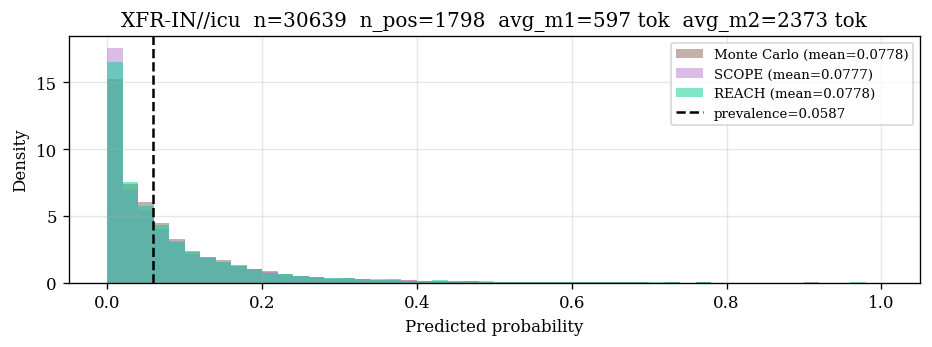

  XFR-IN//icu: n=30639, n_pos=1798 (0.059), avg_m1=596.7 tok, avg_m2=2373.4 tok


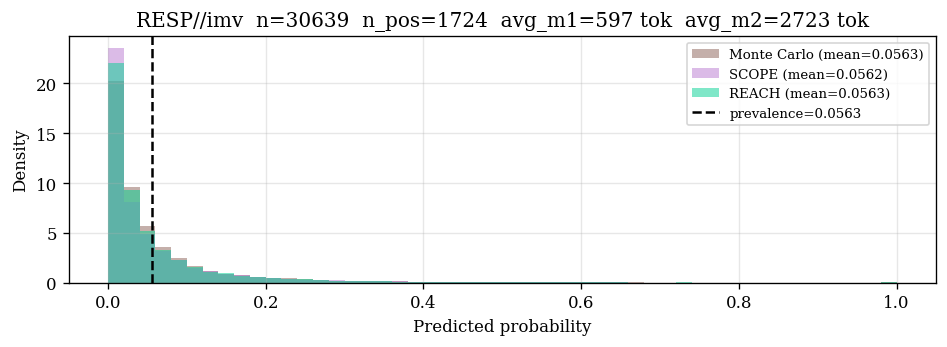

  RESP//imv: n=30639, n_pos=1724 (0.056), avg_m1=596.7 tok, avg_m2=2722.7 tok


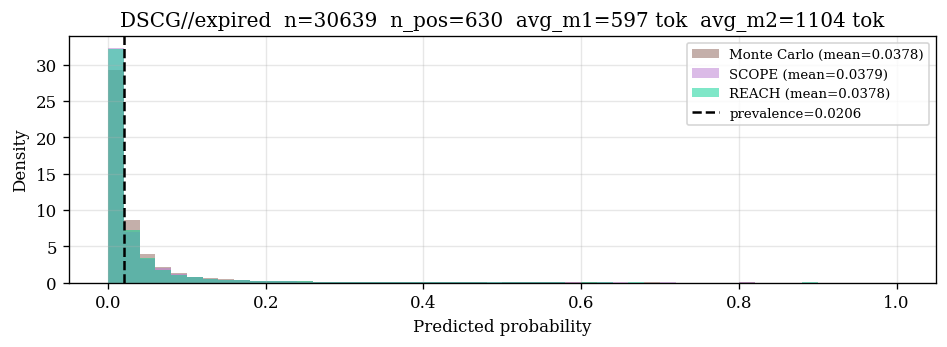

  DSCG//expired: n=30639, n_pos=630 (0.021), avg_m1=596.7 tok, avg_m2=1104.1 tok


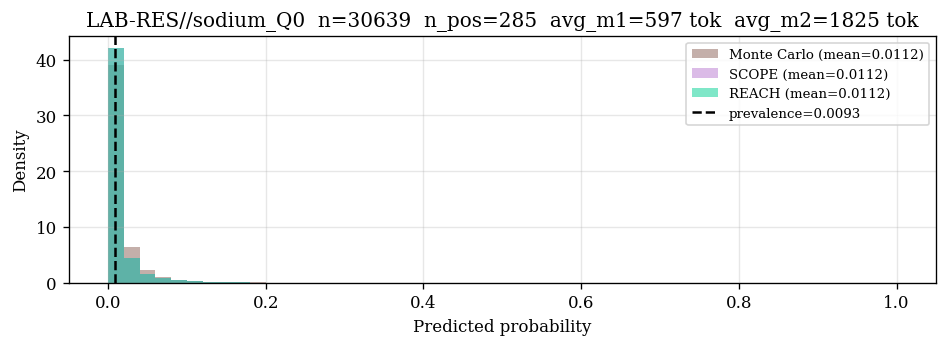

  LAB-RES//sodium_Q0: n=30639, n_pos=285 (0.009), avg_m1=596.7 tok, avg_m2=1824.9 tok


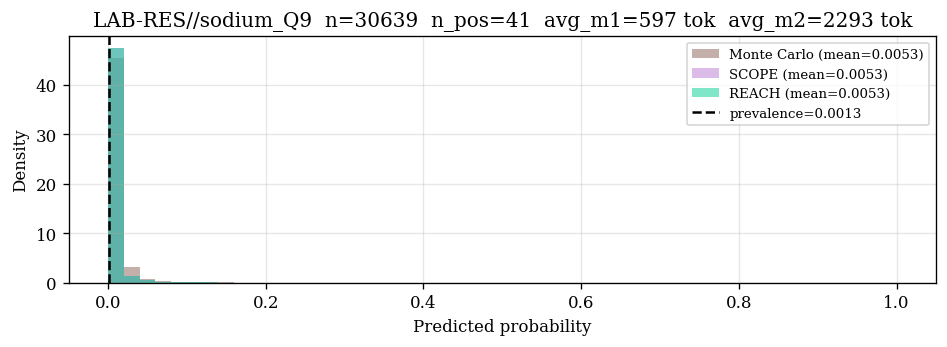

  LAB-RES//sodium_Q9: n=30639, n_pos=41 (0.001), avg_m1=596.7 tok, avg_m2=2293.2 tok


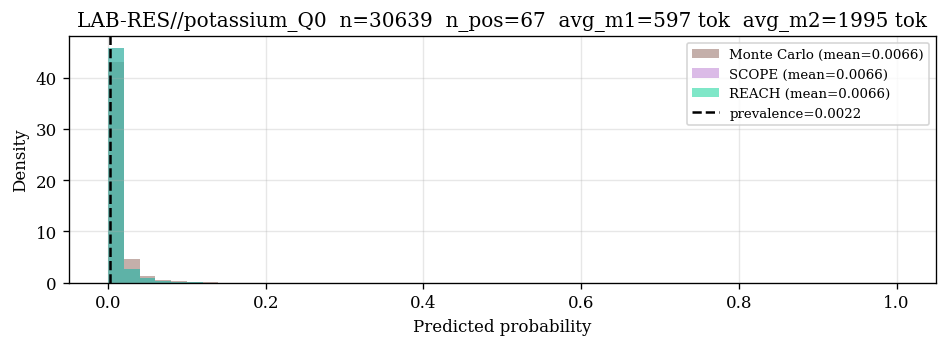

  LAB-RES//potassium_Q0: n=30639, n_pos=67 (0.002), avg_m1=596.7 tok, avg_m2=1994.8 tok


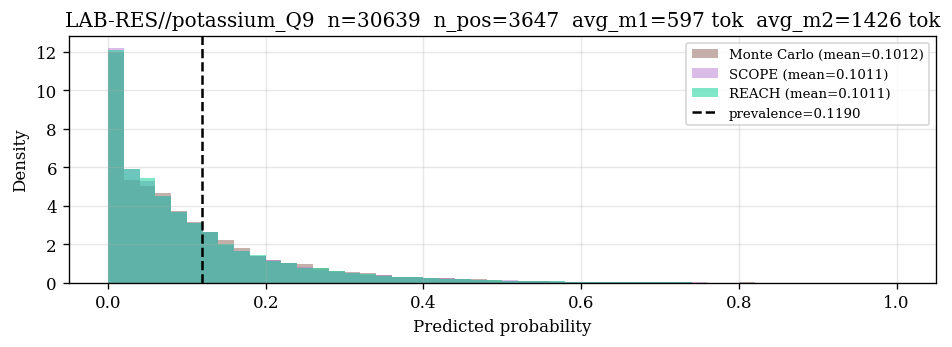

  LAB-RES//potassium_Q9: n=30639, n_pos=3647 (0.119), avg_m1=596.7 tok, avg_m2=1425.8 tok


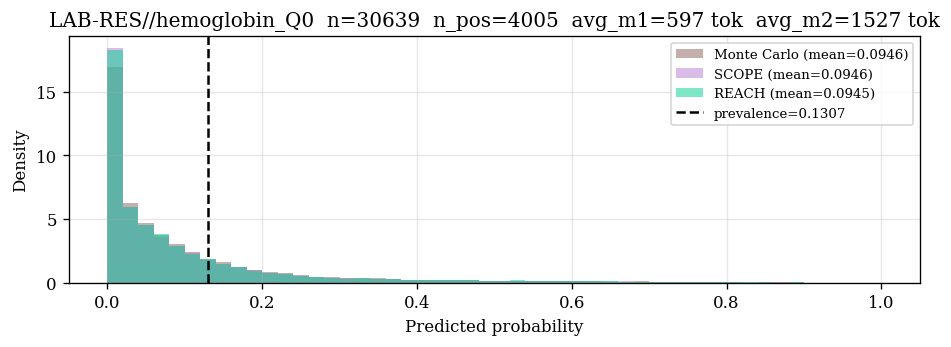

  LAB-RES//hemoglobin_Q0: n=30639, n_pos=4005 (0.131), avg_m1=596.7 tok, avg_m2=1526.9 tok


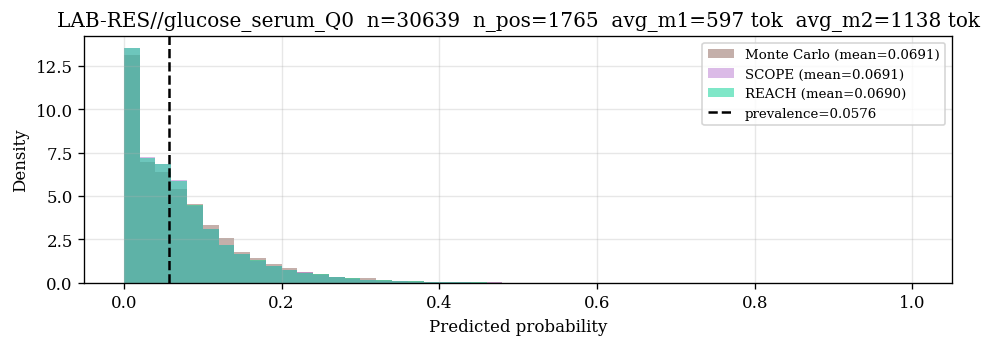

  LAB-RES//glucose_serum_Q0: n=30639, n_pos=1765 (0.058), avg_m1=596.7 tok, avg_m2=1138.1 tok


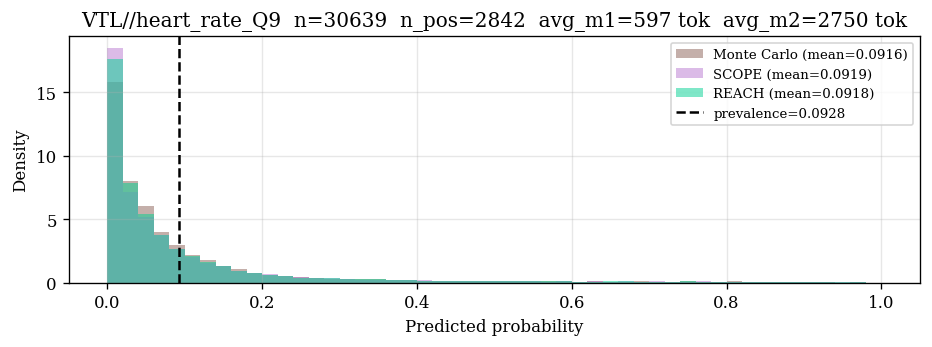

  VTL//heart_rate_Q9: n=30639, n_pos=2842 (0.093), avg_m1=596.7 tok, avg_m2=2749.6 tok


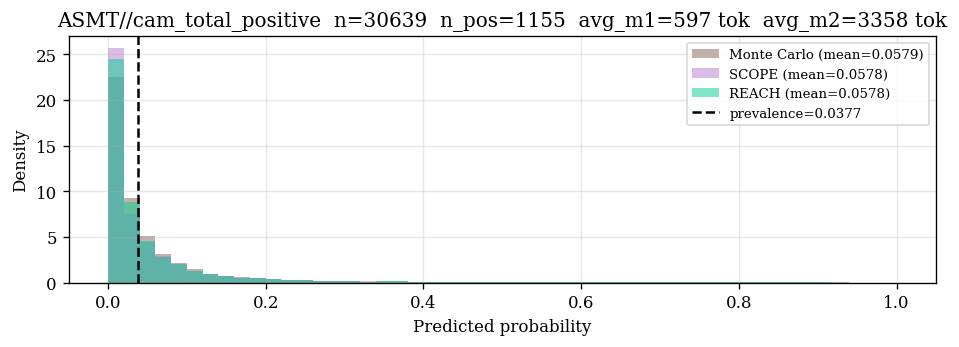

  ASMT//cam_total_positive: n=30639, n_pos=1155 (0.038), avg_m1=596.7 tok, avg_m2=3358.2 tok

Loaded 11 outcomes.


In [ ]:
import json

def _load_scores(path):
    """Load scores NPZ, transparently handling v1 (M0_raw) and v2 (M0_flat/offsets)."""
    data = np.load(path)
    out = {k: data[k] for k in data.files}
    is_v2 = "schema_version" in data.files and int(data["schema_version"][0]) >= 2
    if is_v2:
        for _p in ("M0", "M1", "M2"):
            _fl = data.get(f"{_p}_flat")
            _of = data.get(f"{_p}_offsets")
            if _fl is not None and _of is not None:
                _n   = len(_of) - 1
                _ls  = np.diff(_of)
                _mx  = int(_ls.max()) if _n > 0 else 0
                _raw = np.full((_n, max(_mx, 1)), np.nan, dtype=np.float32)
                for _i in range(_n):
                    _L = int(_ls[_i])
                    if _L:
                        _raw[_i, :_L] = _fl[_of[_i]:_of[_i] + _L]
                out[f"{_p}_raw"] = _raw
    return out


run_summary_path = OUTPUT_DIR / "run_summary.json"
if not run_summary_path.exists():
    raise FileNotFoundError(run_summary_path)
with open(run_summary_path) as _f:
    _run_summary = json.load(_f)

_run_subject_ids = _run_summary.get("subject_ids")
if _run_subject_ids is None:
    raise KeyError("run_summary.json has no 'subject_ids' key")

# Build subject_id → run-local patient_idx mapping (shared across all outcomes)
_sid_map = pl.DataFrame({
    "subject_id": _run_subject_ids,
    "patient_idx": list(range(len(_run_subject_ids))),
})

_index_df_full = (
    pl.read_parquet(index_path)
    .drop("patient_idx")
    .filter(pl.col("subject_id").is_in(_run_subject_ids))
    .join(_sid_map, on="subject_id", how="left")
    .sort("patient_idx")
)

_ALL_SAMPLE_SIZES = [1, 2, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

outcome_data = {}
for _name in OUTCOME_NAMES:
    _safe = _name.replace("/", "_").replace(" ", "_")
    _scores_path = OUTPUT_DIR / f"scores_{_safe}.npz"

    _outcome_col = f"{_name}_future"
    if _outcome_col not in _index_df_full.columns:
        print(f"WARNING: '{_outcome_col}' not found in patient_index — skipping {_name}")
        continue

    _y_true = _index_df_full[_outcome_col].to_numpy().astype(bool)

    _sd      = _load_scores(_scores_path)
    _M0      = _sd["M0"]
    _M1      = _sd["M1"]
    _M2      = _sd["M2"]
    _arr_m0  = _sd["M0_raw"]
    _arr_m1  = _sd["M1_raw"]
    _arr_m2  = _sd["M2_raw"]
    _lens_m0 = (~np.isnan(_arr_m0)).sum(axis=1).astype(np.int32)
    _lens_m1 = (~np.isnan(_arr_m1)).sum(axis=1).astype(np.int32)
    _lens_m2 = (~np.isnan(_arr_m2)).sum(axis=1).astype(np.int32)

    assert len(_y_true) == len(_M0), (
        f"{_name}: y_true ({len(_y_true)}) vs scores ({len(_M0)}) length mismatch"
    )

    _avg_m1  = float(_sd["avg_m1_tokens"][0]) if "avg_m1_tokens" in _sd else np.nan
    _avg_m2  = float(_sd["avg_m2_tokens"][0]) if "avg_m2_tokens" in _sd else np.nan
    _n_pts   = len(_y_true)
    _n_pos   = int(_y_true.sum())
    _max_n   = max(int(_lens_m1.max()), int(_lens_m2.max())) if _n_pts > 0 else 10
    _ss      = sorted({s for s in _ALL_SAMPLE_SIZES if s <= _max_n} | {_max_n})

    # Histogram of prediction distributions
    _fig, _ax = plt.subplots(figsize=(8, 3), dpi=120)
    _bins = np.linspace(0, 1, 51)
    for _est, _sc in [("Monte Carlo", _M0), ("SCOPE", _M1), ("REACH", _M2)]:
        _v = _sc[np.isfinite(_sc)]
        _ax.hist(_v, bins=_bins, alpha=0.5, color=COLORS[_est],
                 label=f"{_est} (mean={_v.mean():.4f})", density=True)
    _ax.axvline(_y_true.mean(), color="k", linestyle="--", linewidth=1.5,
                label=f"prevalence={_y_true.mean():.4f}")
    _ax.set_xlabel("Predicted probability")
    _ax.set_ylabel("Density")
    _ax.set_title(
        f"{_name}  n={_n_pts}  n_pos={_n_pos}  "
        f"avg_m1={_avg_m1:.0f} tok  avg_m2={_avg_m2:.0f} tok"
    )
    _ax.legend(fontsize=8)
    _ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    outcome_data[_name] = {
        "y_true":        _y_true,
        "M0": _M0,  "M1": _M1,  "M2": _M2,
        "arr_m0":        _arr_m0,
        "arr_m1":        _arr_m1,
        "arr_m2":        _arr_m2,
        "lens_m0":       _lens_m0,
        "lens_m1":       _lens_m1,
        "lens_m2":       _lens_m2,
        "avg_tokens_m1": _avg_m1,
        "avg_tokens_m2": _avg_m2,
        "n_patients":    _n_pts,
        "n_pos":         _n_pos,
        "prevalence":    float(_y_true.mean()),
        "CAN_COMPUTE_AUC": _n_pos > 0 and _n_pos < _n_pts,
        "SAMPLE_SIZES":  _ss,
        "N_STRAPS":      40,
        "N_BINS":        max(3, min(10, _n_pts // 15)),
        "N_BOOT_CI":     min(2000, max(200, _n_pts * 10)),
    }
    print(
        f"  {_name}: n={_n_pts}, n_pos={_n_pos} ({_y_true.mean():.3f}), "
        f"avg_m1={_avg_m1:.1f} tok, avg_m2={_avg_m2:.1f} tok"
    )

print(f"\nLoaded {len(outcome_data)} outcomes.")

## Bootstrap utilities

In [30]:
Generator: typing.TypeAlias = np.random._generator.Generator


def bootstrap_ci(
    y_true: np.ndarray,
    y_score: np.ndarray,
    *,
    n_samples: int = 10_000,
    alpha: float = 0.05,
    rng: Generator = np.random.default_rng(seed=42),
    objs: tuple = ("roc_auc", "brier"),
    n_jobs: int = -1,
) -> dict:
    """Percentile bootstrap CI for roc_auc and/or brier score."""

    def _one(rng_i):
        warnings.filterwarnings("ignore")
        idx = rng_i.choice(len(y_true), size=len(y_true), replace=True)
        yt, ys = y_true[idx], y_score[idx]
        out = {}
        if "roc_auc" in objs:
            out["roc_auc"] = skl_mets.roc_auc_score(yt, ys)
        if "brier" in objs:
            out["brier"] = skl_mets.brier_score_loss(yt, np.clip(ys, 0, 1))
        return out

    with jl.Parallel(n_jobs=n_jobs) as par:
        scores = par(jl.delayed(_one)(ri) for ri in rng.spawn(n_samples))

    return {
        ob: np.nanquantile([s[ob] for s in scores], q=[alpha / 2, 1 - alpha / 2])
        for ob in objs
    }


def bootstrap_pval(
    y_true: np.ndarray,
    y_score0: np.ndarray,
    y_score1: np.ndarray,
    *,
    n_samples: int = 10_000,
    rng: Generator = np.random.default_rng(seed=42),
    alternative: typing.Literal["one-sided", "two-sided"] = "one-sided",
    objs: tuple = ("roc_auc", "brier"),
    n_jobs: int = -1,
) -> dict:
    """Bootstrap p-value: H0 that score0 and score1 are equally good."""

    def _diffs(rng_i):
        warnings.filterwarnings("ignore")
        idx = rng_i.choice(len(y_true), size=len(y_true), replace=True)
        yt0, ys0 = y_true[idx], y_score0[idx]
        yt1, ys1 = y_true[idx], y_score1[idx]
        d = {}
        if "roc_auc" in objs:
            d["roc_auc"] = skl_mets.roc_auc_score(yt1, ys1) - skl_mets.roc_auc_score(yt0, ys0)
        if "brier" in objs:
            d["brier"] = -(skl_mets.brier_score_loss(yt1, np.clip(ys1, 0, 1)) - skl_mets.brier_score_loss(yt0, np.clip(ys0, 0, 1)))
        return d

    obs_diffs = {}
    if "roc_auc" in objs:
        obs_diffs["roc_auc"] = skl_mets.roc_auc_score(y_true, y_score1) - skl_mets.roc_auc_score(y_true, y_score0)
    if "brier" in objs:
        obs_diffs["brier"] = -(skl_mets.brier_score_loss(y_true, np.clip(y_score1, 0, 1)) - skl_mets.brier_score_loss(y_true, np.clip(y_score0, 0, 1)))

    with jl.Parallel(n_jobs=n_jobs) as par:
        boot_diffs = par(jl.delayed(_diffs)(ri) for ri in rng.spawn(n_samples))

    pvals = {}
    for ob in objs:
        d_obs  = obs_diffs[ob]
        d_boot = np.array([b[ob] for b in boot_diffs])
        if alternative == "one-sided":
            pvals[ob] = float(np.mean(d_boot >= d_obs))
        else:
            pvals[ob] = float(np.mean(np.abs(d_boot) >= np.abs(d_obs)))
    return pvals

In [31]:
## Subsampling utilities for AUC-vs-samples curve


def _make_ctx(arr: np.ndarray, lens: np.ndarray, y_true: np.ndarray) -> dict:
    """Pack a score matrix into a context for fast repeated subsampling.

    Args:
        arr:    shape [n_patients, n_samp], NaN where sample is absent.
        lens:   shape [n_patients], number of valid (non-NaN) samples.
        y_true: shape [n_patients], bool ground truth.

    Returns:
        Dict with pre-extracted per-patient valid-sample arrays and labels.
    """
    valid_samples = []
    valid_mask = lens > 0
    for i in range(len(arr)):
        if lens[i] > 0:
            row = arr[i]
            valid_samples.append(row[~np.isnan(row)].astype(np.float64))
        else:
            valid_samples.append(None)
    return {
        "valid_samples": valid_samples,
        "valid_mask": valid_mask,
        "y_true": y_true,
    }


def _subsample_aucs(ctx: dict, n: int, n_straps: int, rng: np.random.Generator) -> list:
    """Bootstrap AUC by subsampling n samples per patient for n_straps reps.

    Patients with fewer than n valid samples are sampled with replacement.
    Patients with 0 valid samples are excluded from every AUC computation.

    Args:
        ctx:     Context from _make_ctx.
        n:       Samples to draw per patient per bootstrap repetition.
        n_straps: Number of bootstrap repetitions.
        rng:     NumPy Generator (consumed in-place; state advances each call).

    Returns:
        List of n_straps AUC floats (np.nan if AUC is undefined).
    """
    valid_samples = ctx["valid_samples"]
    valid_mask = ctx["valid_mask"]
    y_true_sub = ctx["y_true"][valid_mask]

    if y_true_sub.sum() == 0 or (~y_true_sub).sum() == 0:
        return [np.nan] * n_straps

    patient_arrays = [s for s in valid_samples if s is not None]

    aucs = []
    for _ in range(n_straps):
        means = np.array([
            rng.choice(s, size=n, replace=(len(s) < n)).mean()
            for s in patient_arrays
        ])
        try:
            aucs.append(skl_mets.roc_auc_score(y_true_sub, means))
        except Exception:
            aucs.append(np.nan)
    return aucs


## Full-sample AUC / Brier with bootstrap CIs

In [32]:
rng_ci = np.random.default_rng(seed=42)

for _name, _od in outcome_data.items():
    print(f"\n=== {_name} ===")
    if not _od["CAN_COMPUTE_AUC"]:
        print(f"  Skipping — n_pos={_od['n_pos']} in {_od['n_patients']} patients.")
        continue

    _y = _od["y_true"]
    print(f"  {'Estimator':<14}  {'AUC':>6}  {'95% CI':>13}  {'Brier':>7}  {'95% CI':>13}")
    print("  " + "-" * 60)
    for _est_name, _scores in [("Monte Carlo", _od["M0"]), ("SCOPE", _od["M1"]), ("REACH", _od["M2"])]:
        _valid = ~np.isnan(_scores)
        if _valid.sum() == 0:
            print(f"  {_est_name:<14}  no valid scores")
            continue
        _scores_clipped = np.clip(_scores[_valid], 0, 1)
        _auc   = skl_mets.roc_auc_score(_y[_valid], _scores[_valid])
        _brier = brier_score_loss(_y[_valid], _scores_clipped)
        _ci    = bootstrap_ci(_y[_valid], _scores_clipped, n_samples=_od["N_BOOT_CI"], rng=rng_ci)
        _alo, _ahi = _ci["roc_auc"]
        _blo, _bhi = _ci["brier"]
        print(
            f"  {_est_name:<14}  {_auc:.4f}  [{_alo:.4f},{_ahi:.4f}]"
            f"  {_brier:.5f}  [{_blo:.5f},{_bhi:.5f}]"
        )

    # Empirical spontaneity: mean over patients of p*(1-p), where p = individual REACH score
    _m2 = _od["M2"]
    _valid_m2 = _m2[~np.isnan(_m2)]
    _spontaneity = float(np.mean(_valid_m2 * (1.0 - _valid_m2)))
    print(f"  {'Spontaneity':<14}  {_spontaneity:.5f}  (mean p·(1-p) over {len(_valid_m2)} patients, p=REACH)")


=== XFR-IN//icu ===
  Estimator          AUC         95% CI    Brier         95% CI
  ------------------------------------------------------------


  Monte Carlo     0.8698  [0.8598,0.8793]  0.03587  [0.03427,0.03733]
  SCOPE           0.8694  [0.8589,0.8796]  0.03598  [0.03447,0.03758]
  REACH           0.8712  [0.8615,0.8815]  0.03584  [0.03430,0.03744]
  Spontaneity     0.06053  (mean p·(1-p) over 26464 patients, p=REACH)

=== RESP//imv ===
  Estimator          AUC         95% CI    Brier         95% CI
  ------------------------------------------------------------
  Monte Carlo     0.8926  [0.8811,0.9034]  0.02385  [0.02265,0.02518]
  SCOPE           0.8907  [0.8789,0.9009]  0.02402  [0.02284,0.02531]
  REACH           0.8956  [0.8845,0.9056]  0.02379  [0.02255,0.02498]
  Spontaneity     0.04384  (mean p·(1-p) over 29284 patients, p=REACH)

=== DSCG//expired ===
  Estimator          AUC         95% CI    Brier         95% CI
  ------------------------------------------------------------
  Monte Carlo     0.9012  [0.8880,0.9143]  0.01739  [0.01633,0.01843]
  SCOPE           0.9103  [0.8983,0.9212]  0.01746  [0.01641,0.01852]
  

## AUC vs number of samples (subsampling bootstrap)

In [ ]:
rng_sub = np.random.default_rng(seed=0)
N_STRAPS = 10
for _name, _od in tqdm(outcome_data.items(), desc="Outcomes", unit="outcome"):
    if not _od["CAN_COMPUTE_AUC"]:
        _od["auc_list"] = []
        continue

    _ctx_m0 = _make_ctx(_od["arr_m0"], _od["lens_m0"], _od["y_true"])
    _ctx_m1 = _make_ctx(_od["arr_m1"], _od["lens_m1"], _od["y_true"])
    _ctx_m2 = _make_ctx(_od["arr_m2"], _od["lens_m2"], _od["y_true"])

    _auc_list = []
    for _n in tqdm(_od["SAMPLE_SIZES"], desc=_name.split("//")[-1], unit="n", leave=False):
        _mc = _subsample_aucs(_ctx_m0, _n, _od["N_STRAPS"], rng_sub)
        _sc = _subsample_aucs(_ctx_m1, _n, _od["N_STRAPS"], rng_sub)
        _re = _subsample_aucs(_ctx_m2, _n, _od["N_STRAPS"], rng_sub)
        for _a, _b, _c in zip(_mc, _sc, _re):
            _auc_list.append(((float(_a), float(_b), float(_c)), _n))
    _od["auc_list"] = _auc_list

print("Bootstrap complete.")
for _name, _od in outcome_data.items():
    print(f"  {_name}: {len(_od['auc_list'])} entries ({_od['N_STRAPS']} straps × {len(_od['SAMPLE_SIZES'])} sizes)")

Outcomes:  73%|███████▎  | 8/11 [01:18<00:29,  9.80s/outcome]

## AUC vs sample-size plot

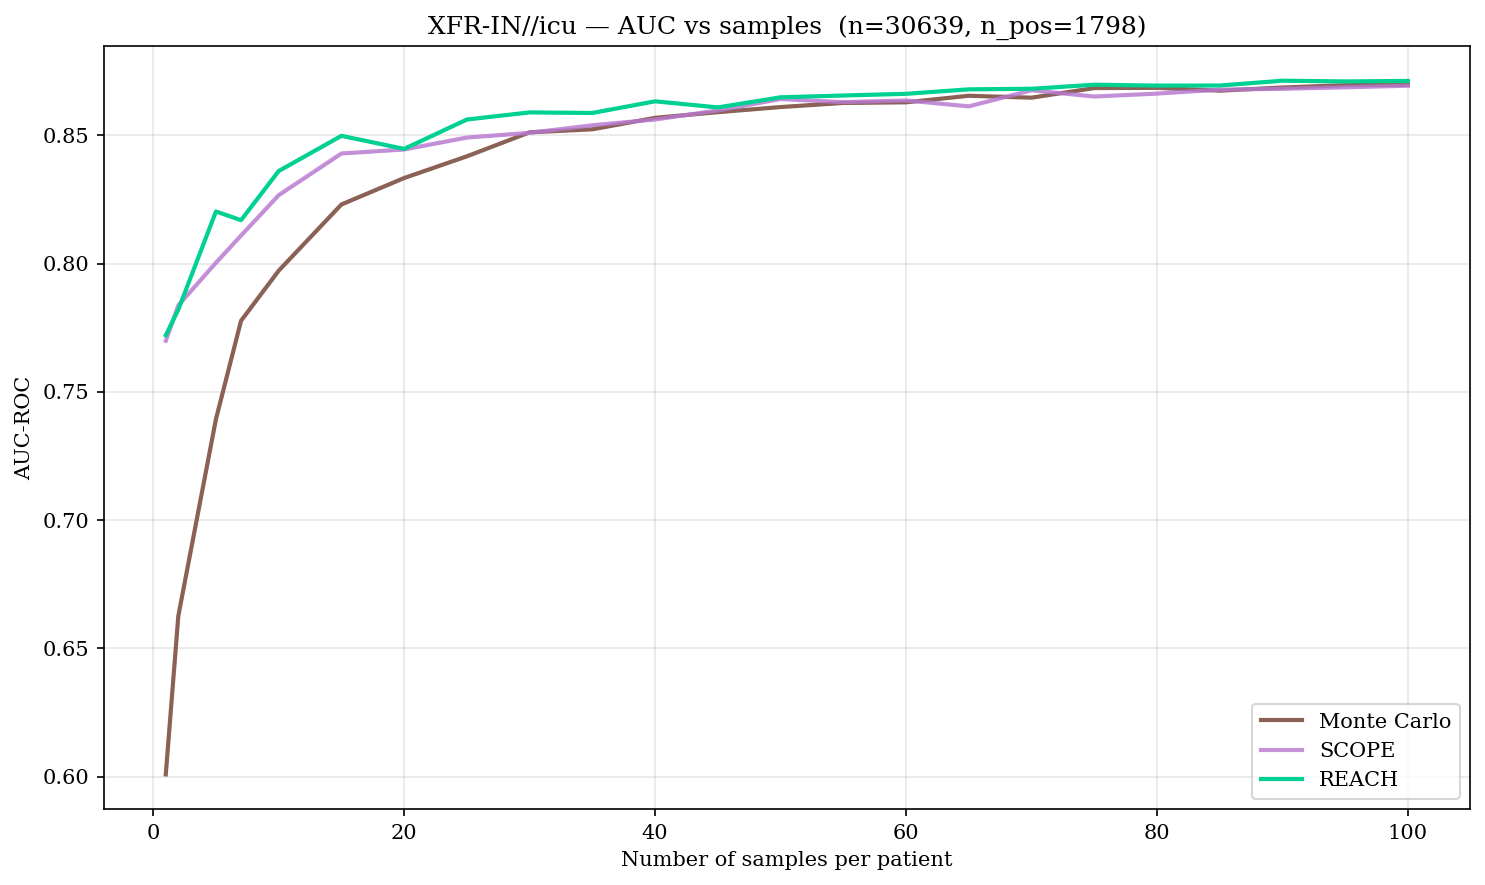

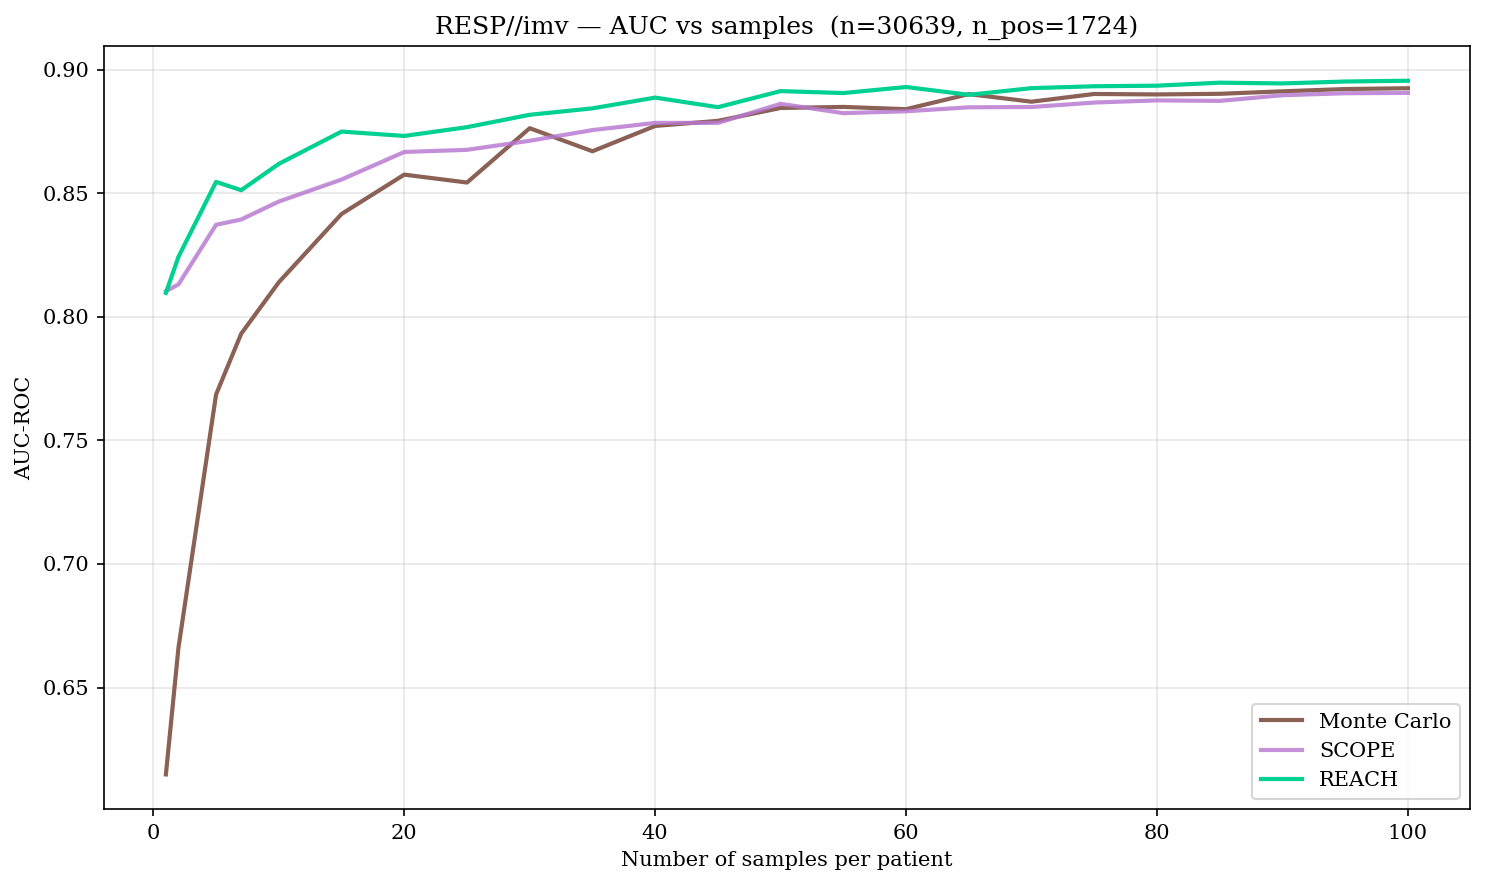

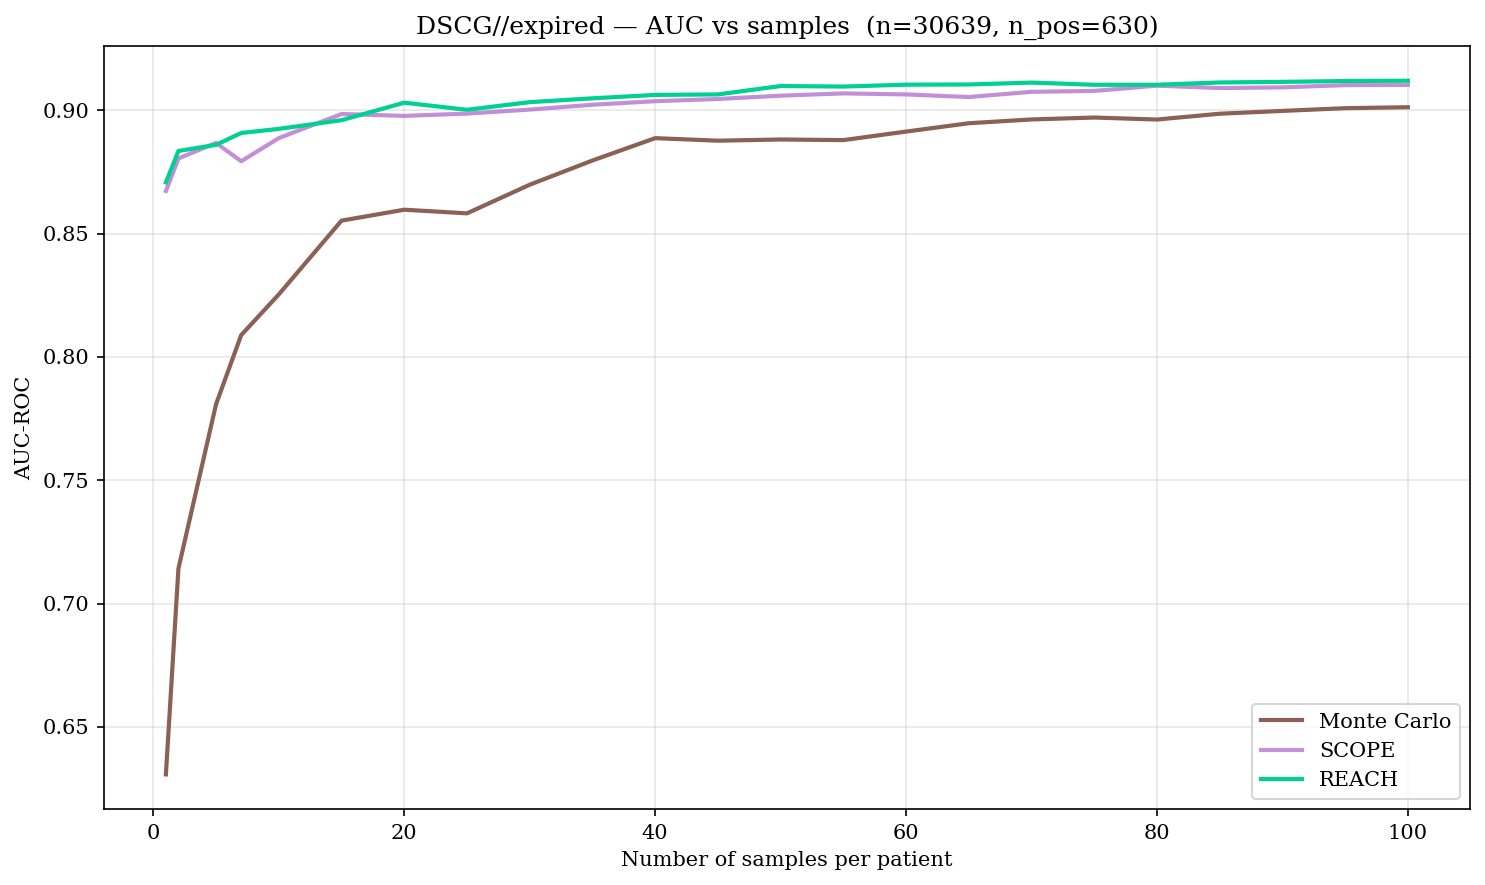

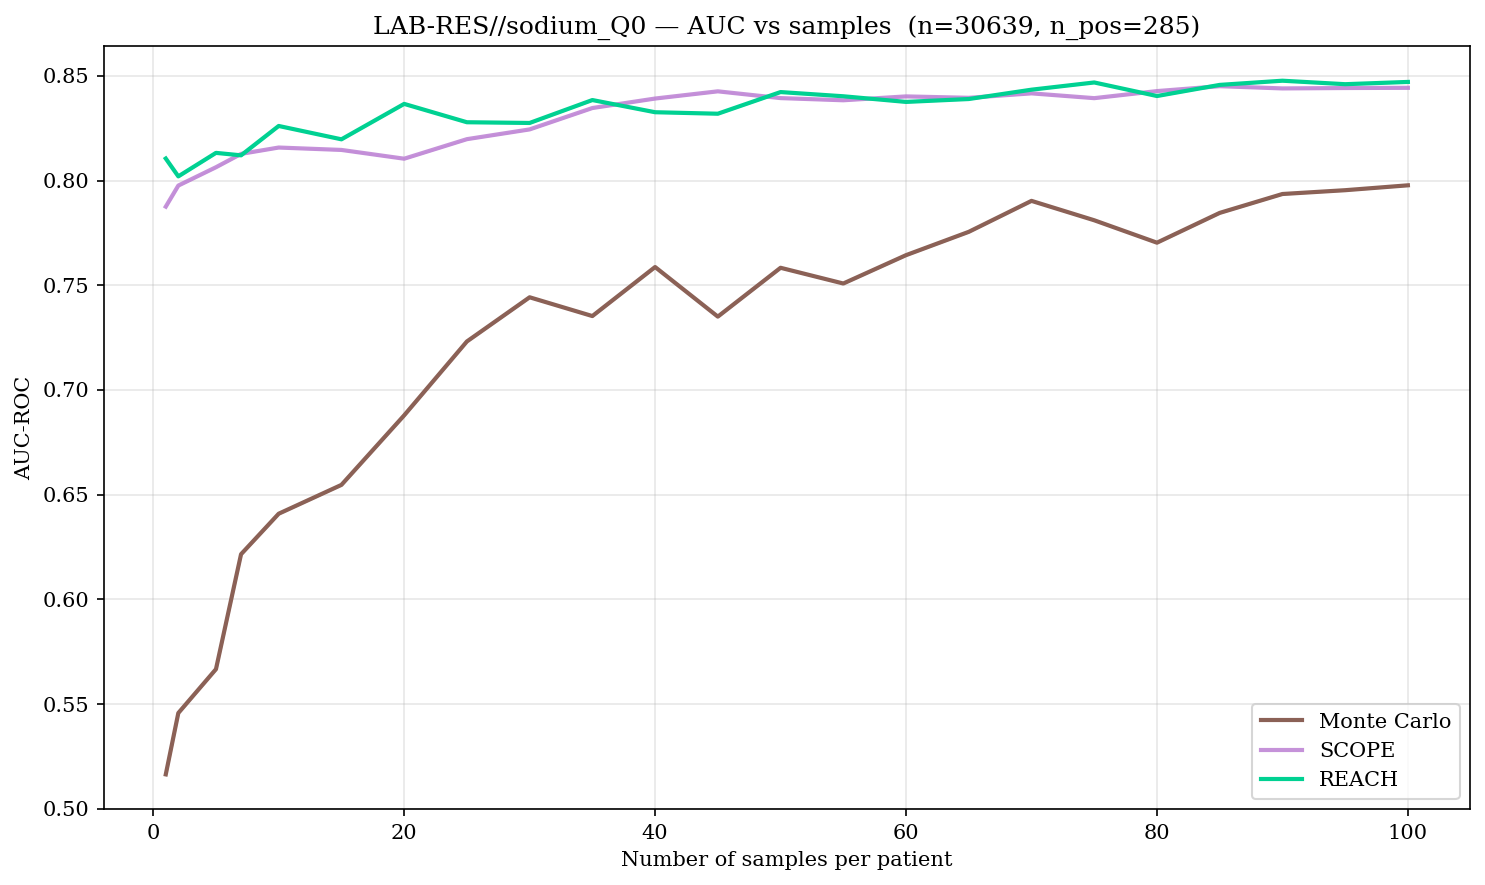

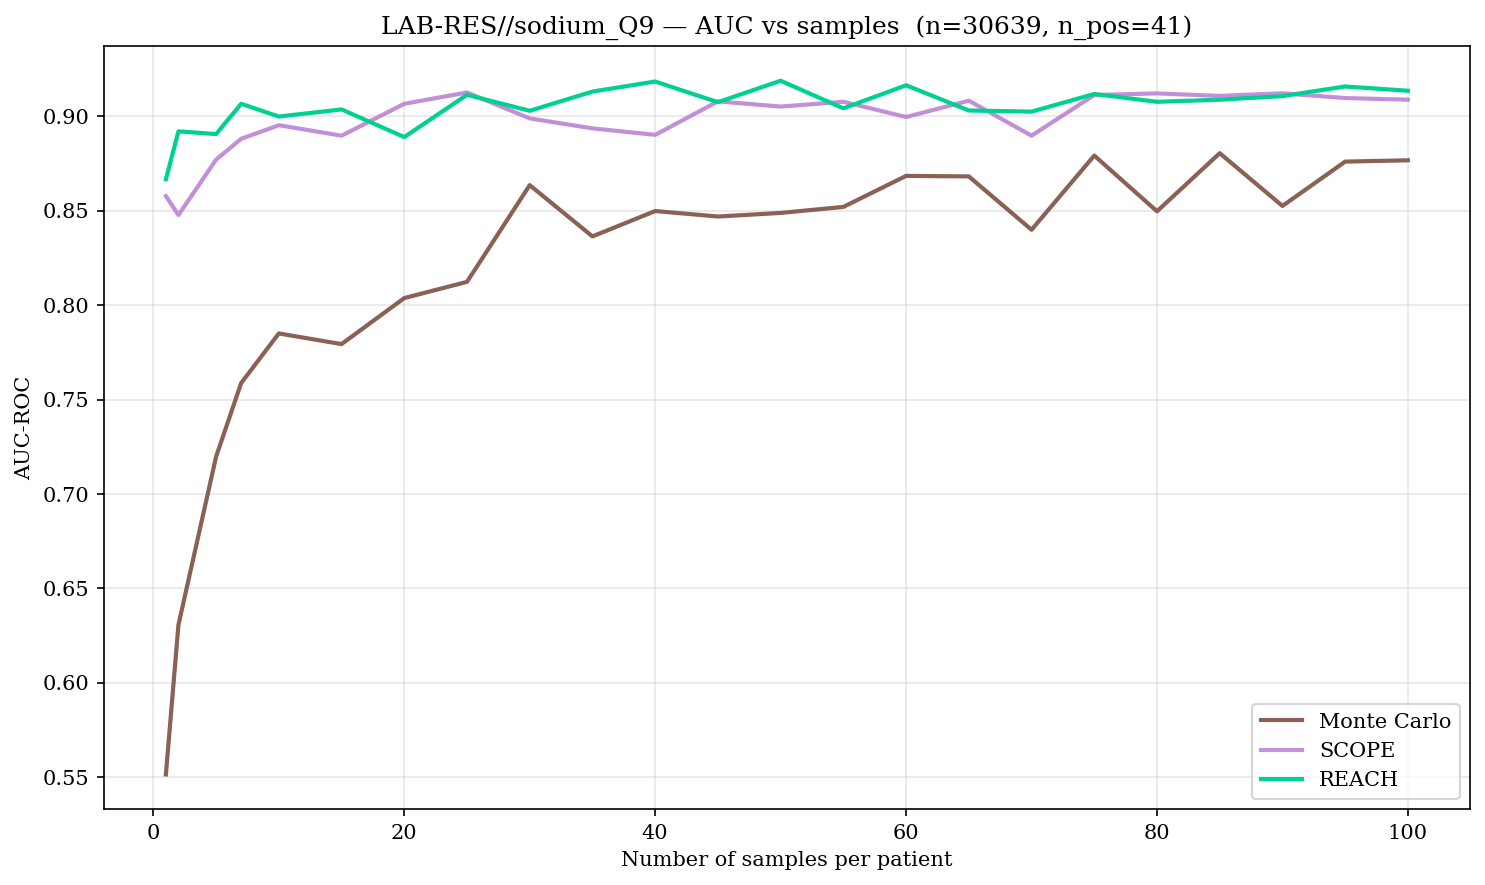

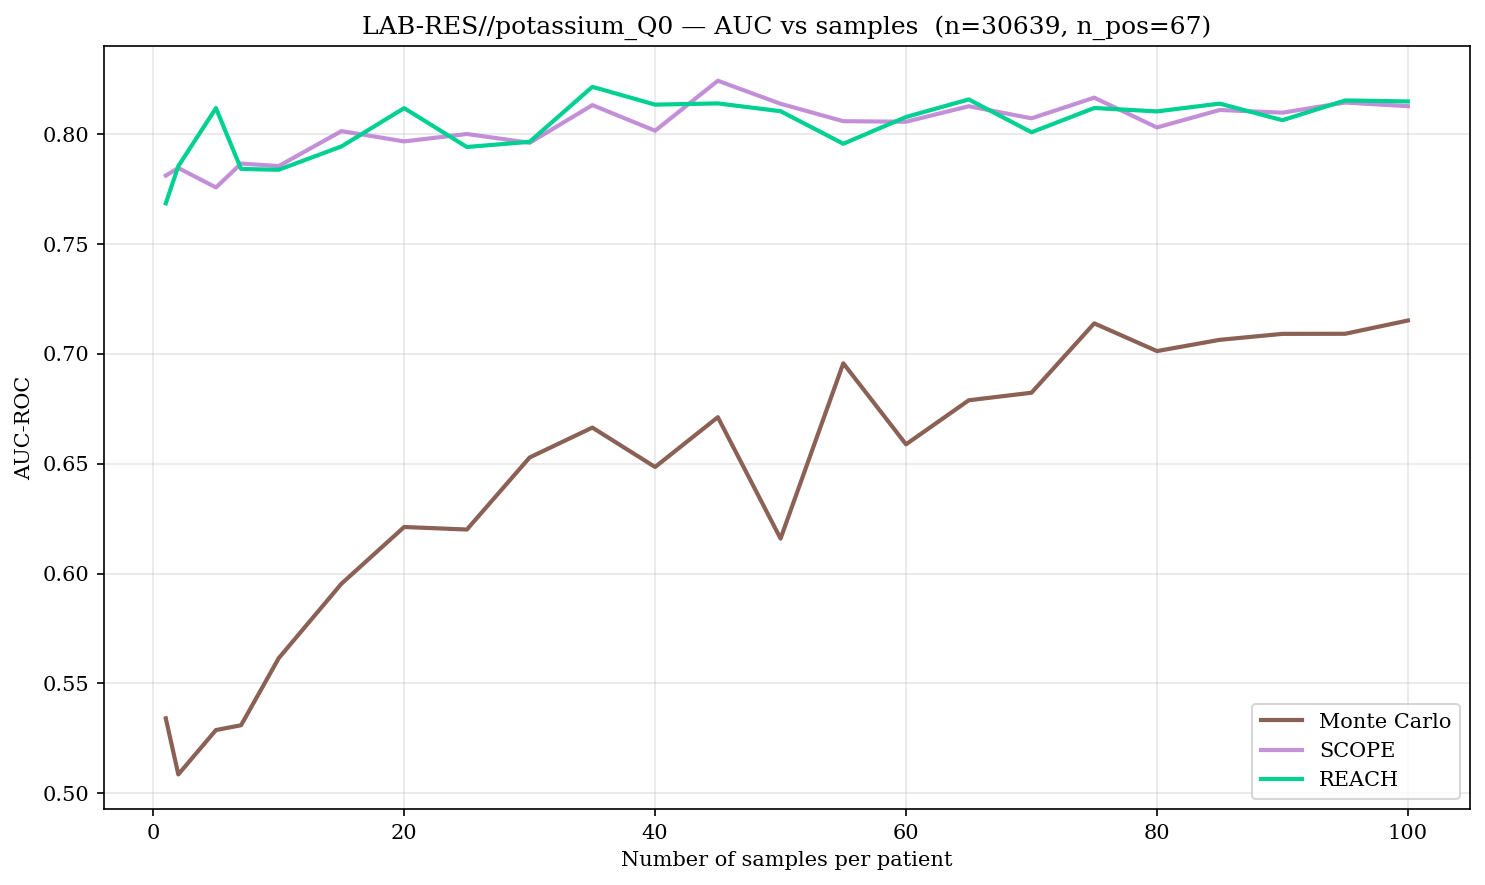

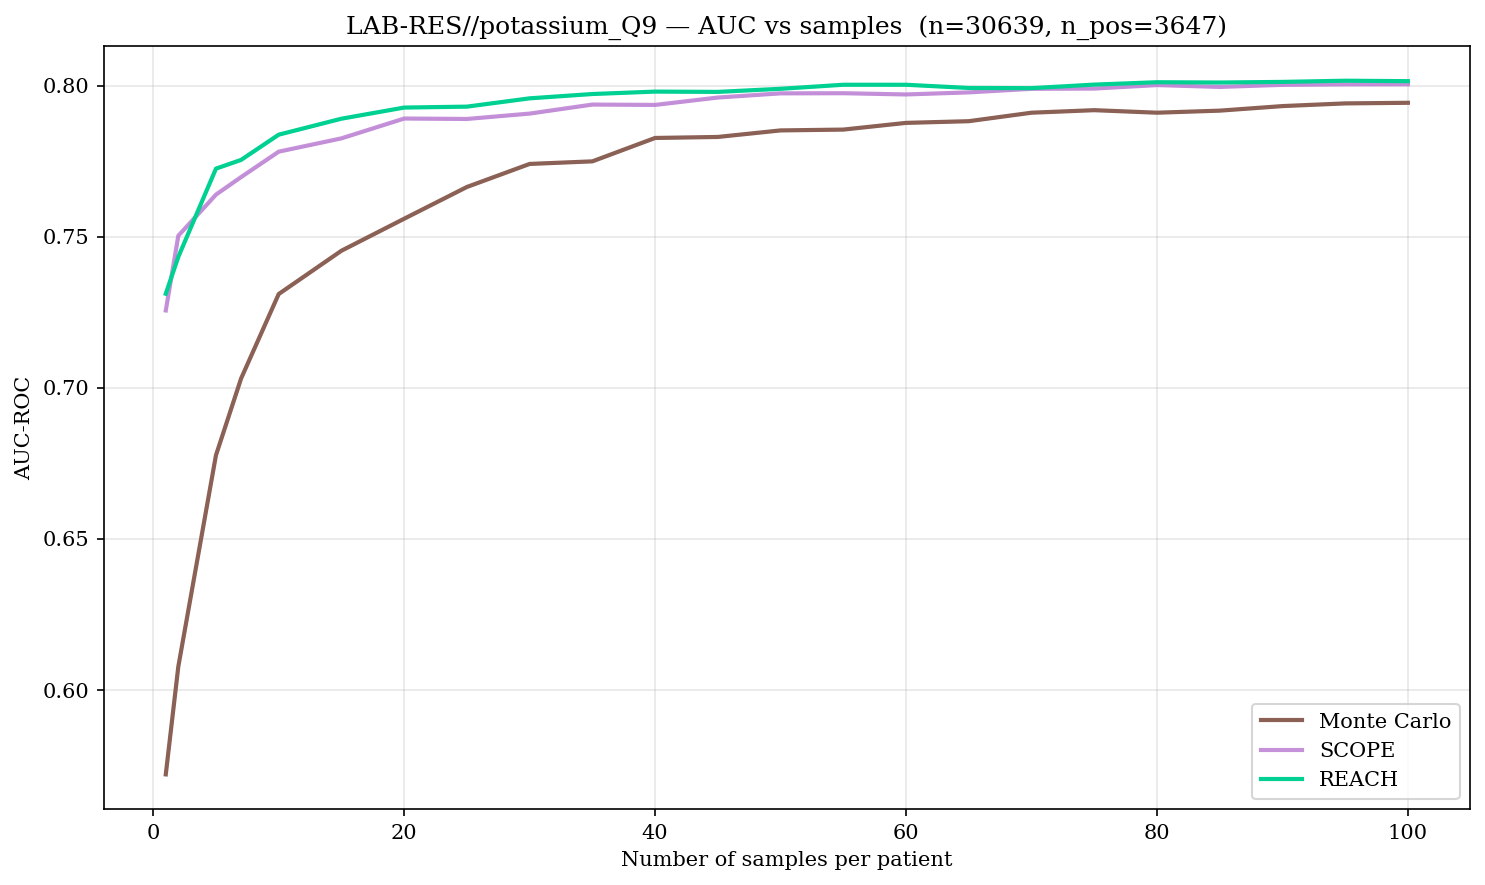

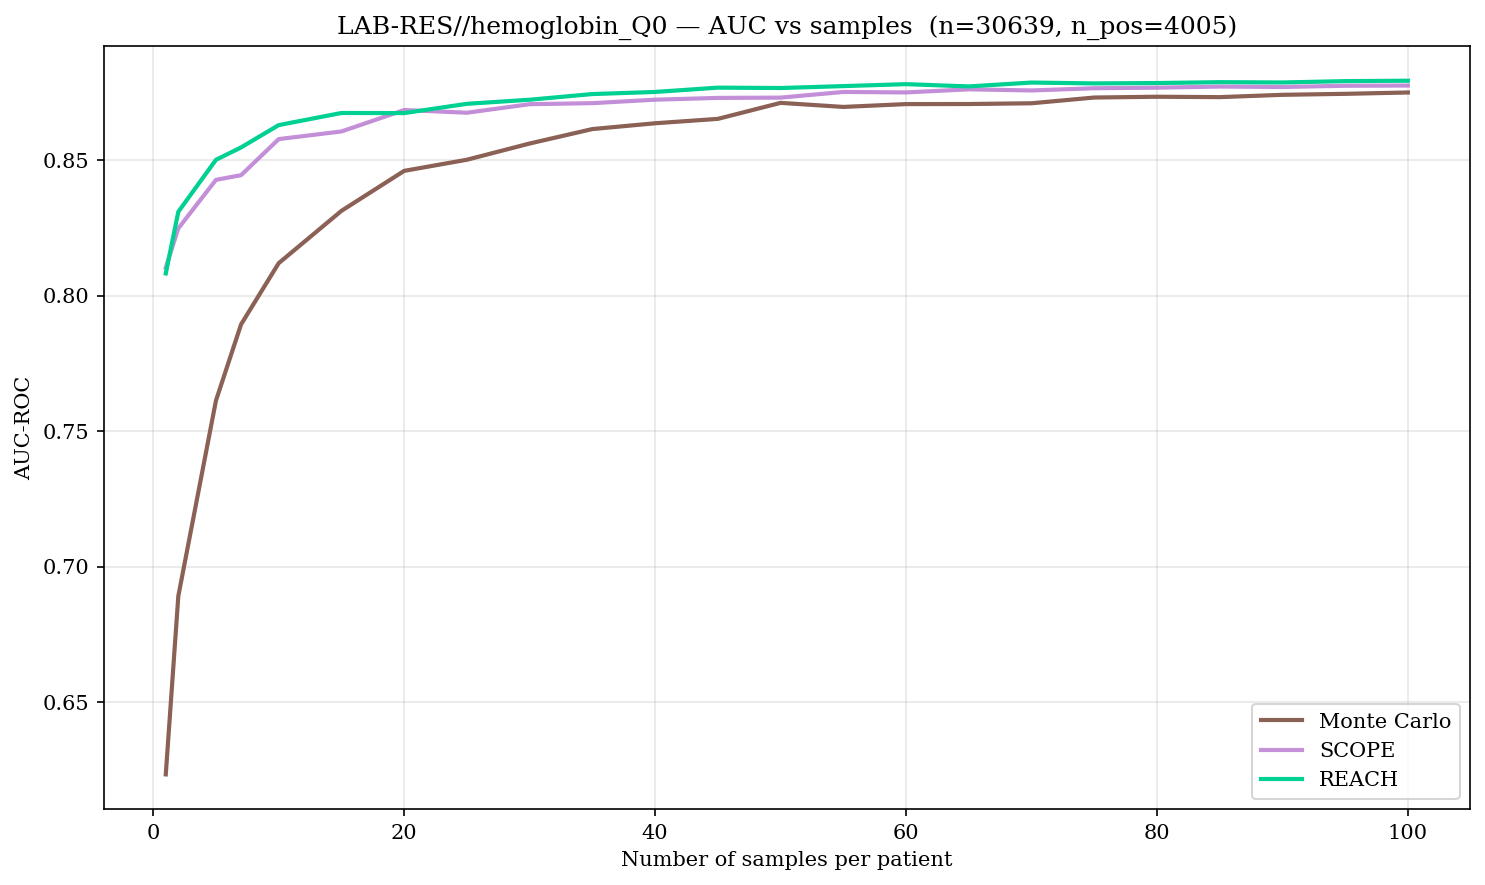

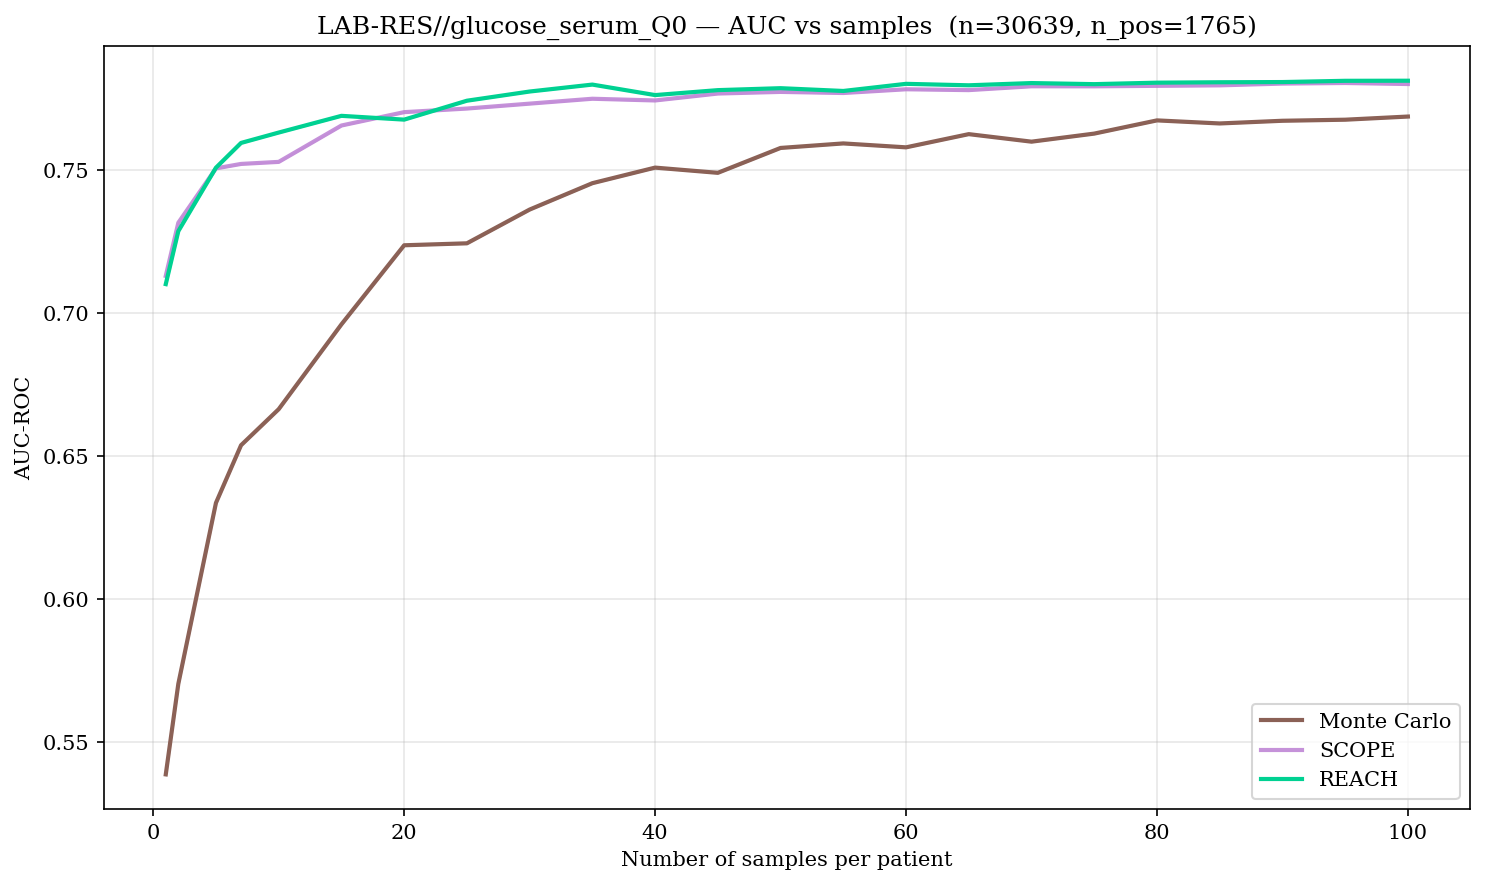

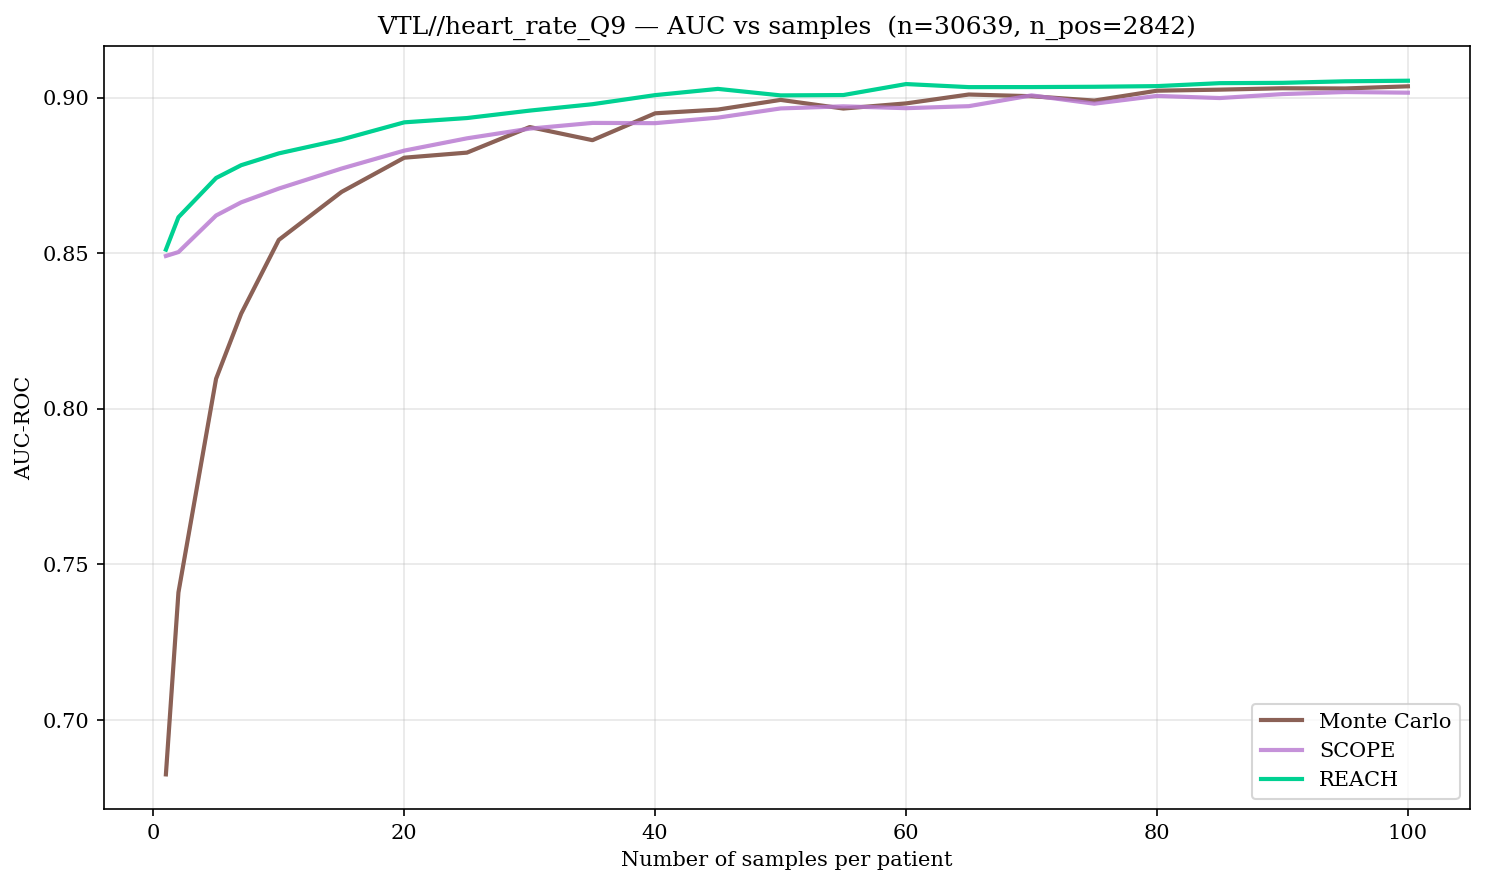

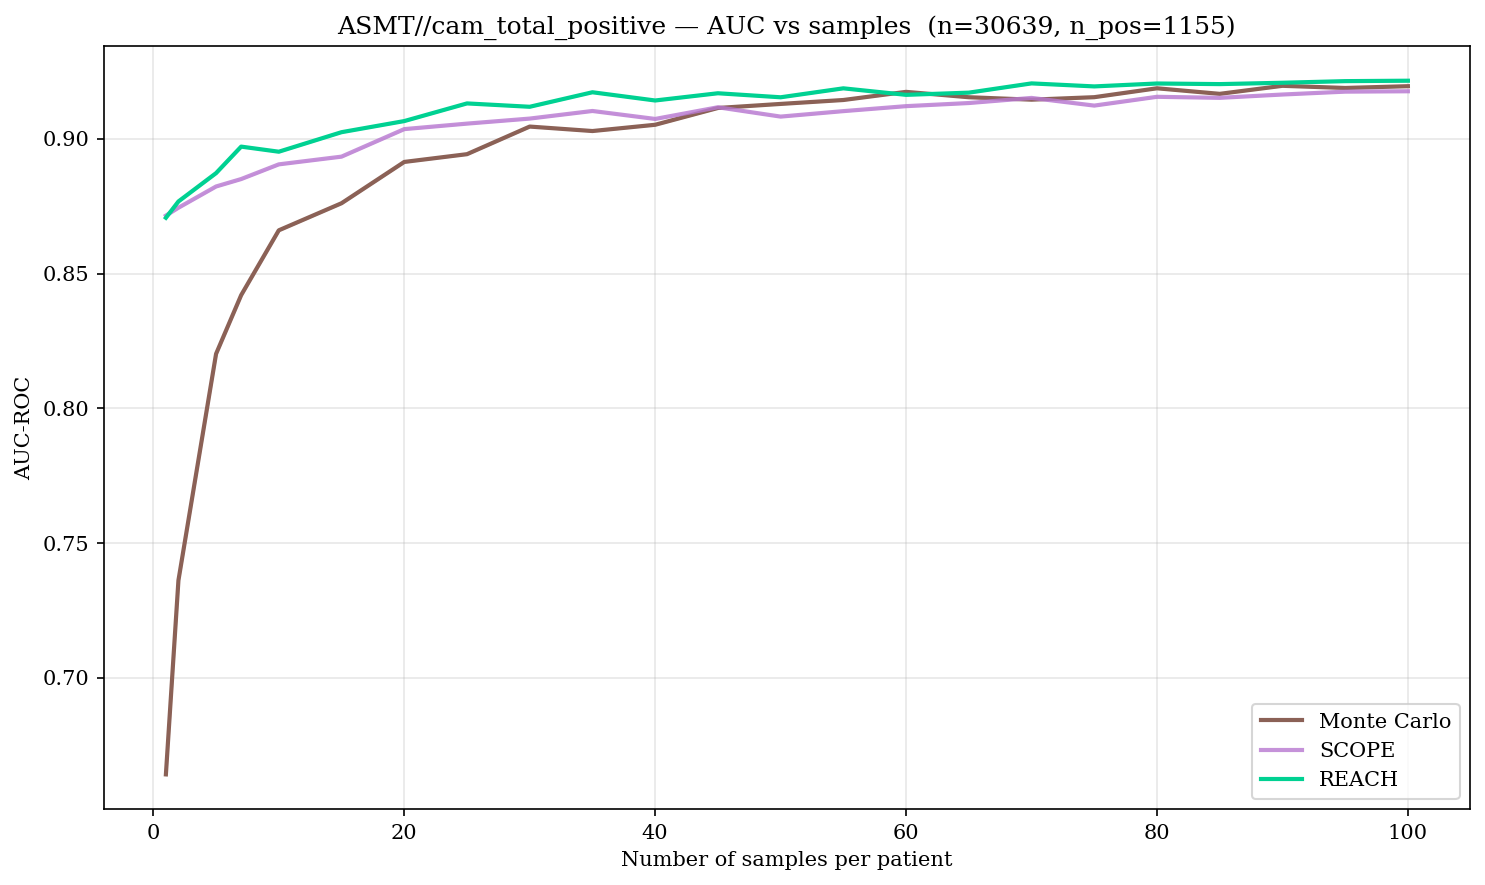

In [35]:
def _ci95(by_n, samp_list):
    lo, hi = [], []
    for n in samp_list:
        v = np.array(by_n[n])
        lo.append(np.percentile(v, 2.5))
        hi.append(np.percentile(v, 97.5))
    return np.array(lo), np.array(hi)


for _name, _od in outcome_data.items():
    _auc_list = _od["auc_list"]
    if not _auc_list:
        print(f"No AUC data for {_name} — skipping.")
        continue

    _samp_list = np.array(sorted(set(item[1] for item in _auc_list)))
    _mc_by_n   = {n: [item[0][0] for item in _auc_list if item[1] == n] for n in _samp_list}
    _sc_by_n   = {n: [item[0][1] for item in _auc_list if item[1] == n] for n in _samp_list}
    _re_by_n   = {n: [item[0][2] for item in _auc_list if item[1] == n] for n in _samp_list}

    _mc_mean = np.array([np.mean(_mc_by_n[n]) for n in _samp_list])
    _sc_mean = np.array([np.mean(_sc_by_n[n]) for n in _samp_list])
    _re_mean = np.array([np.mean(_re_by_n[n]) for n in _samp_list])

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    for _est, _mean, _by_n in [
        ("Monte Carlo", _mc_mean, _mc_by_n),
        ("SCOPE",       _sc_mean, _sc_by_n),
        ("REACH",       _re_mean, _re_by_n),
    ]:
        _lo, _hi = _ci95(_by_n, _samp_list)
        _c = COLORS[_est]
        ax.plot(_samp_list, _mean, color=_c, label=_est, linewidth=2)
        ax.fill_between(_samp_list, _lo, _hi, color=_c, alpha=0.15)

    ax.set_xlabel("Number of samples per patient")
    ax.set_ylabel("AUC-ROC")
    ax.set_title(f"{_name} — AUC vs samples  (n={_od['n_patients']}, n_pos={_od['n_pos']})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

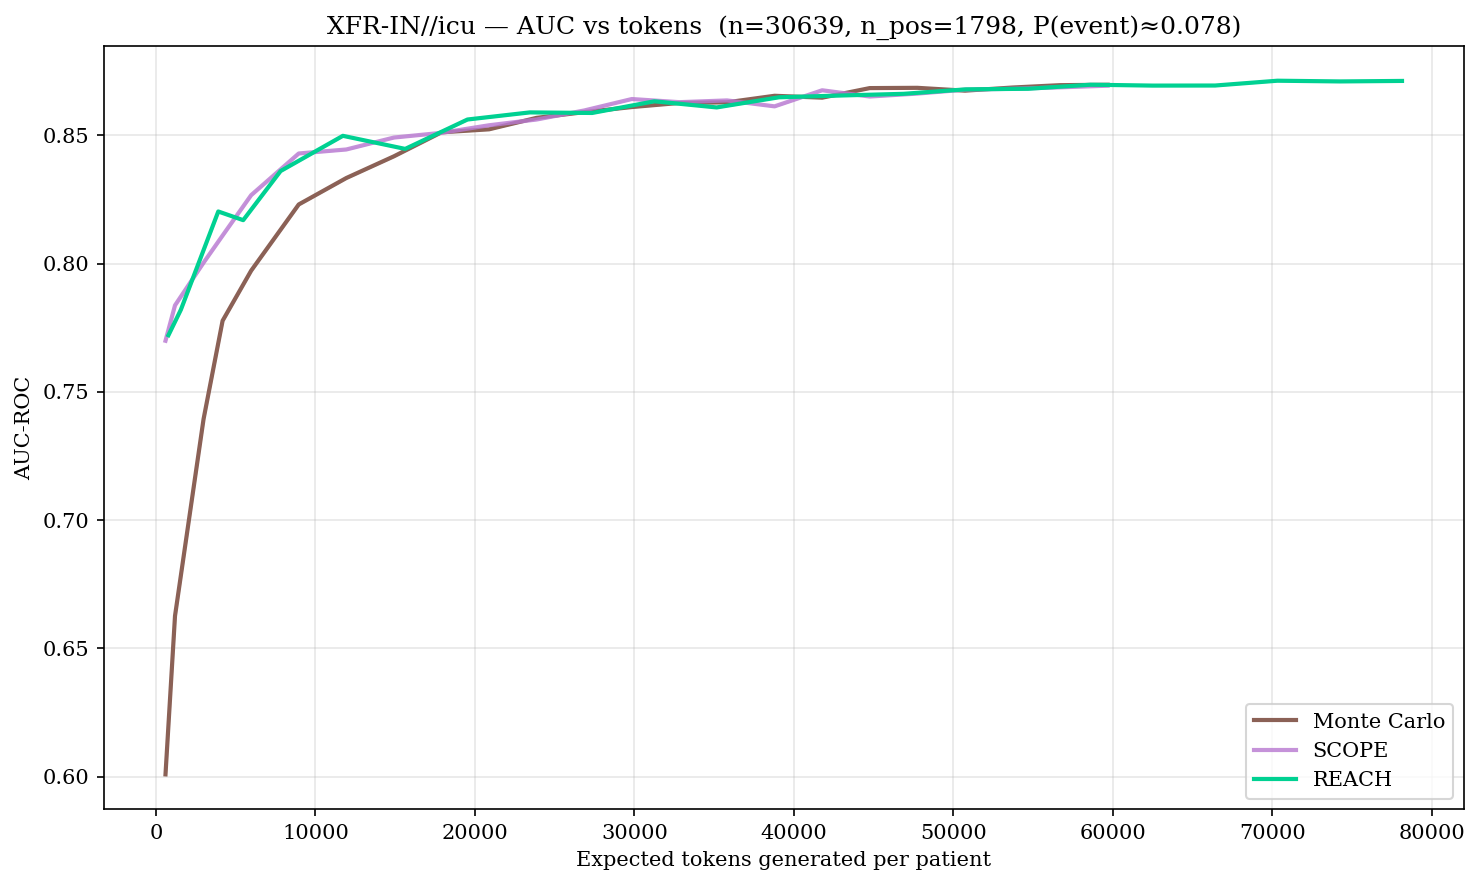

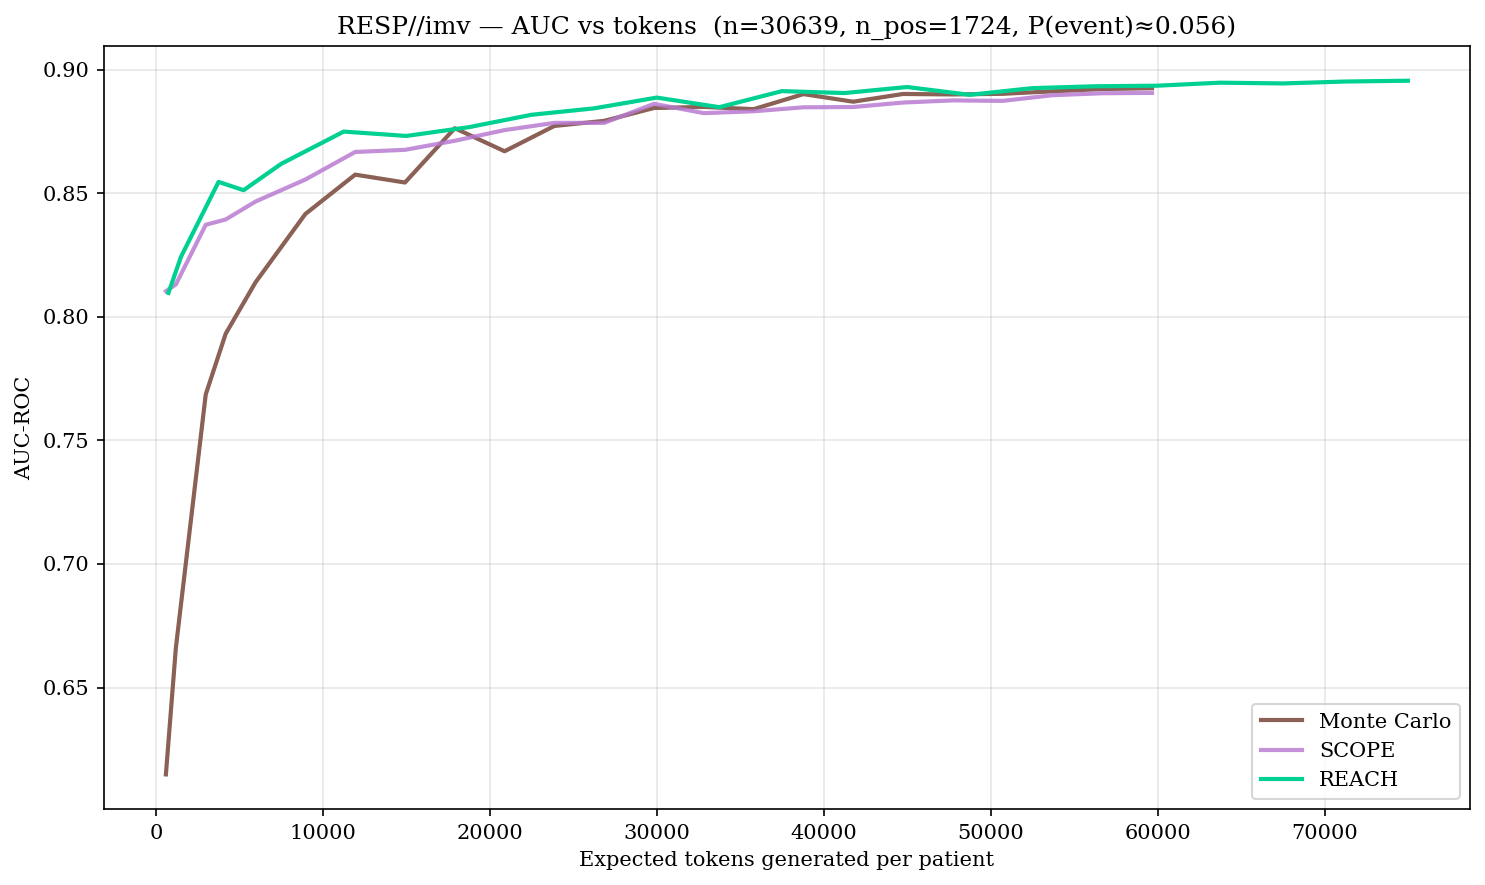

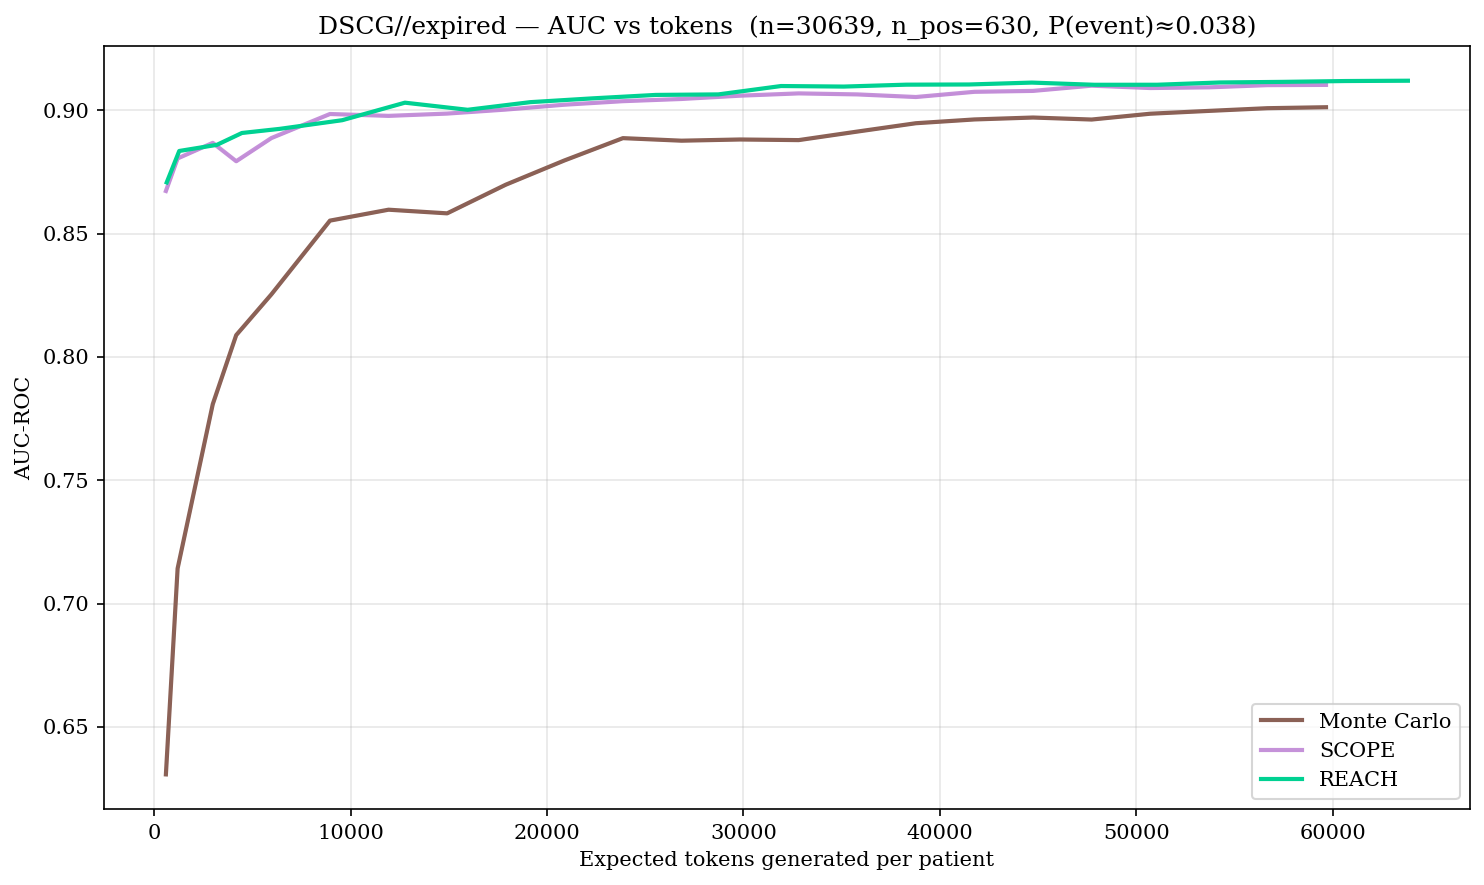

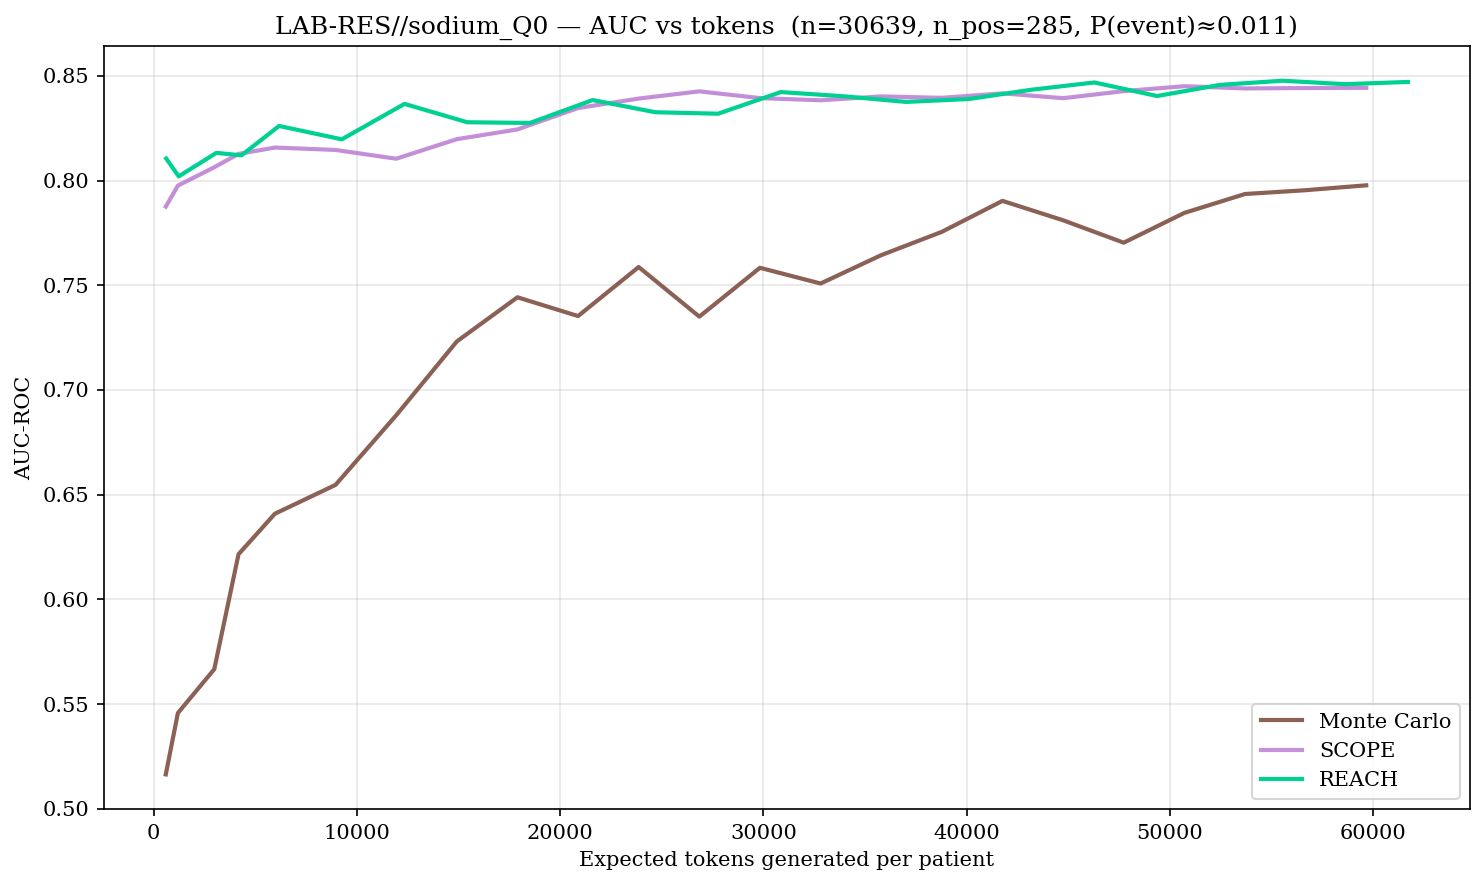

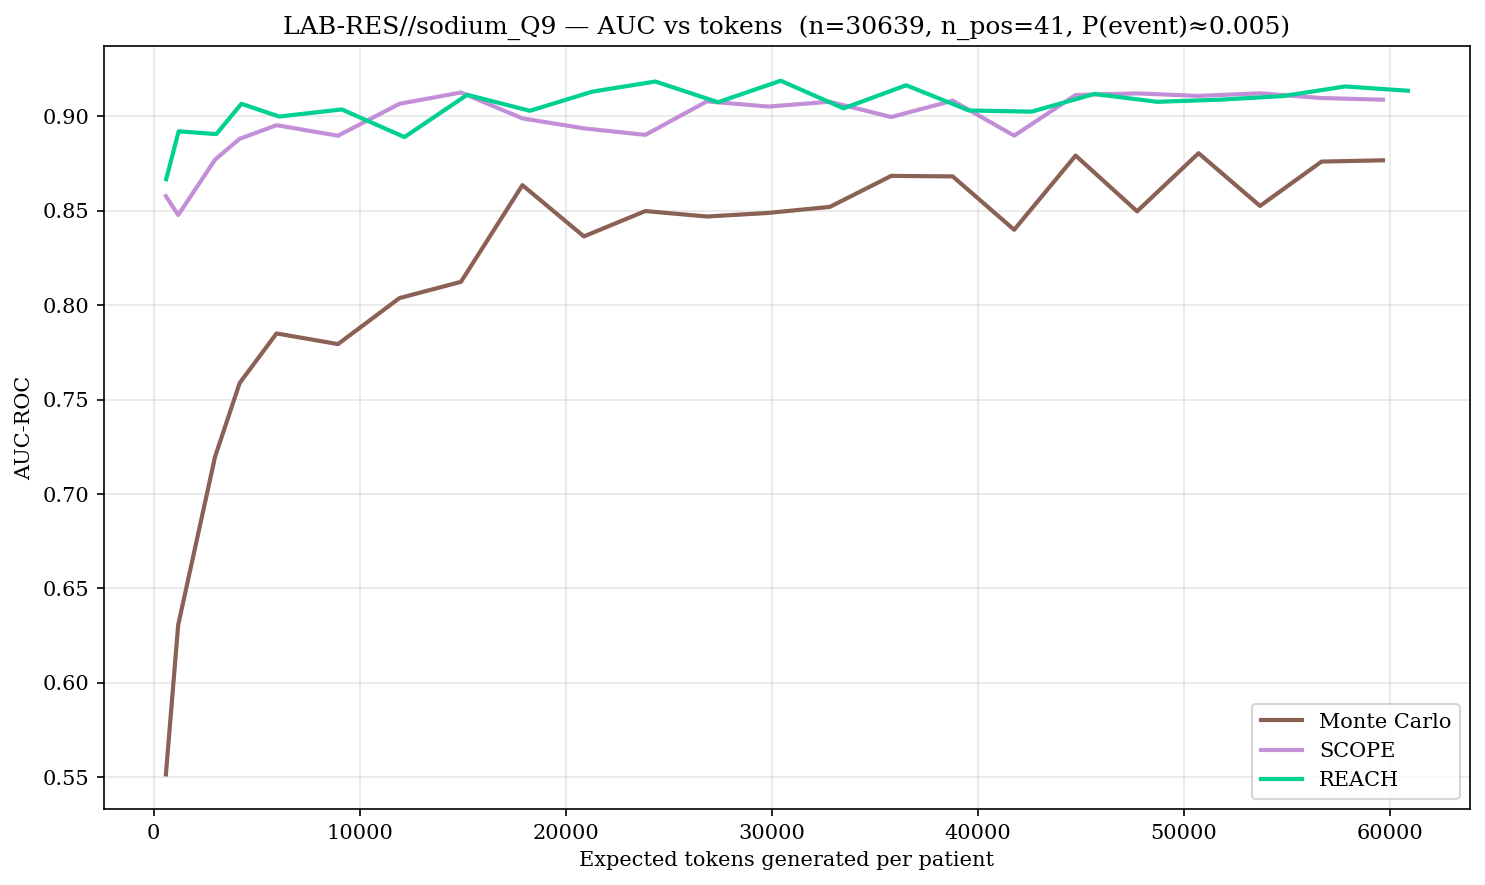

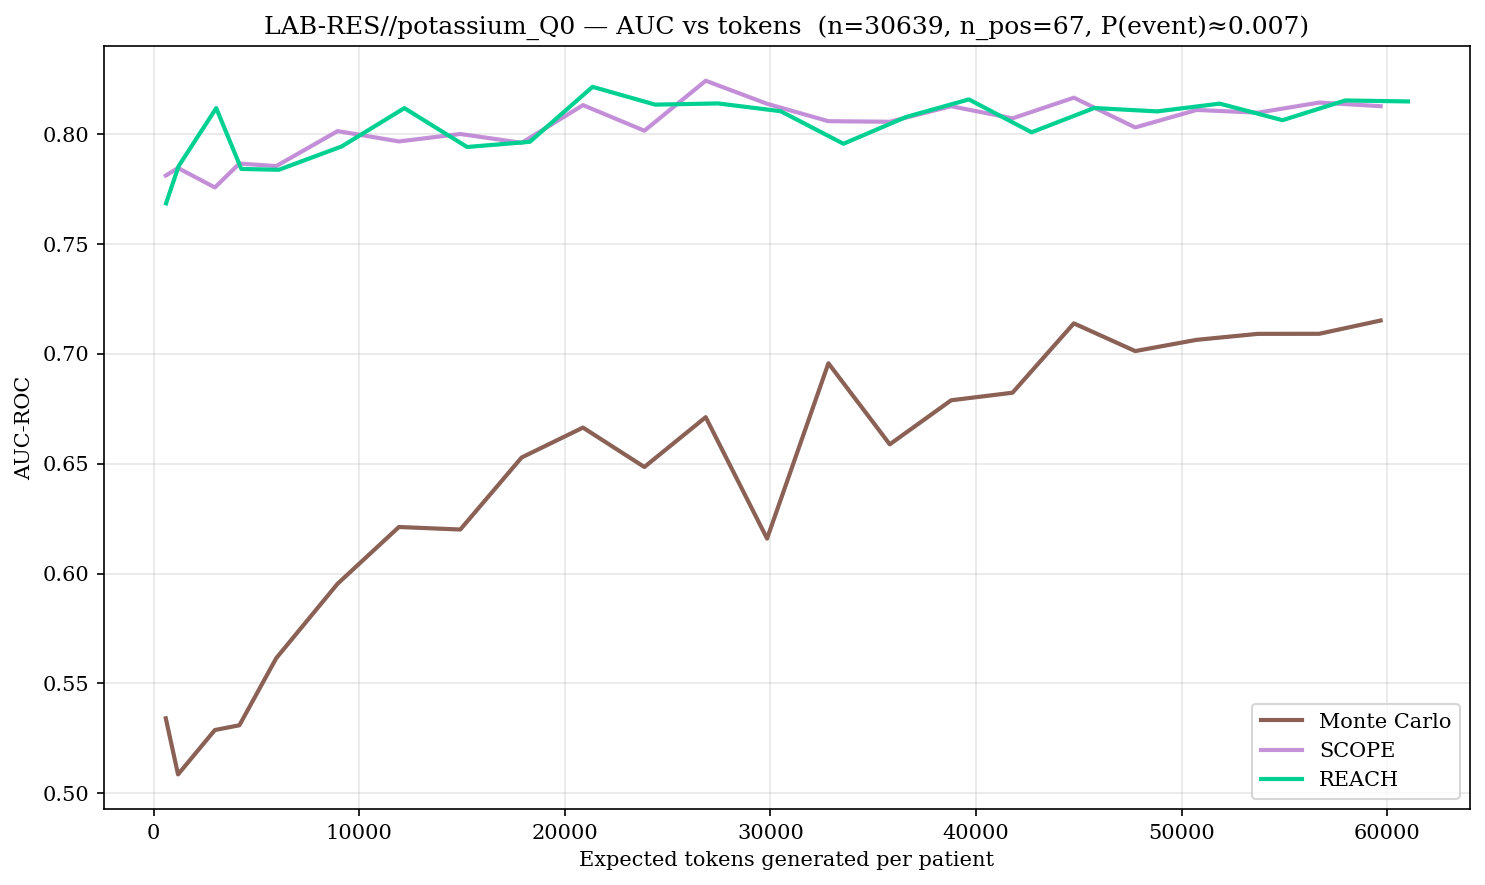

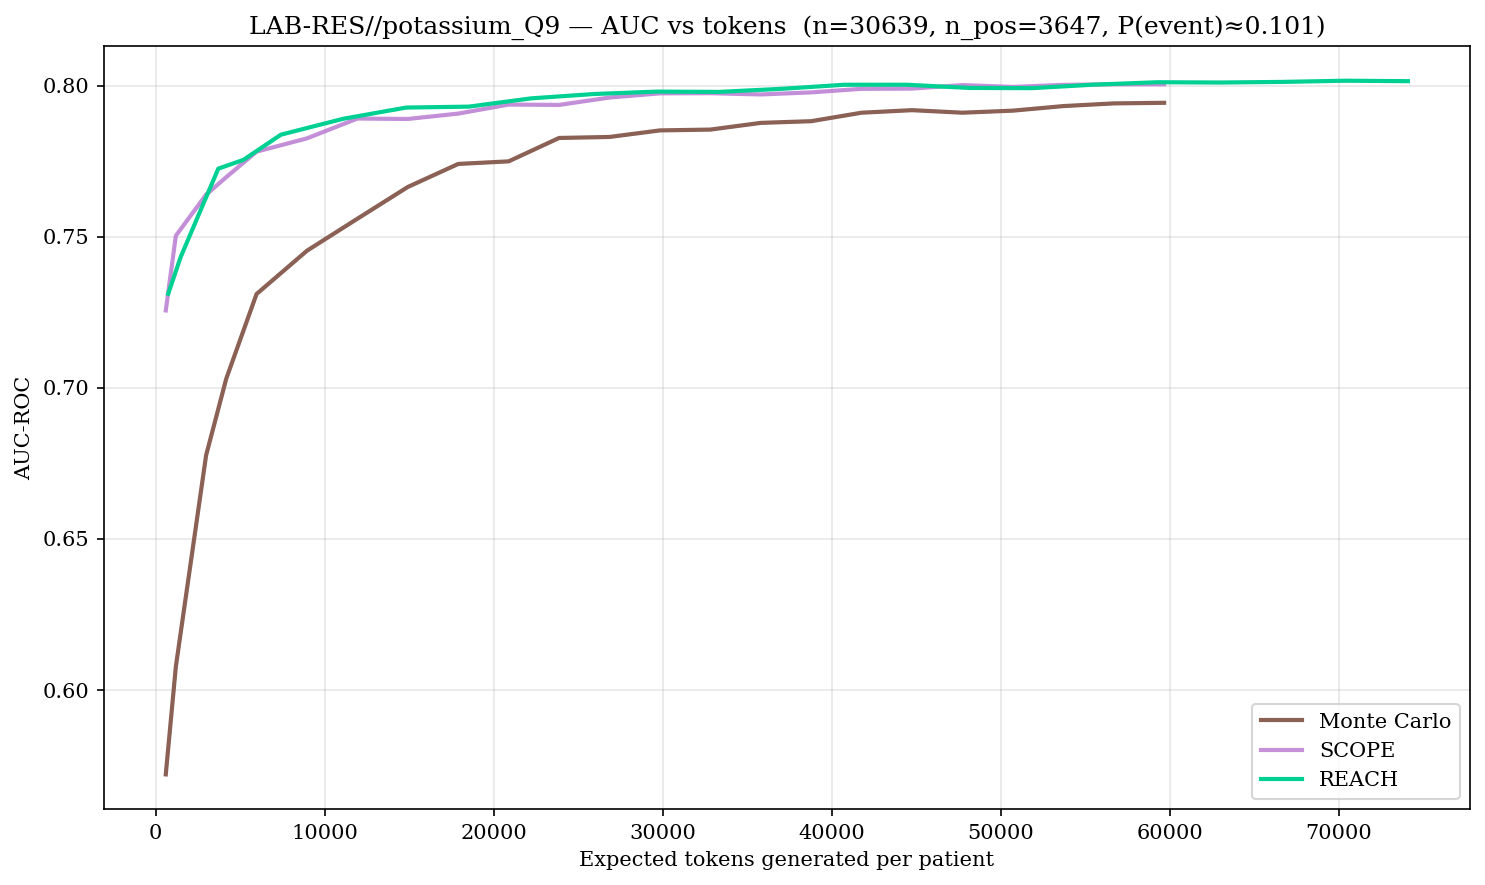

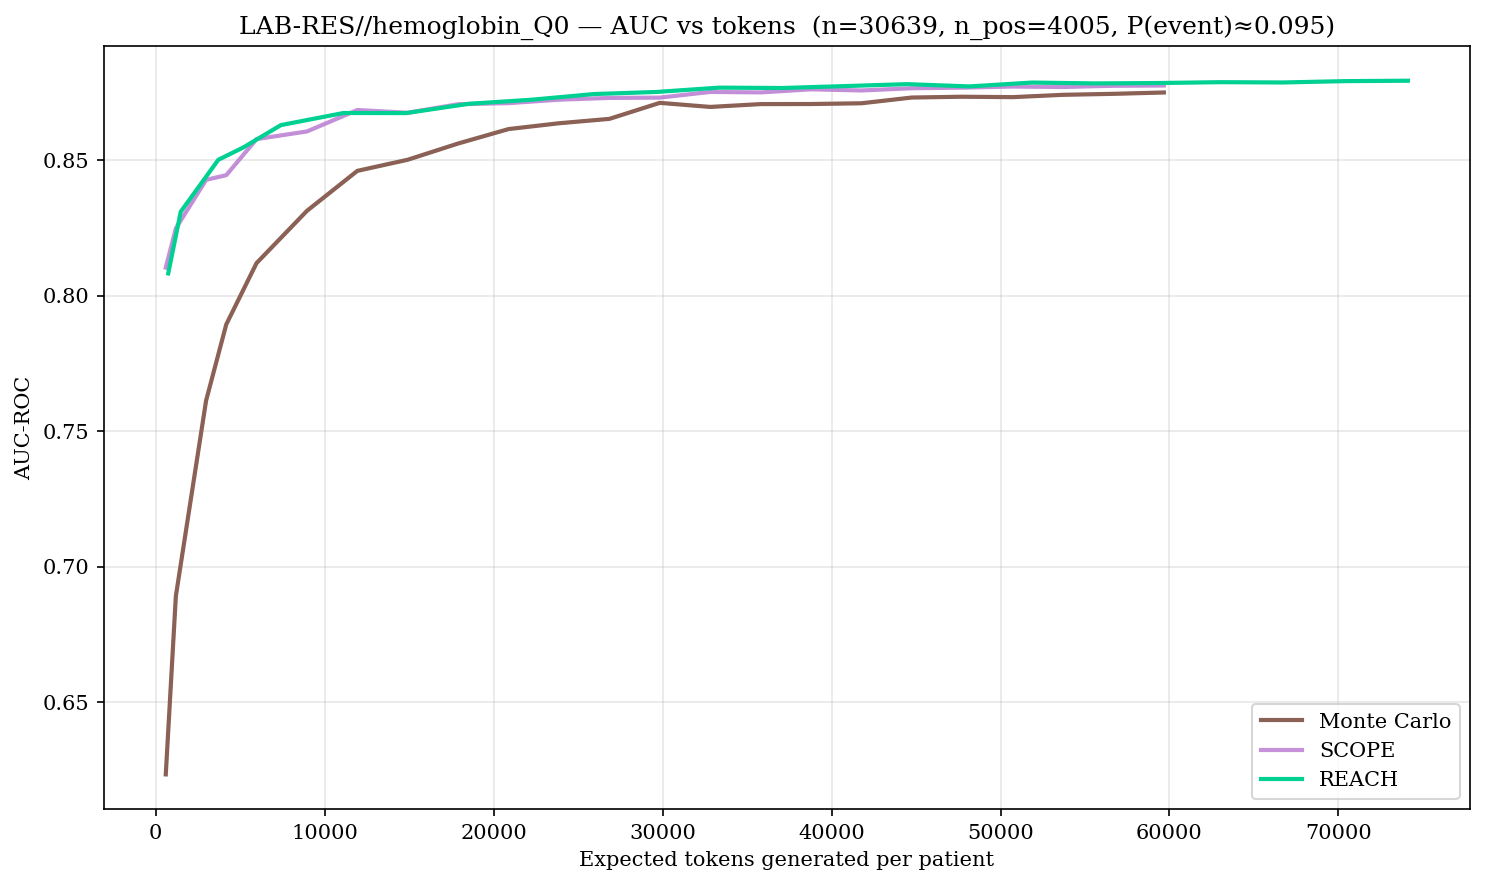

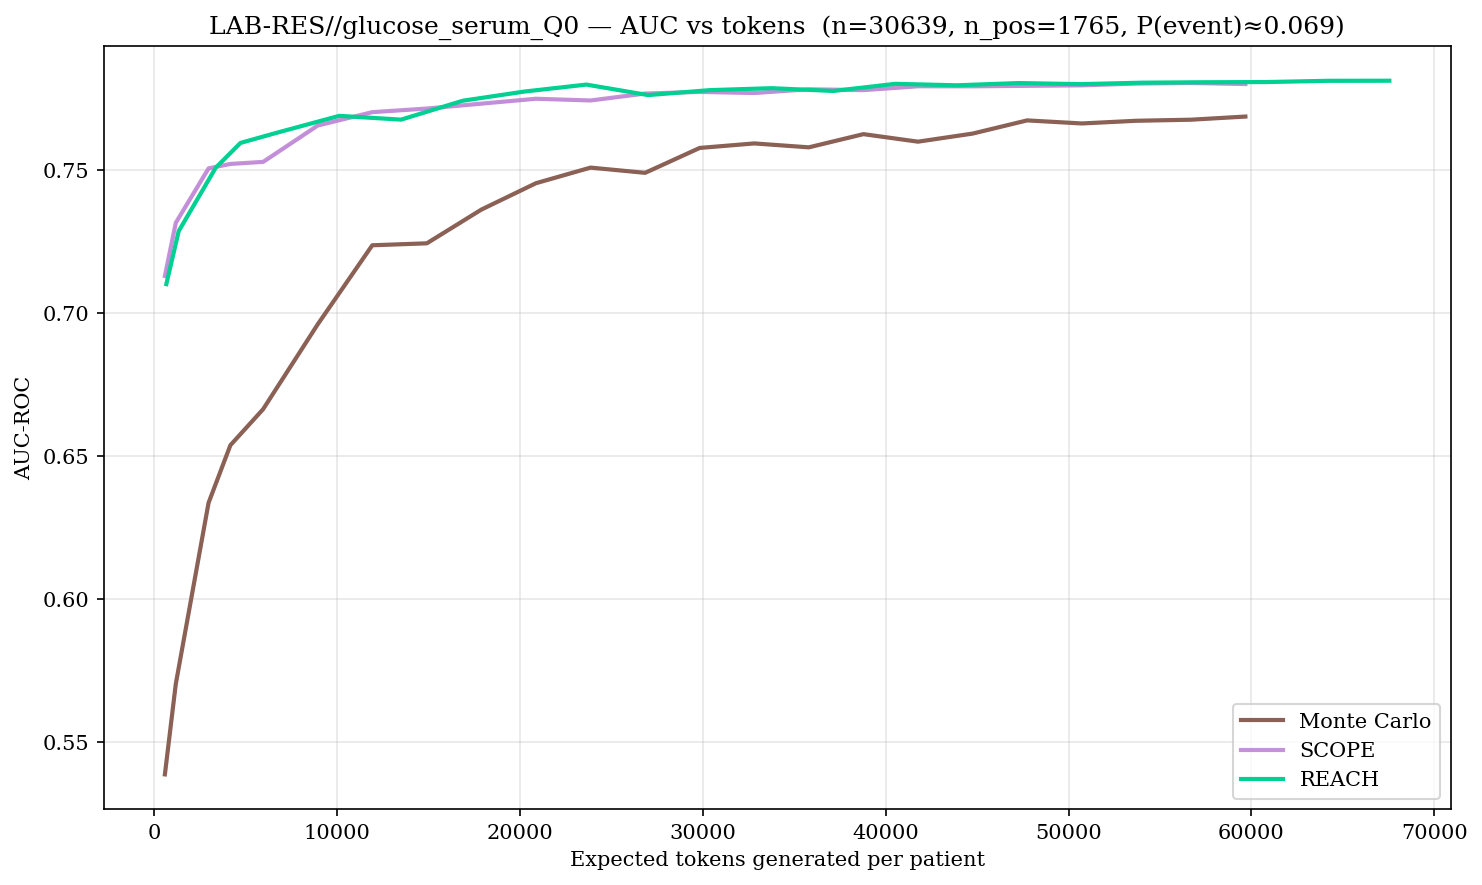

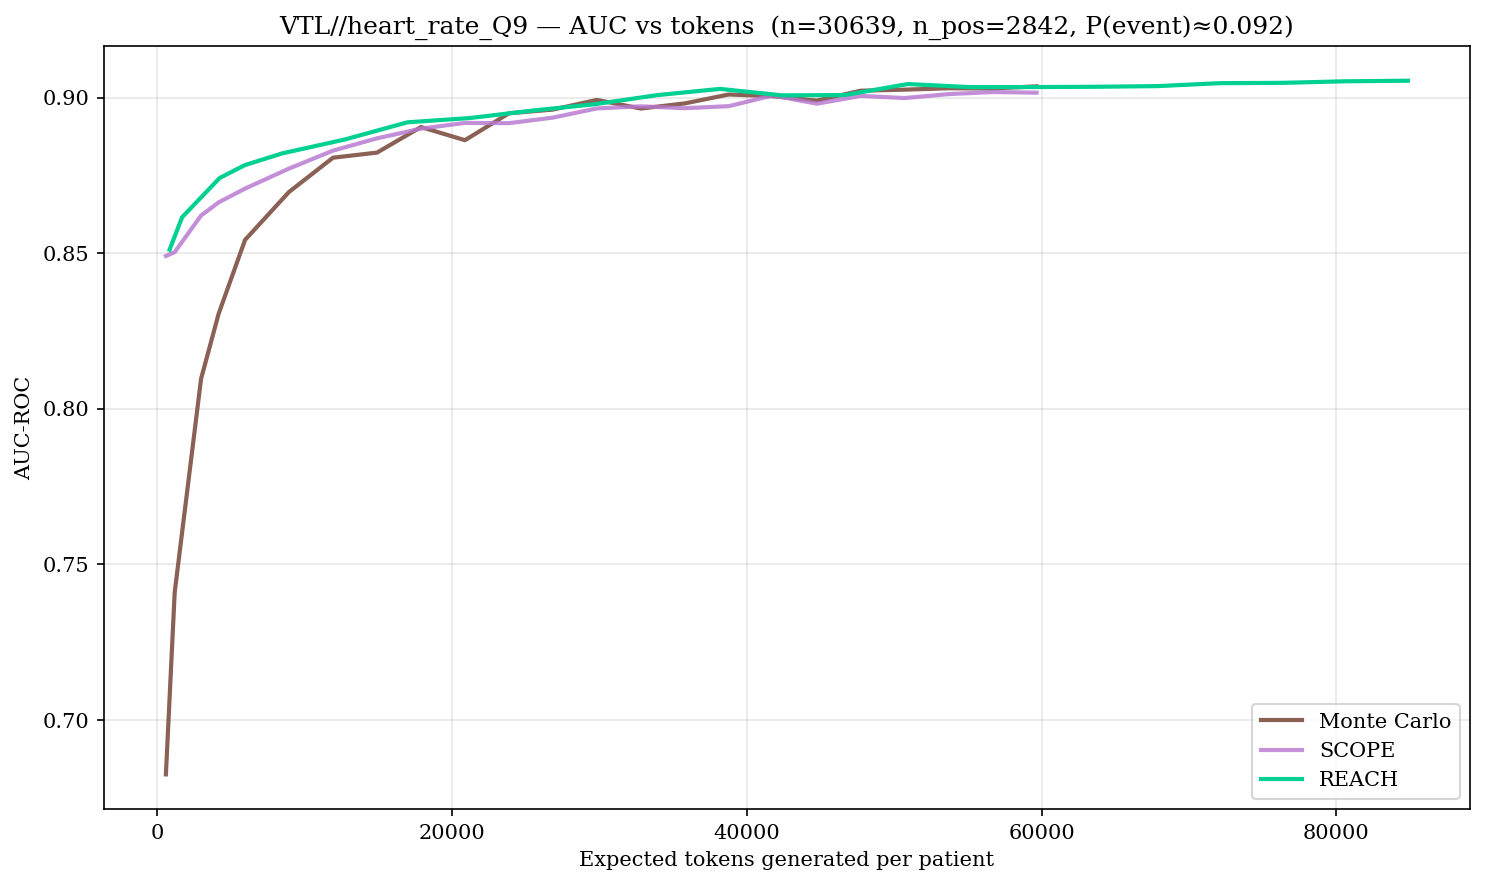

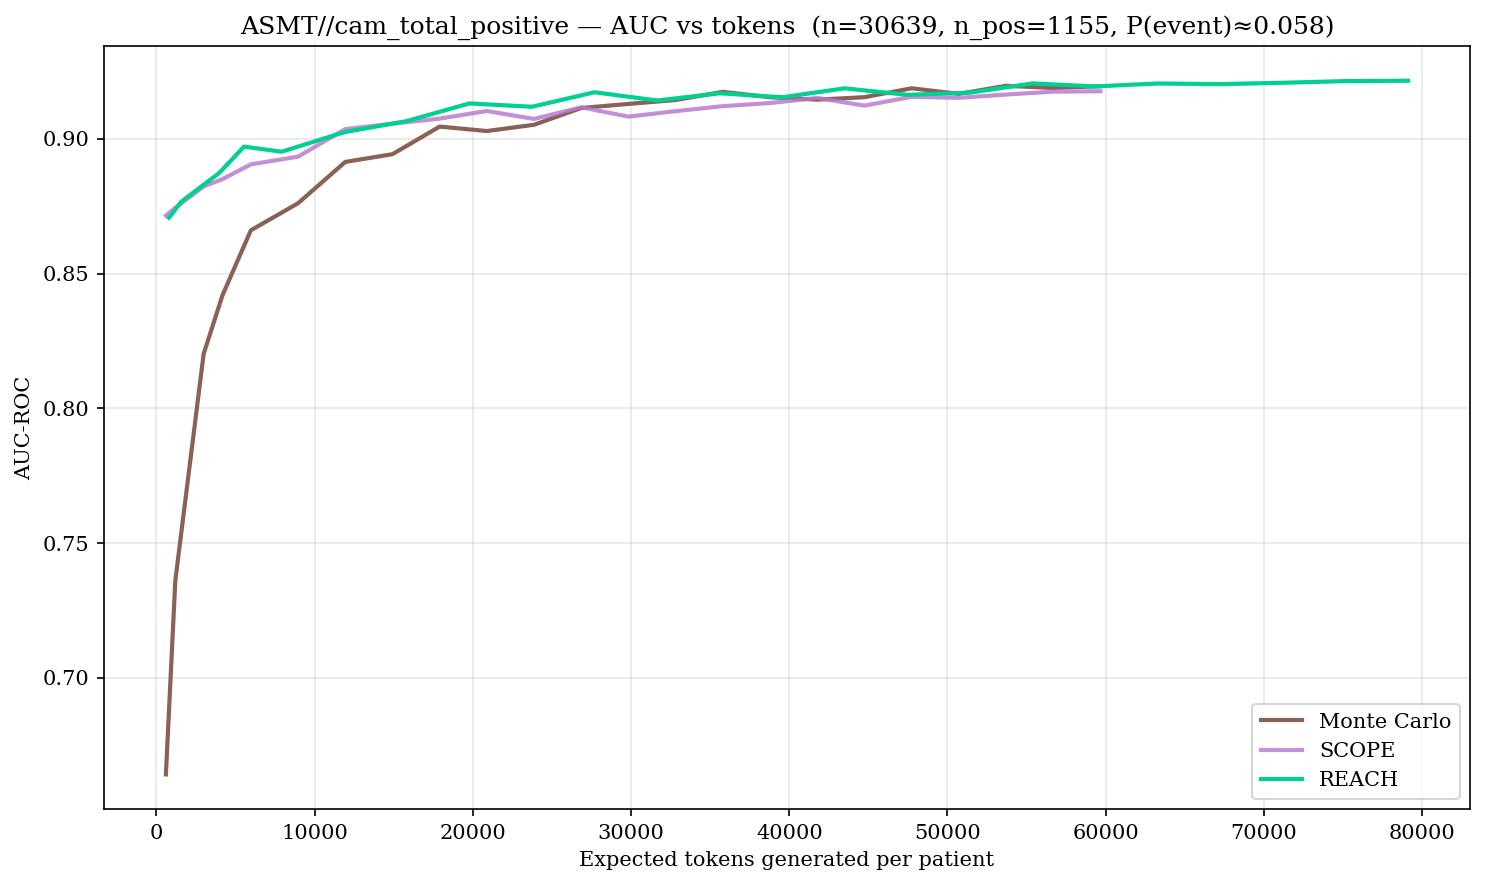

In [38]:
def _ci95(by_n, samp_list):
    lo, hi = [], []
    for n in samp_list:
        v = np.array(by_n[n])
        lo.append(np.percentile(v, 2.5))
        hi.append(np.percentile(v, 97.5))
    return np.array(lo), np.array(hi)


for _name, _od in outcome_data.items():
    _auc_list = _od["auc_list"]
    if not _auc_list:
        print(f"No AUC data for {_name} — skipping.")
        continue

    _avg_m1    = _od["avg_tokens_m1"]
    _avg_m2    = _od["avg_tokens_m2"]
    _prev_m0   = float(np.nanmean(_od["M0"]))
    _avg_reach = _avg_m2 * _prev_m0 if MARGINAL else (_avg_m1 + _avg_m2 * _prev_m0)

    _samp_list = np.array(sorted(set(item[1] for item in _auc_list)))
    _mc_by_n   = {n: [item[0][0] for item in _auc_list if item[1] == n] for n in _samp_list}
    _sc_by_n   = {n: [item[0][1] for item in _auc_list if item[1] == n] for n in _samp_list}
    _re_by_n   = {n: [item[0][2] for item in _auc_list if item[1] == n] for n in _samp_list}

    _mc_mean = np.array([np.mean(_mc_by_n[n]) for n in _samp_list])
    _sc_mean = np.array([np.mean(_sc_by_n[n]) for n in _samp_list])
    _re_mean = np.array([np.mean(_re_by_n[n]) for n in _samp_list])

    _tok_mc = _samp_list * _avg_m1
    _tok_sc = _samp_list * _avg_m1
    _tok_re = _samp_list * _avg_reach

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    for _est, _mean, _by_n, _toks in [
        ("Monte Carlo", _mc_mean, _mc_by_n, _tok_mc),
        ("SCOPE",       _sc_mean, _sc_by_n, _tok_sc),
        ("REACH",       _re_mean, _re_by_n, _tok_re),
    ]:
        _lo, _hi = _ci95(_by_n, _samp_list)
        _c = COLORS[_est]
        ax.plot(_toks, _mean, color=_c, label=_est, linewidth=2)
        ax.fill_between(_toks, _lo, _hi, color=_c, alpha=0.15)

    ax.set_xlabel("Expected tokens generated per patient")
    ax.set_ylabel("AUC-ROC")
    ax.set_title(f"{_name} — AUC vs tokens  (n={_od['n_patients']}, n_pos={_od['n_pos']}, P(event)≈{_prev_m0:.3f})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Token-efficiency plot

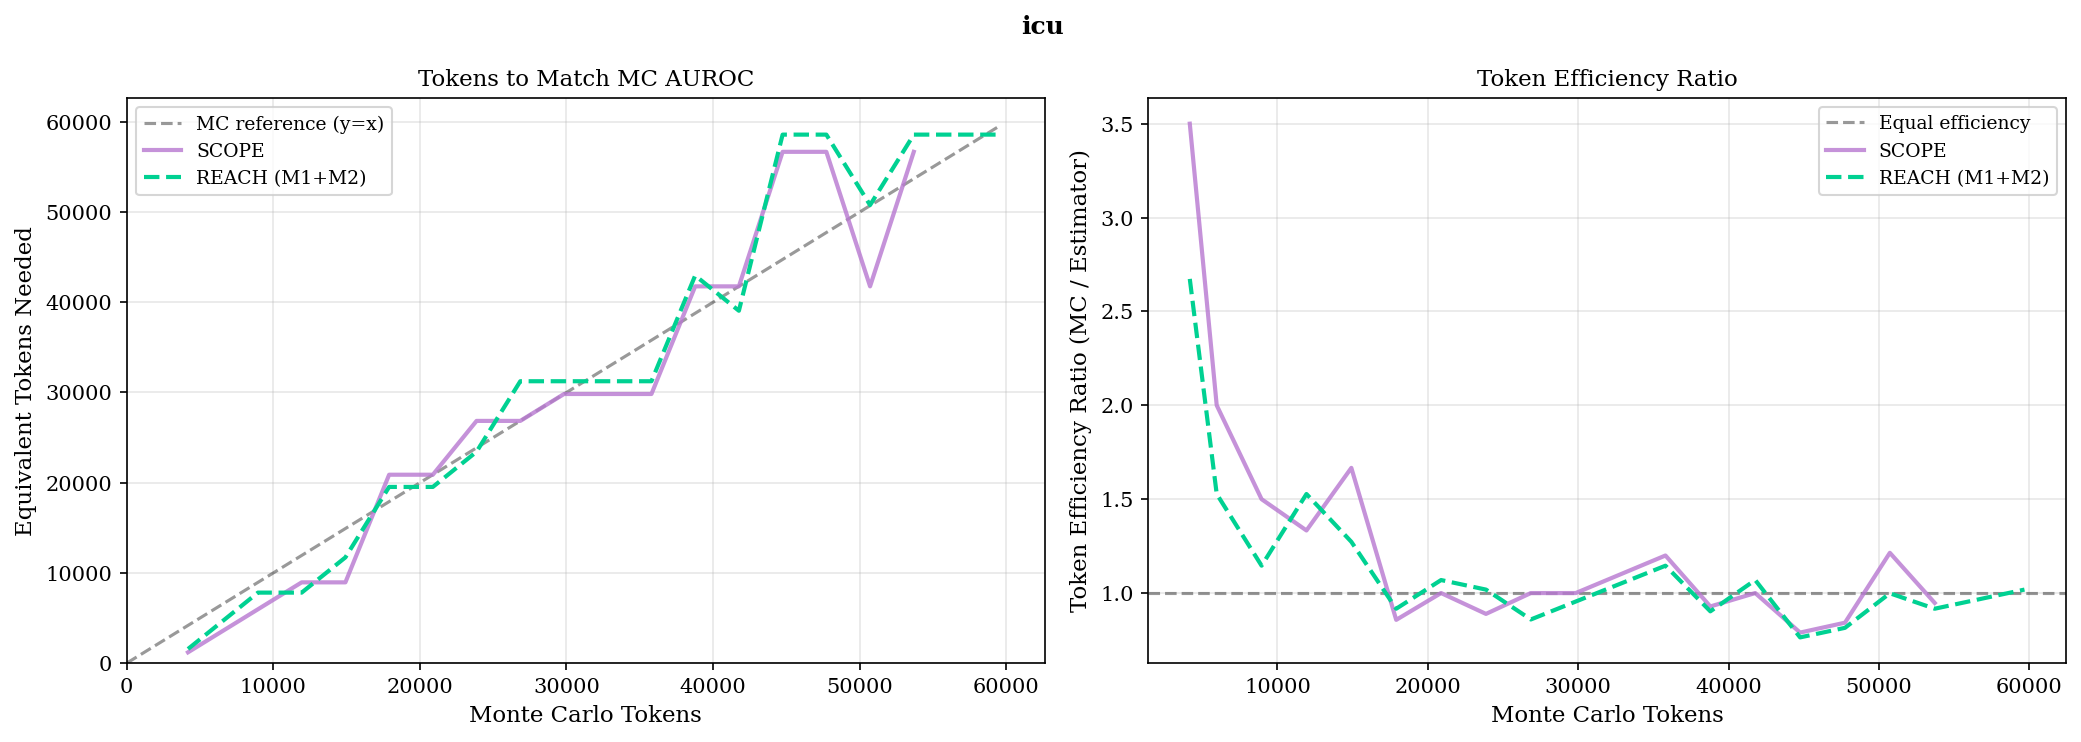

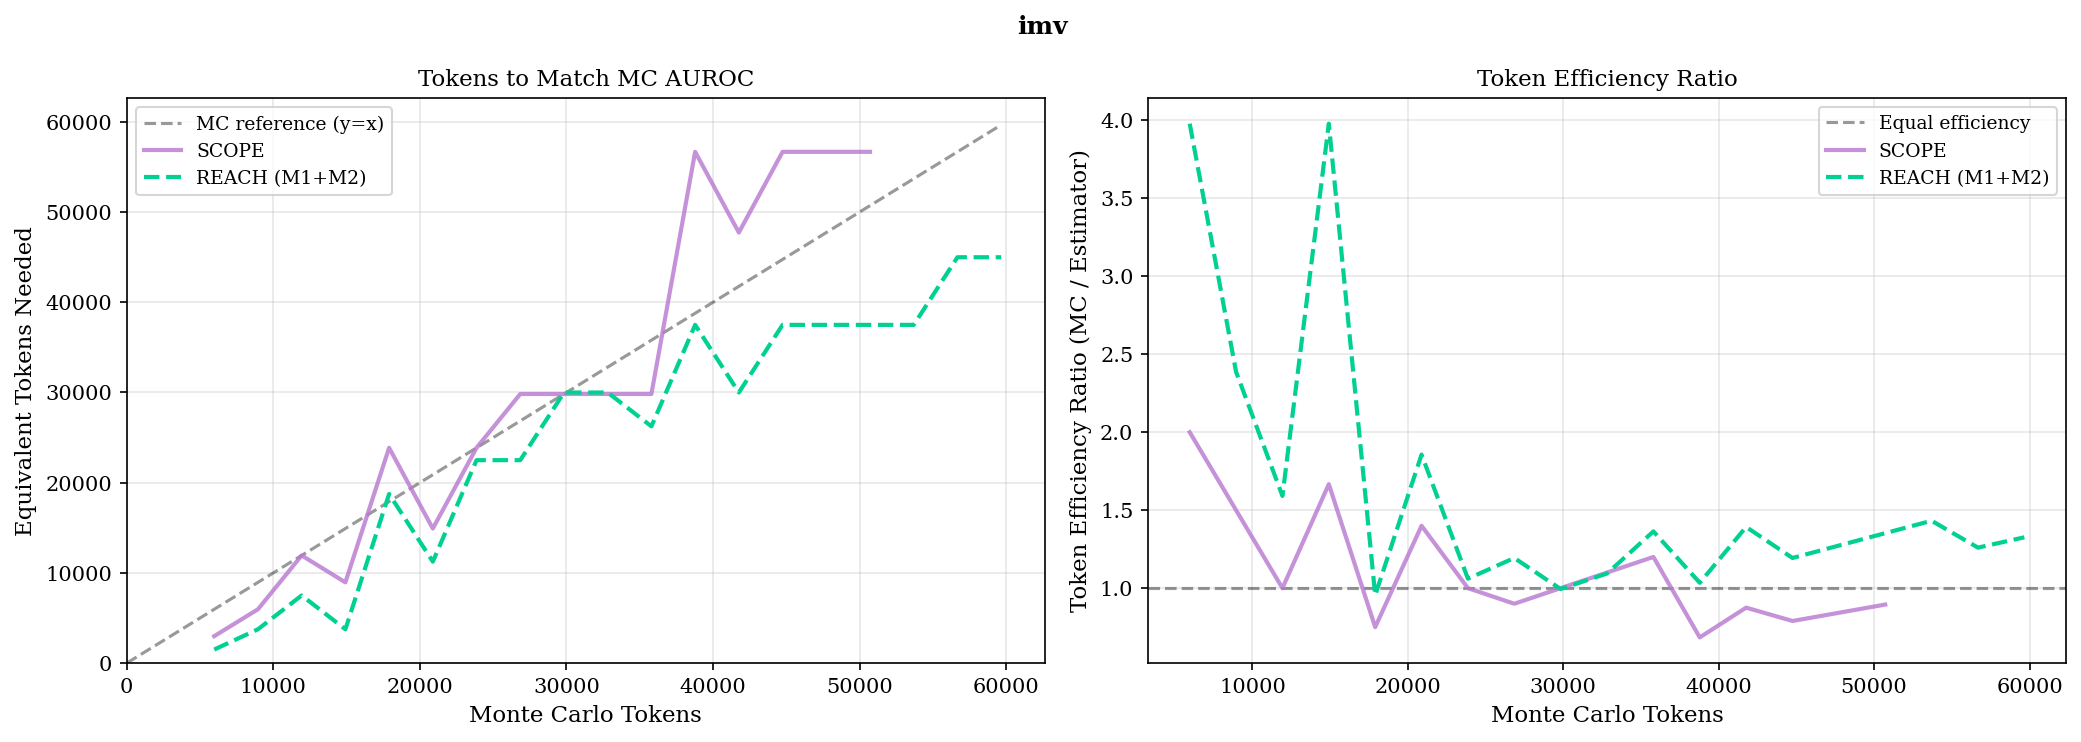

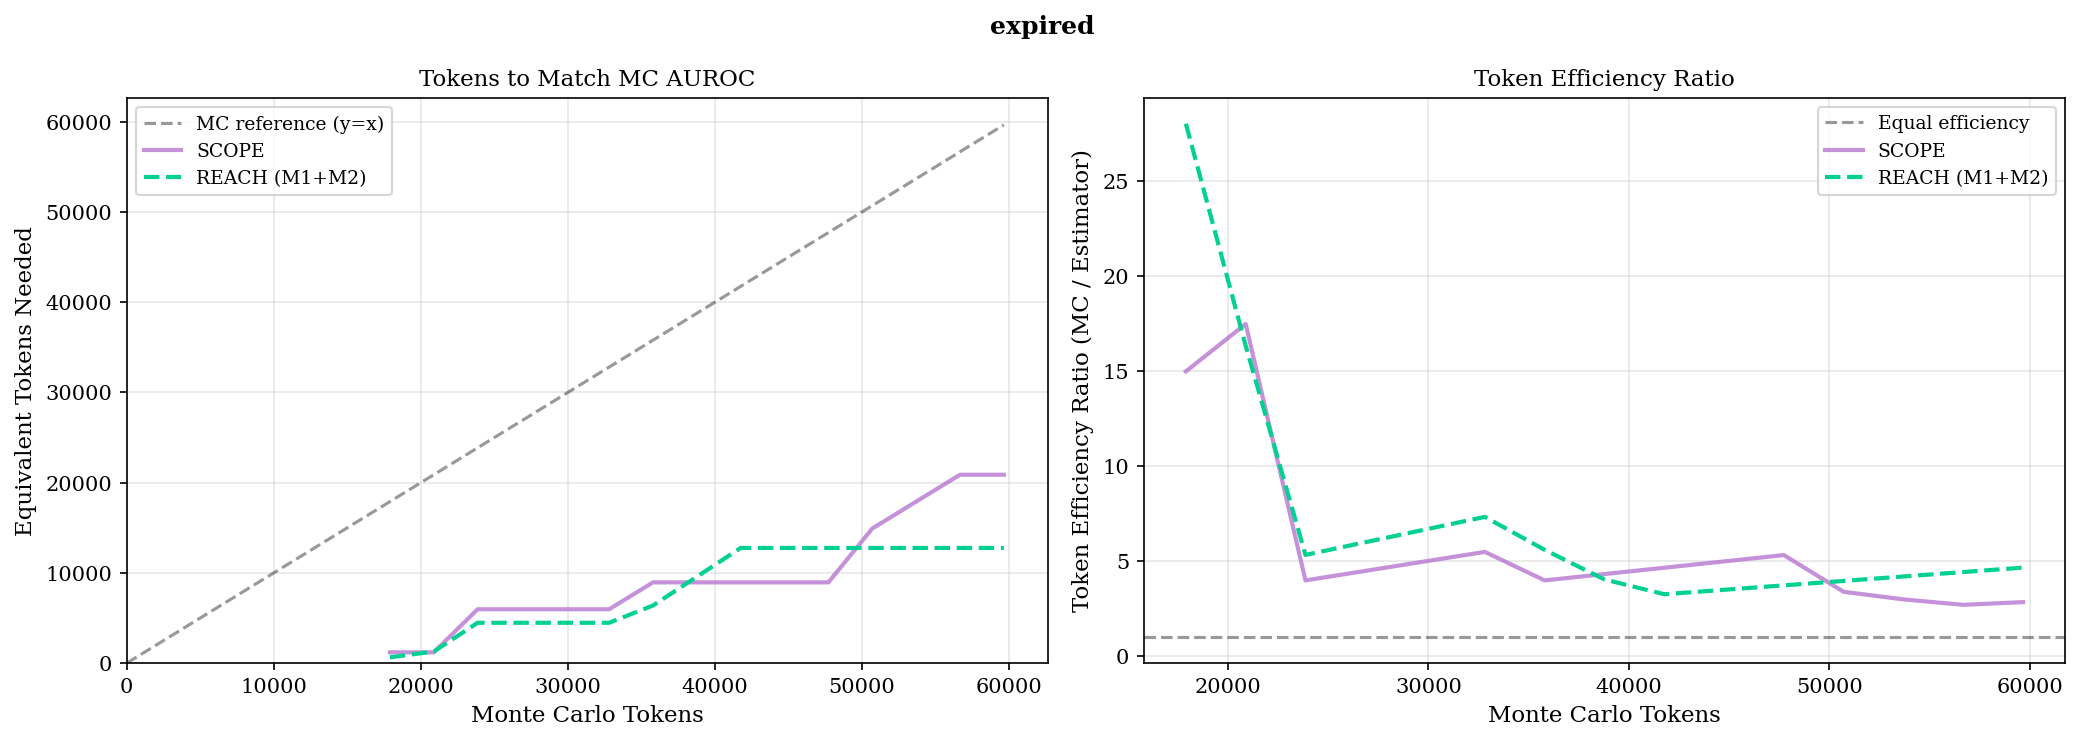

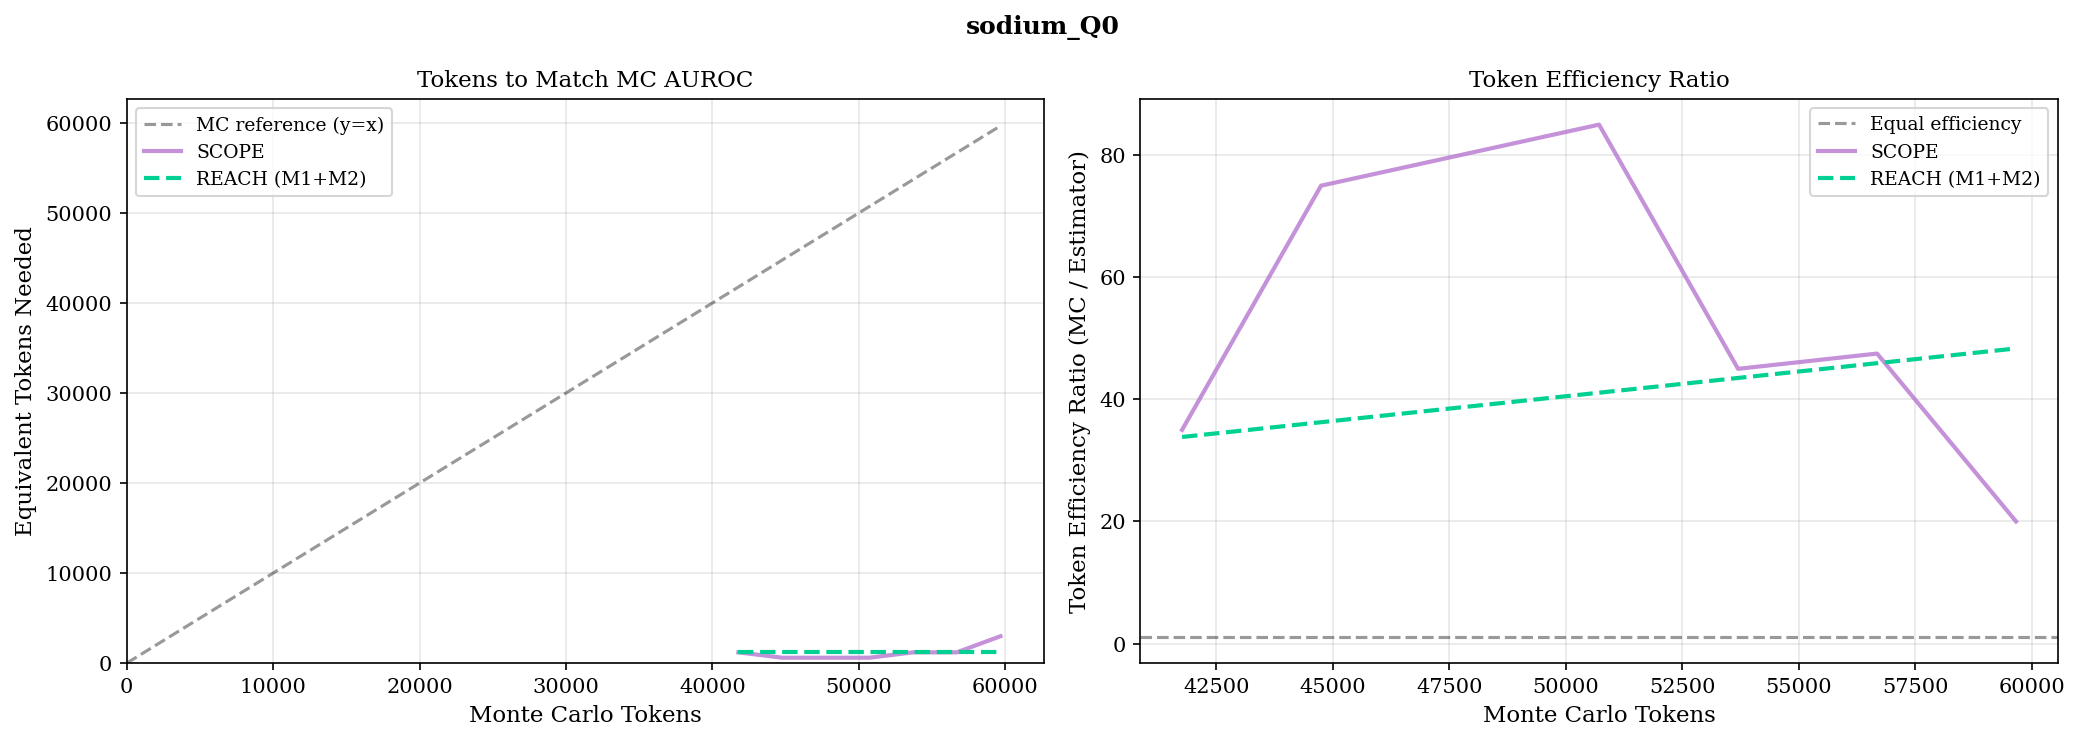

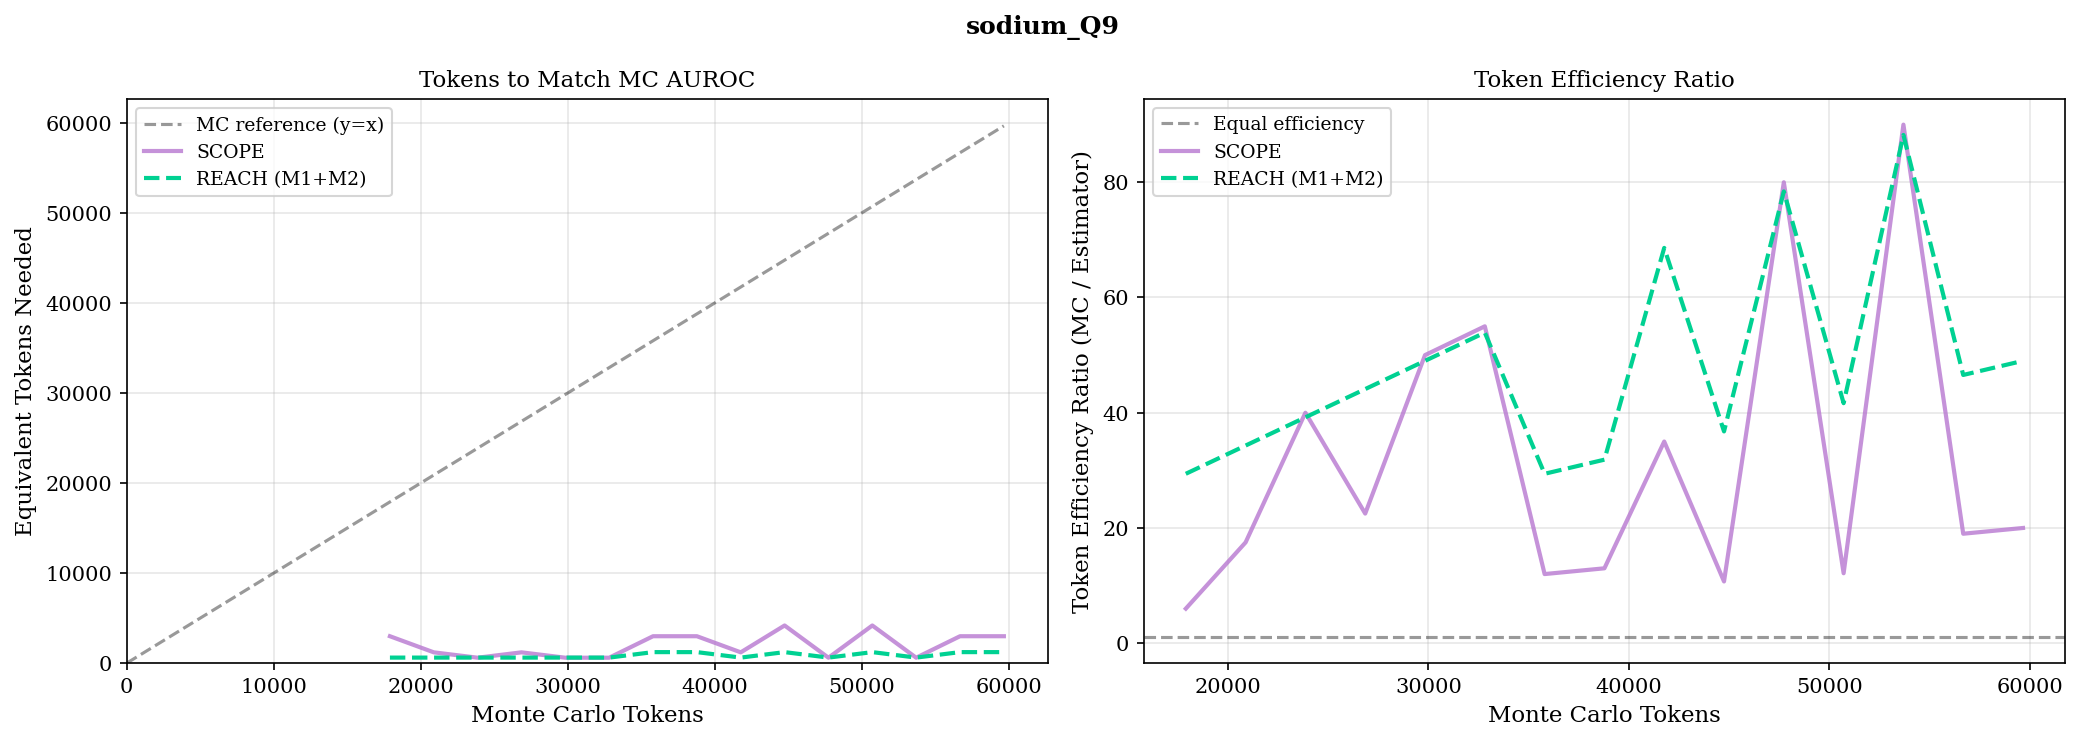

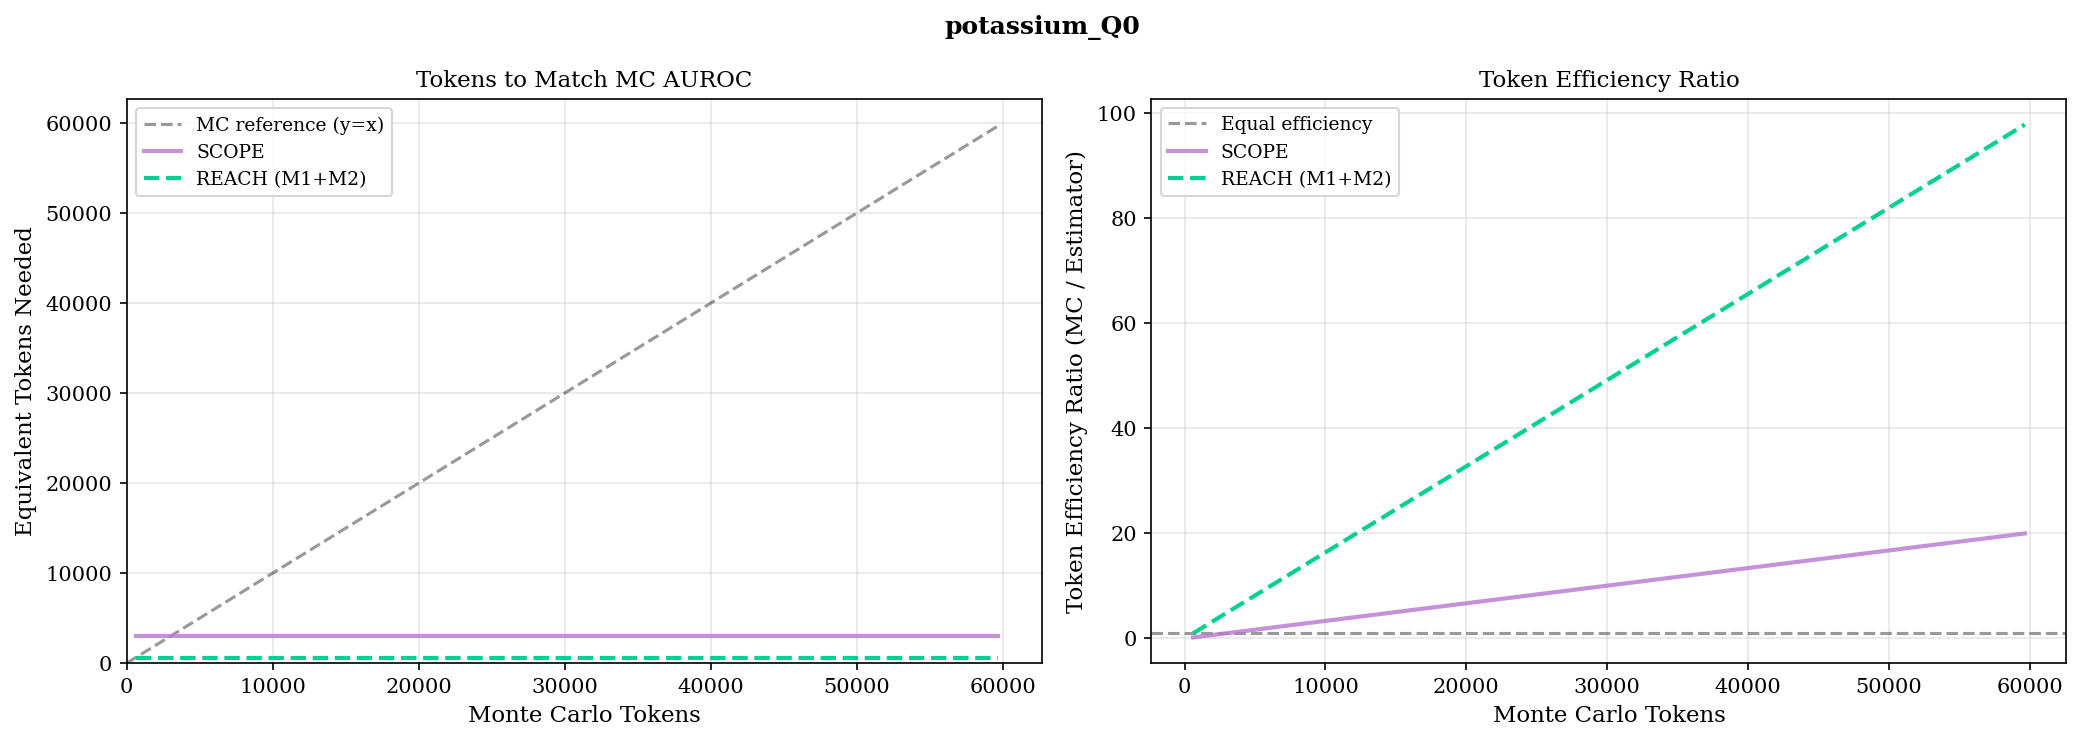

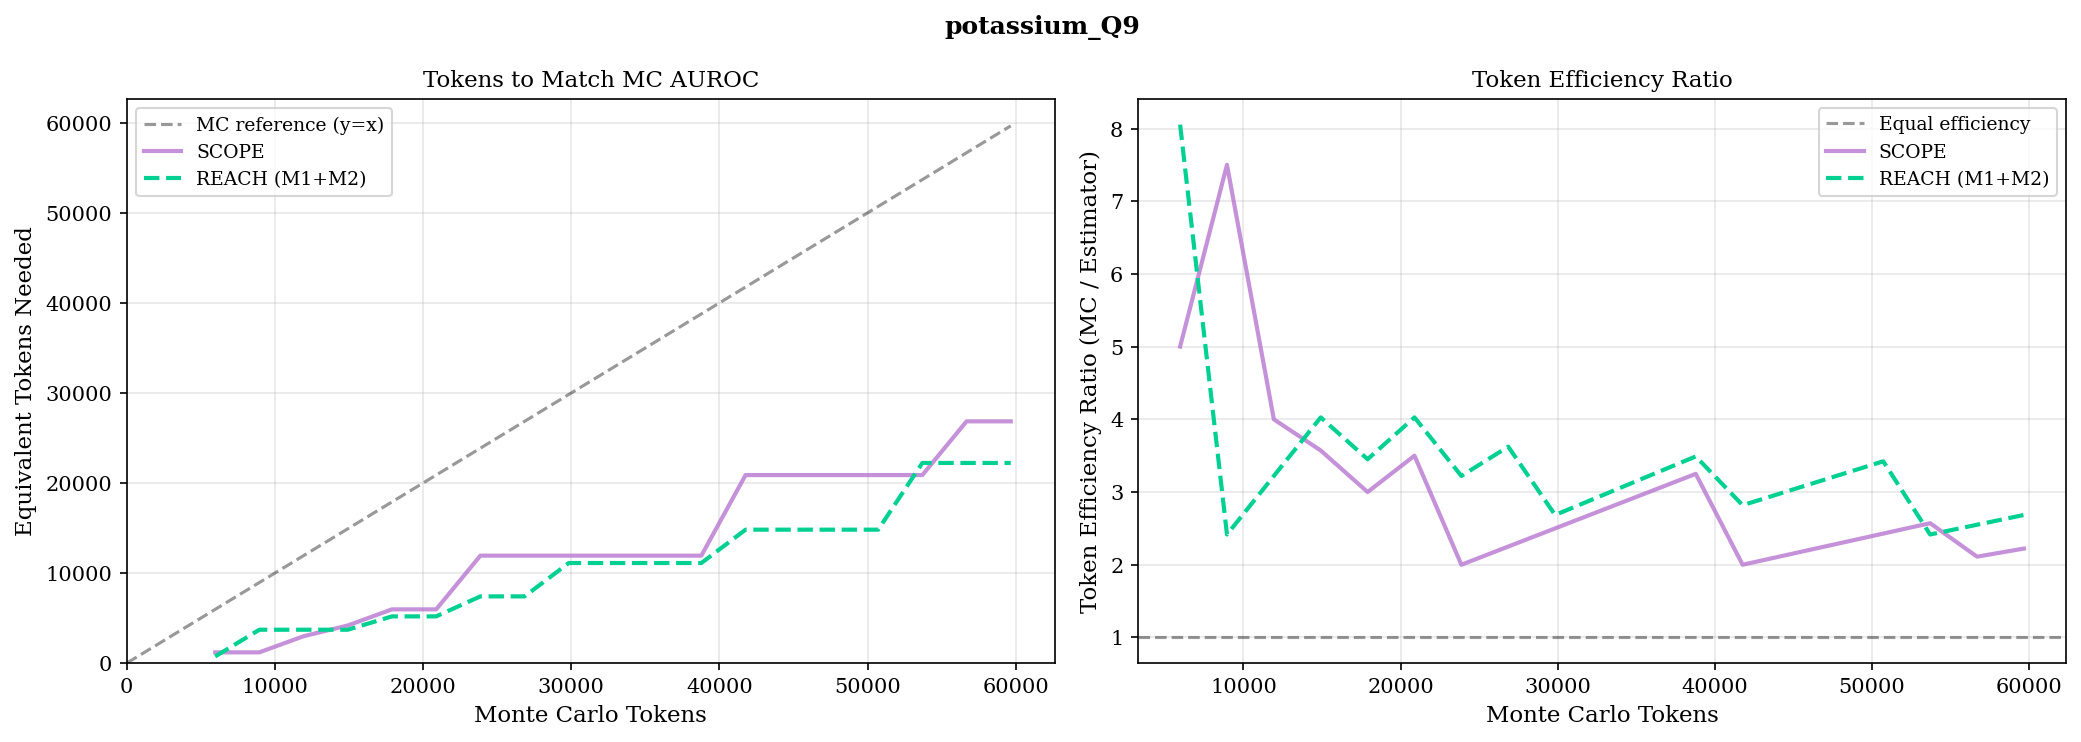

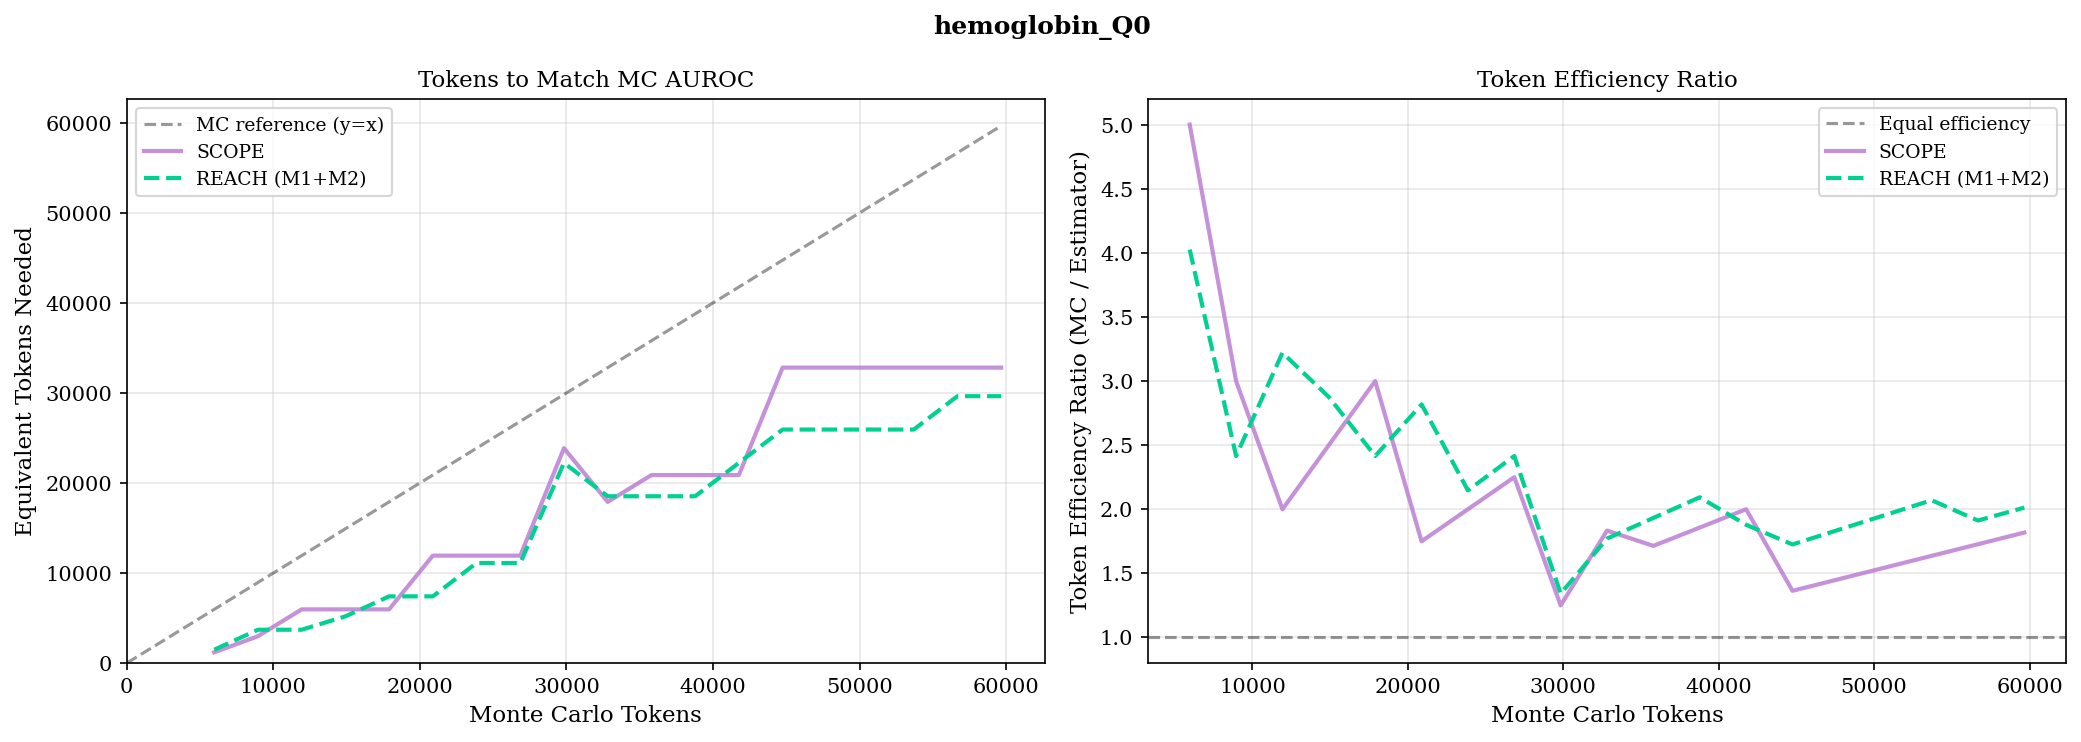

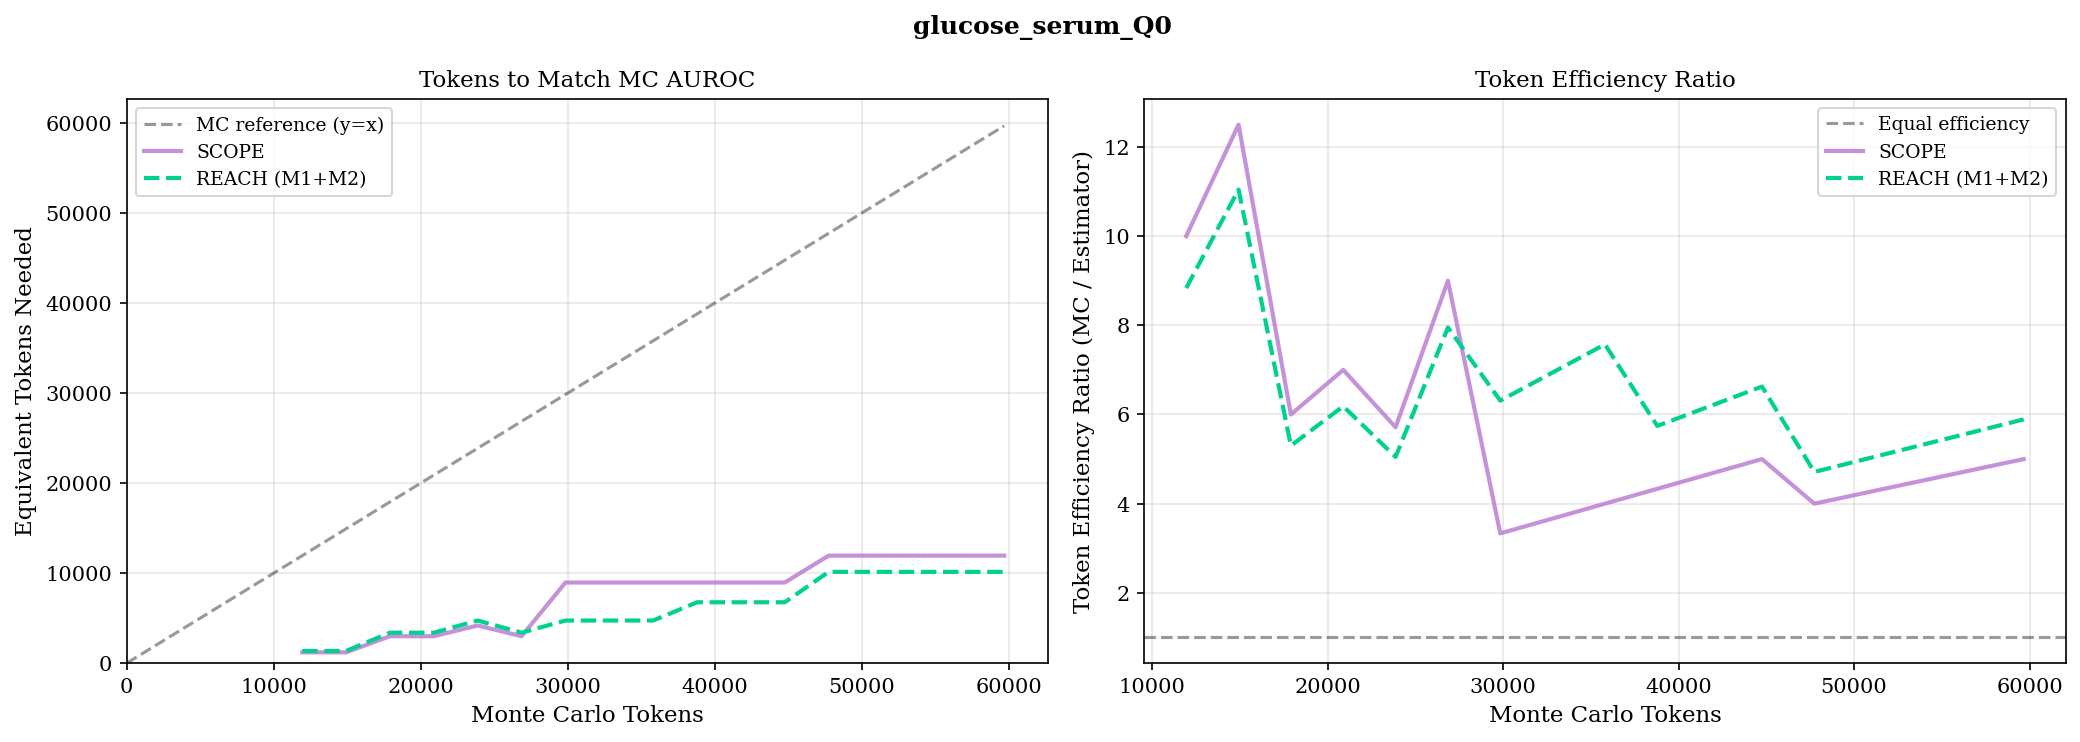

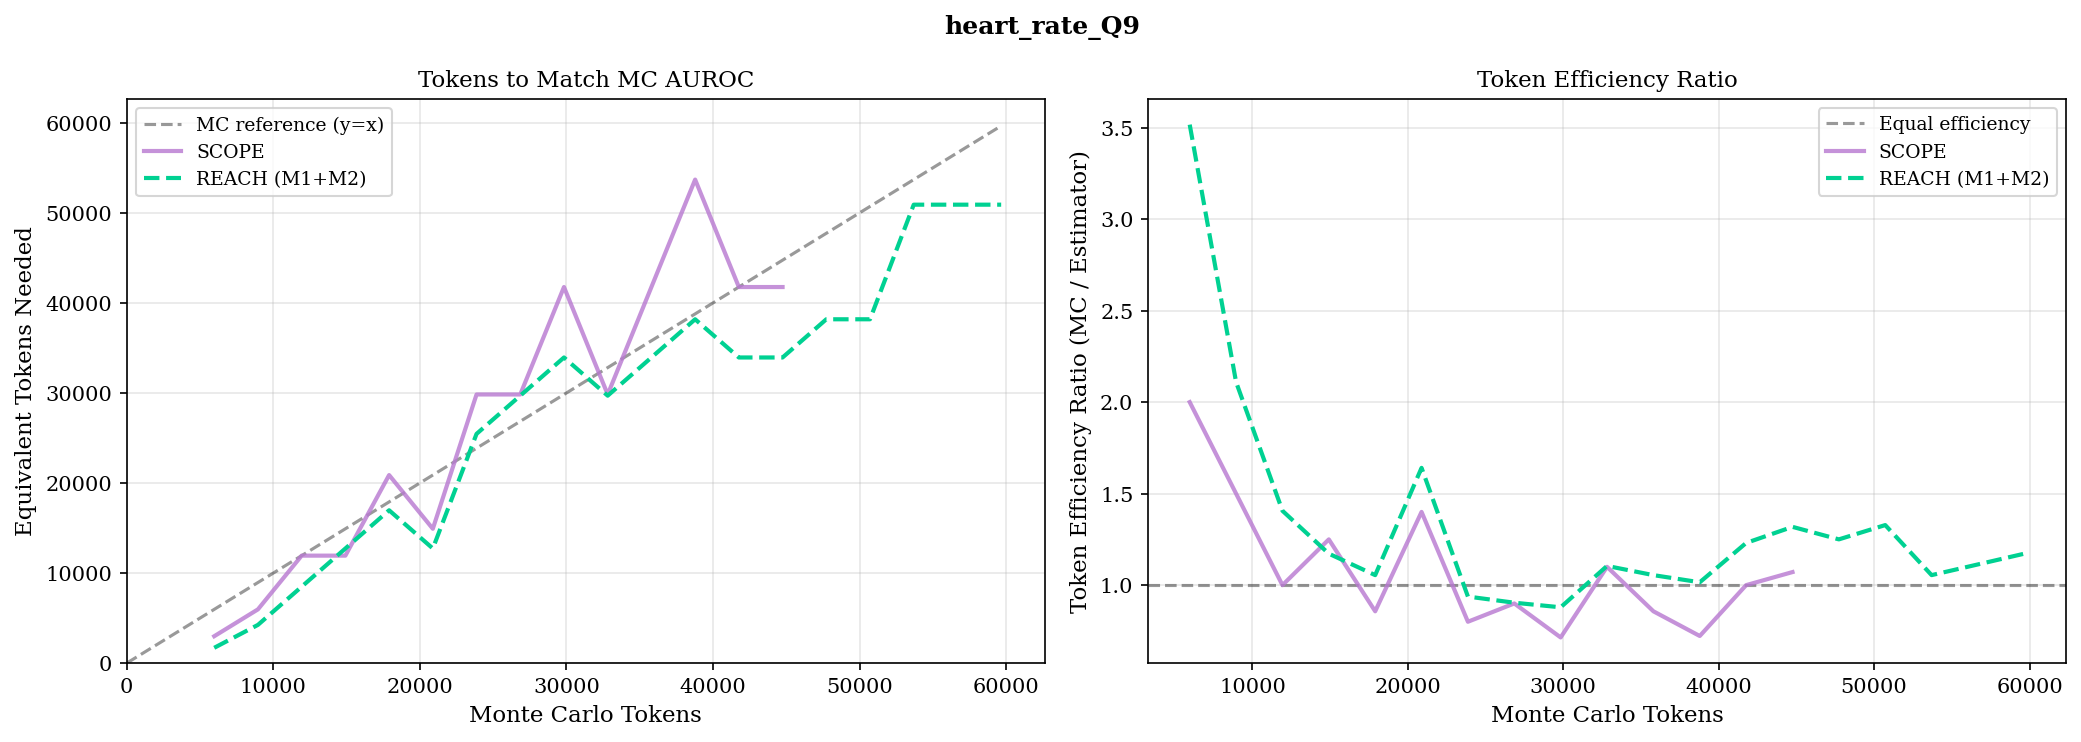

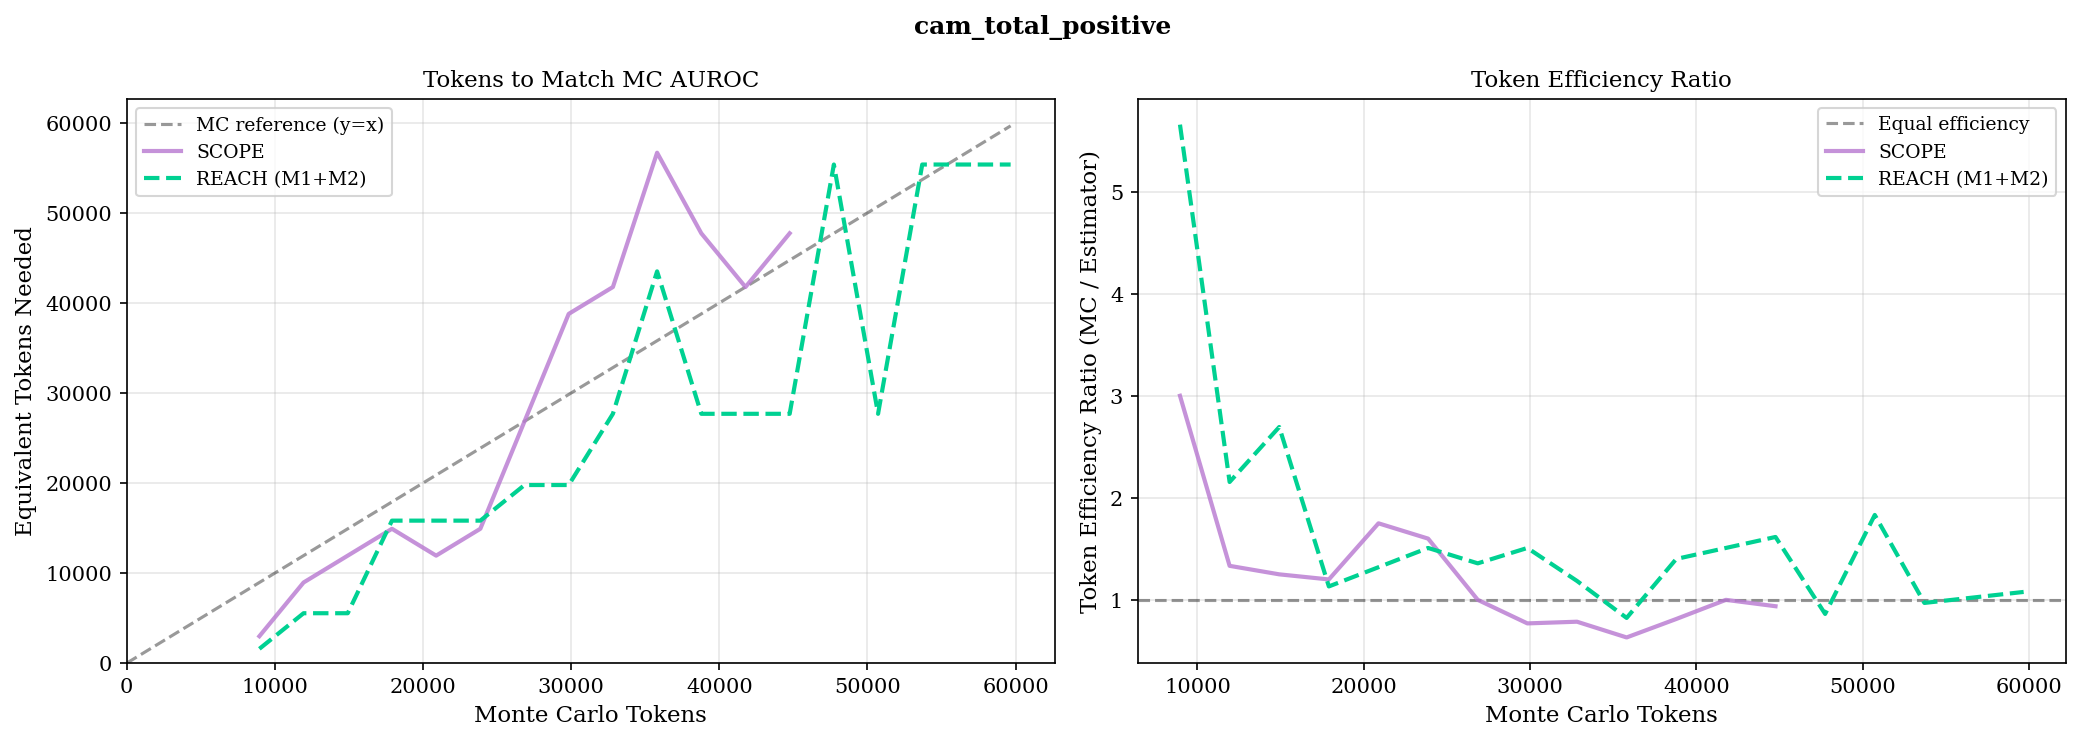

In [39]:
def _find_equivalent_samples(target_perf, comp_samples, comp_perf, higher_is_better=True):
    if higher_is_better:
        if target_perf > comp_perf.max():
            return np.nan
        if target_perf <= comp_perf.min():
            return comp_samples[np.argmin(comp_perf)]
    else:
        if target_perf < comp_perf.min():
            return np.nan
        if target_perf >= comp_perf.max():
            return comp_samples[np.argmax(comp_perf)]
    return np.min(comp_samples[comp_perf > target_perf])


def _compute_token_equivalence_curve(mc_samps, mc_perf, comp_samps, comp_perf,
                                     comp_tokens_per_sample, higher_is_better=True):
    equiv_n = np.array([
        _find_equivalent_samples(p, comp_samps, comp_perf, higher_is_better)
        for p in mc_perf
    ])
    return equiv_n * comp_tokens_per_sample


# ── Build per-outcome efficiency data ────────────────────────────────────────
_outcome_eff = {}

for _name, _od in outcome_data.items():
    _auc_list = _od["auc_list"]
    if not _auc_list:
        continue

    _samp_list = np.array(sorted(set(item[1] for item in _auc_list)))
    _mc_by_n   = {n: [item[0][0] for item in _auc_list if item[1] == n] for n in _samp_list}
    _sc_by_n   = {n: [item[0][1] for item in _auc_list if item[1] == n] for n in _samp_list}
    _re_by_n   = {n: [item[0][2] for item in _auc_list if item[1] == n] for n in _samp_list}

    _mc_mean = np.array([np.mean(_mc_by_n[n]) for n in _samp_list])
    _sc_mean = np.array([np.mean(_sc_by_n[n]) for n in _samp_list])
    _re_mean = np.array([np.mean(_re_by_n[n]) for n in _samp_list])

    _avg_m1    = _od["avg_tokens_m1"]
    _avg_m2    = _od["avg_tokens_m2"]
    _prev_m0   = float(np.nanmean(_od["M0"]))
    _avg_reach = _avg_m2 * _prev_m0 if MARGINAL else (_avg_m1 + _avg_m2 * _prev_m0)

    _mc_toks = _samp_list * _avg_m1

    _worst_single = min(_sc_mean[0], _re_mean[0])
    _above = _mc_toks[_mc_mean >= _worst_single]
    _mc_thresh = float(_above.min()) if len(_above) else np.nan
    _valid_mask = _mc_toks >= (_mc_thresh if not np.isnan(_mc_thresh) else 0)

    _sc_equiv = _compute_token_equivalence_curve(_samp_list, _mc_mean, _samp_list, _sc_mean, _avg_m1)
    _re_equiv = _compute_token_equivalence_curve(_samp_list, _mc_mean, _samp_list, _re_mean, _avg_reach)

    _scope_ratio = np.where(_sc_equiv > 0, _mc_toks / _sc_equiv, np.nan)
    _reach_ratio = np.where(_re_equiv > 0, _mc_toks / _re_equiv, np.nan)

    _outcome_eff[_name] = {
        "mc_toks":     _mc_toks,
        "sc_equiv":    _sc_equiv,
        "re_equiv":    _re_equiv,
        "scope_ratio": _scope_ratio,
        "reach_ratio": _reach_ratio,
        "valid_mask":  _valid_mask,
        "mc_thresh":   _mc_thresh,
    }

# ── One figure per outcome ────────────────────────────────────────────────────
_reach_label = "REACH (marginal)" if MARGINAL else "REACH (M1+M2)"

for _name, _eff in _outcome_eff.items():
    _short = _name.split("//")[-1] if "//" in _name else _name
    _vm    = _eff["valid_mask"]

    fig, (ax_equiv, ax_ratio) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    _mc_max = _eff["mc_toks"].max()
    ax_equiv.plot([0, _mc_max], [0, _mc_max],
                  "k--", alpha=0.4, linewidth=1.5, label="MC reference (y=x)")
    ax_ratio.axhline(y=1.0, color="k", linestyle="--", alpha=0.4,
                     linewidth=1.5, label="Equal efficiency")

    ax_equiv.plot(_eff["mc_toks"][_vm], _eff["sc_equiv"][_vm],
                  color=COLORS["SCOPE"], linestyle="-",  linewidth=2, label="SCOPE")
    ax_equiv.plot(_eff["mc_toks"][_vm], _eff["re_equiv"][_vm],
                  color=COLORS["REACH"], linestyle="--", linewidth=2, label=_reach_label)

    ax_ratio.plot(_eff["mc_toks"][_vm], _eff["scope_ratio"][_vm],
                  color=COLORS["SCOPE"], linestyle="-",  linewidth=2, label="SCOPE")
    ax_ratio.plot(_eff["mc_toks"][_vm], _eff["reach_ratio"][_vm],
                  color=COLORS["REACH"], linestyle="--", linewidth=2, label=_reach_label)

    ax_equiv.set_xlabel("Monte Carlo Tokens", fontsize=11)
    ax_equiv.set_ylabel("Equivalent Tokens Needed", fontsize=11)
    ax_equiv.set_title("Tokens to Match MC AUROC", fontsize=11)
    ax_equiv.set_xlim([0, _mc_max * 1.05])
    ax_equiv.set_ylim([0, _mc_max * 1.05])
    ax_equiv.legend(fontsize=9)
    ax_equiv.grid(True, alpha=0.3)

    ax_ratio.set_xlabel("Monte Carlo Tokens", fontsize=11)
    ax_ratio.set_ylabel("Token Efficiency Ratio (MC / Estimator)", fontsize=11)
    ax_ratio.set_title("Token Efficiency Ratio", fontsize=11)
    ax_ratio.legend(fontsize=9)
    ax_ratio.grid(True, alpha=0.3)

    fig.suptitle(_short, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Calibration curves

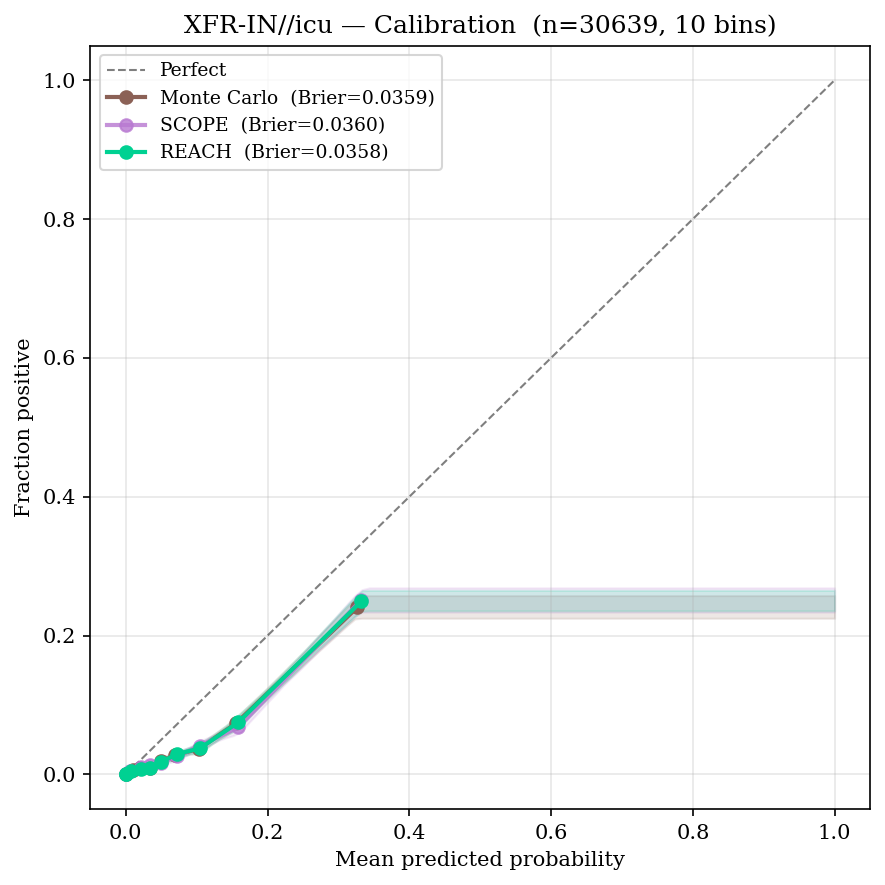

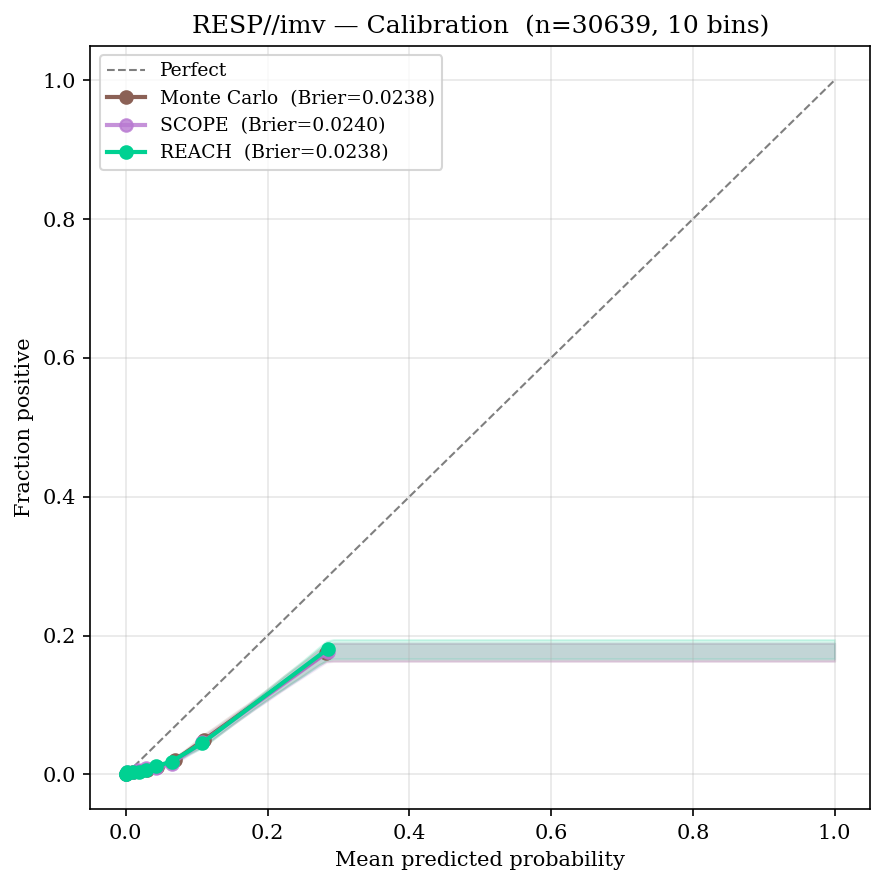

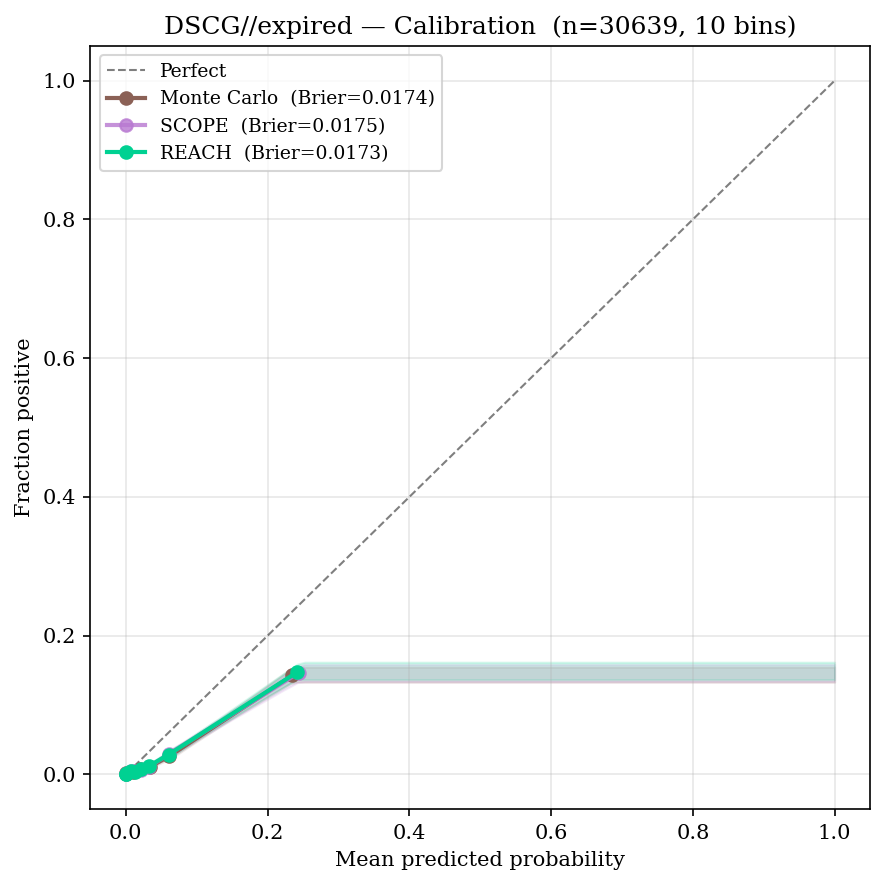

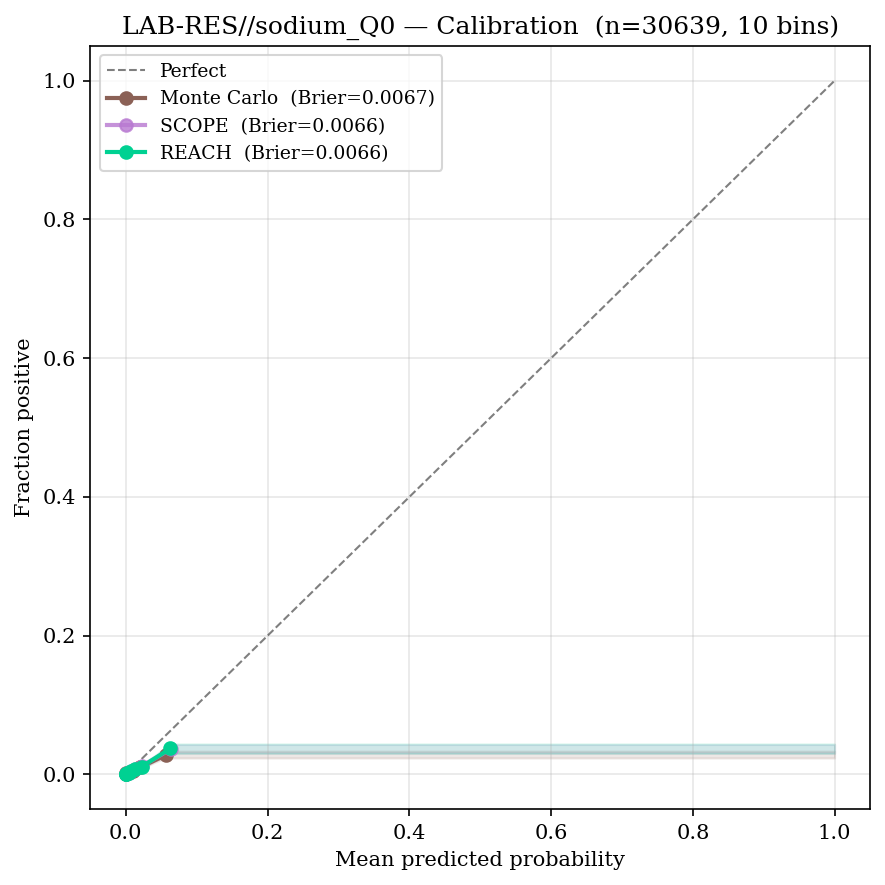

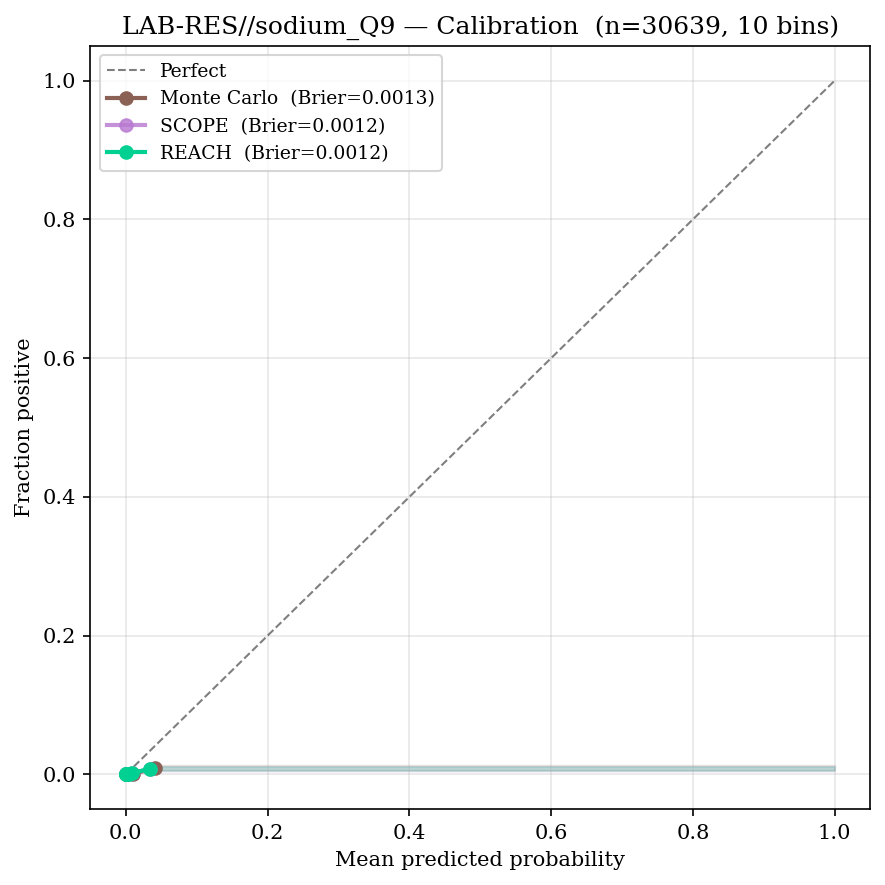

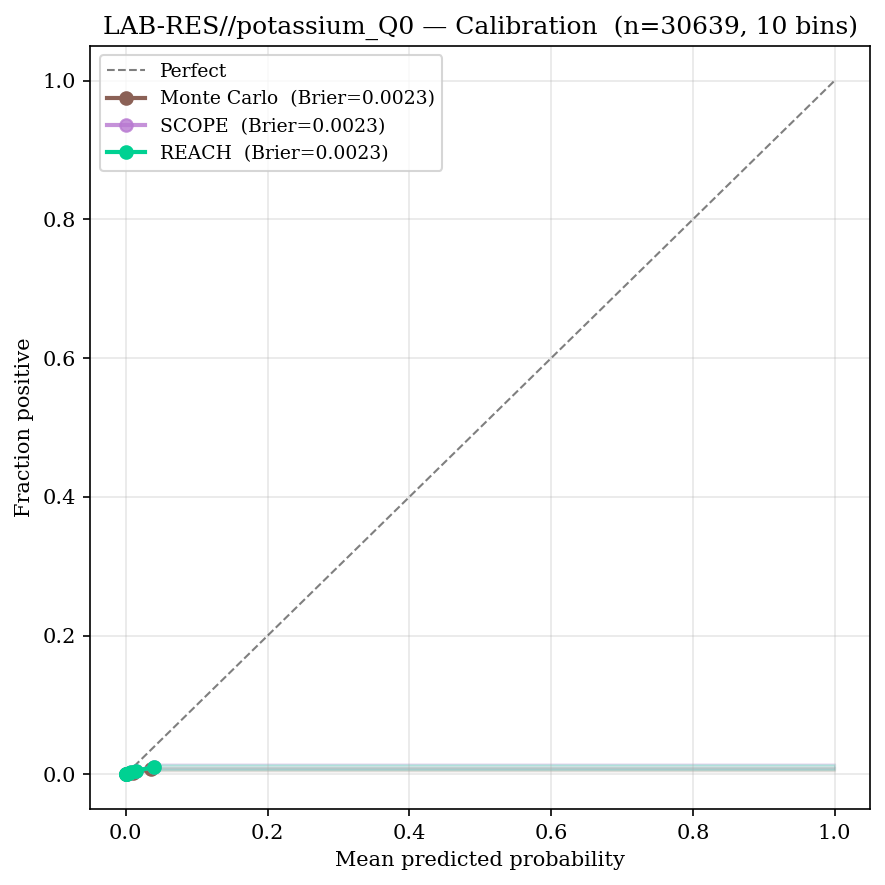

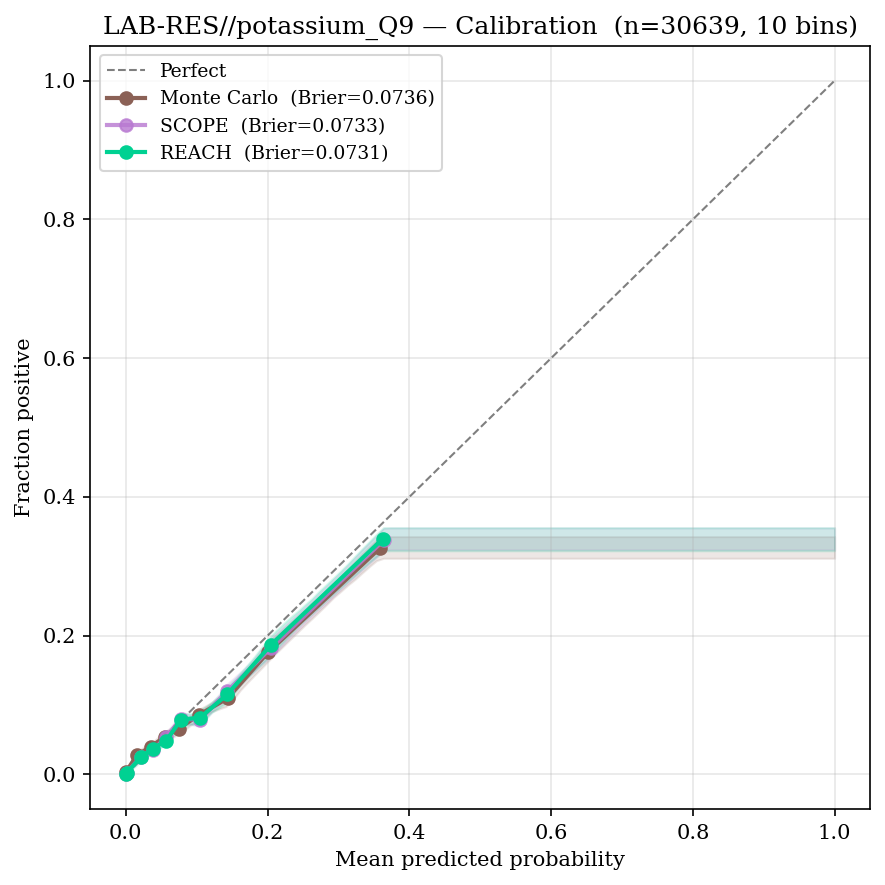

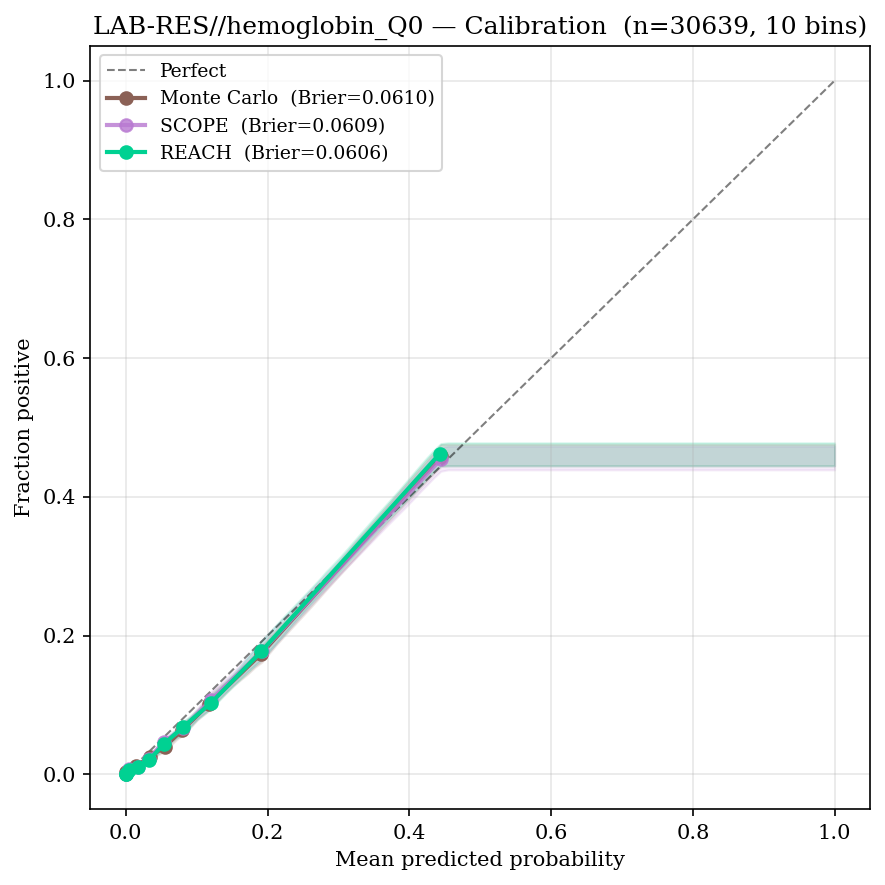

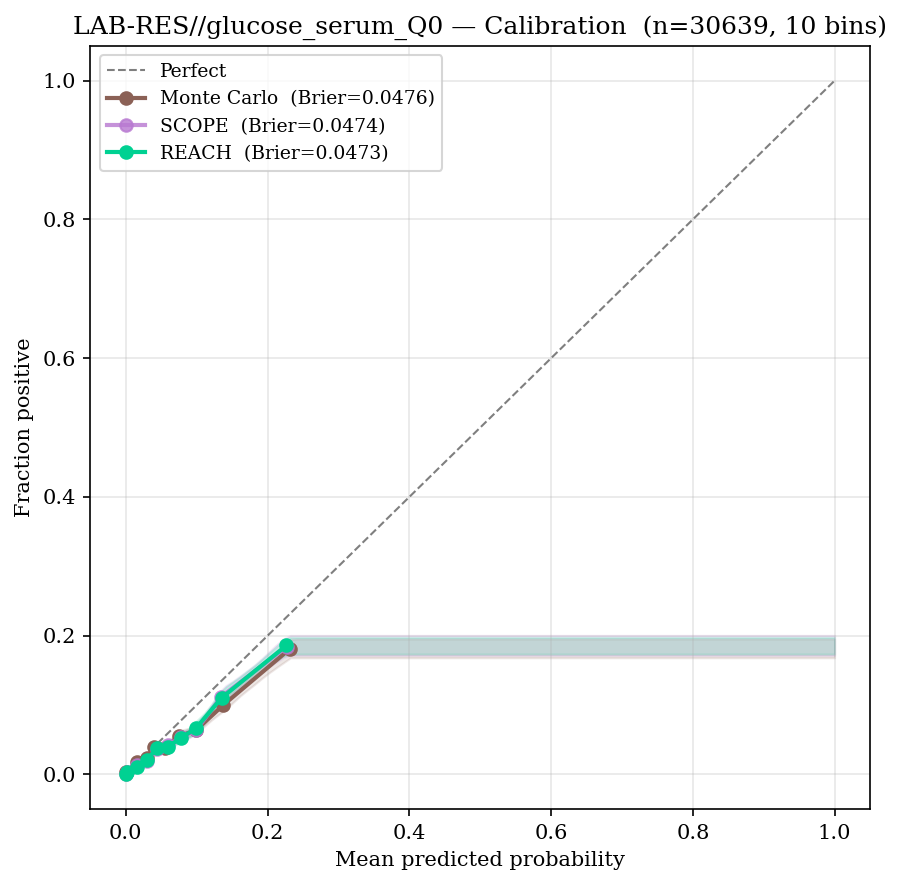

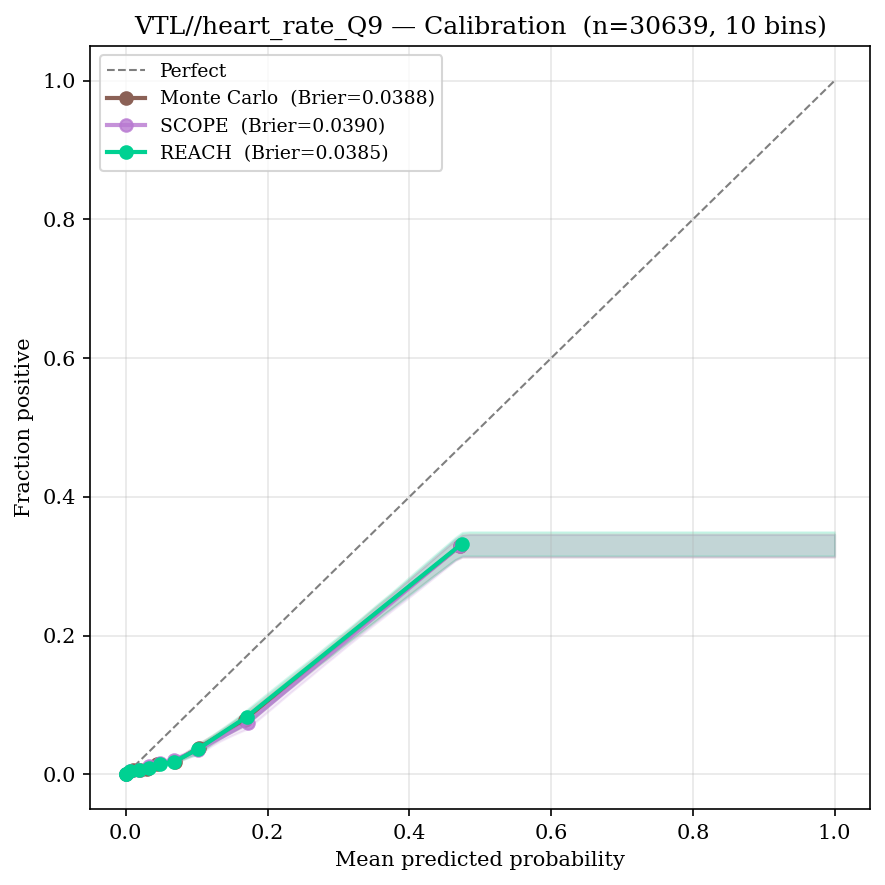

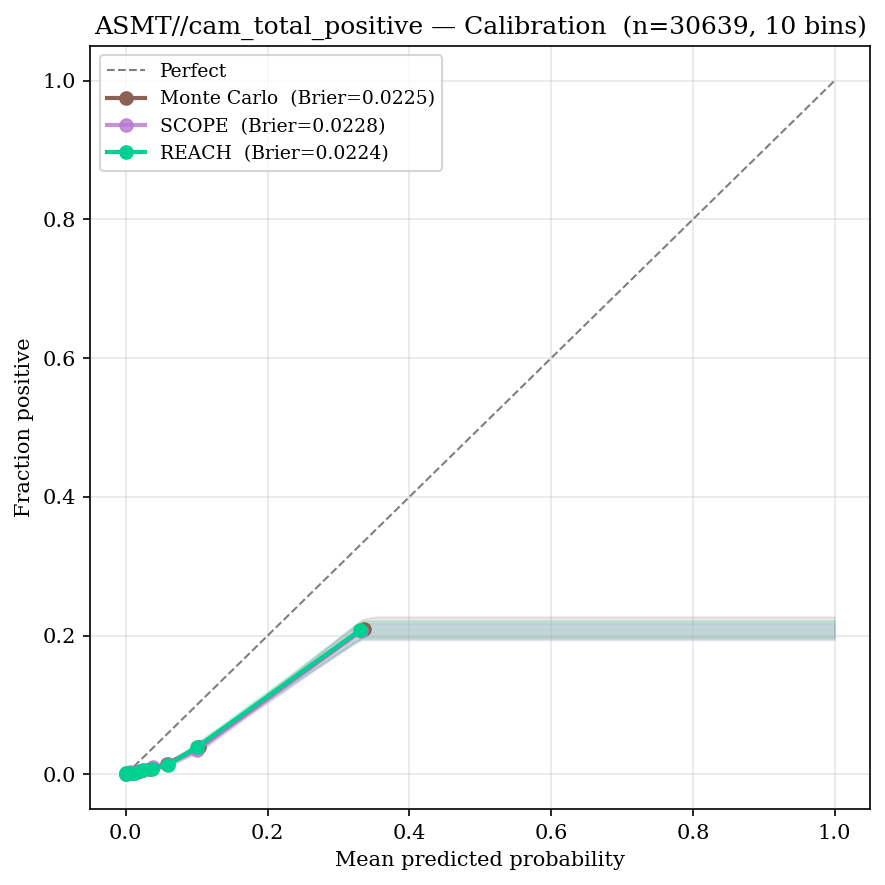

In [10]:
def _calibration_from_edges(targets, predictions, edges):
    bin_idx  = np.clip(np.digitize(predictions, edges) - 1, 0, len(edges) - 2)
    mean_pred = np.zeros(len(edges) - 1)
    frac_pos  = np.zeros(len(edges) - 1)
    mask      = np.zeros(len(edges) - 1, dtype=bool)
    for b in range(len(edges) - 1):
        in_b = bin_idx == b
        if in_b.sum() > 0:
            mean_pred[b] = predictions[in_b].mean()
            frac_pos[b]  = targets[in_b].mean()
            mask[b]      = True
    return frac_pos[mask], mean_pred[mask]


N_BOOT_CAL = 200
rng_cal    = np.random.default_rng(seed=7)

for _name, _od in outcome_data.items():
    _y      = _od["y_true"]
    _M0, _M1, _M2 = _od["M0"], _od["M1"], _od["M2"]
    _n_pts  = _od["n_patients"]
    _N_BINS = _od["N_BINS"]

    _all_preds = np.concatenate([_M0[~np.isnan(_M0)], _M1[~np.isnan(_M1)], _M2[~np.isnan(_M2)]])
    if len(_all_preds) == 0:
        print(f"No predictions for {_name} — skipping calibration.")
        continue

    _edges       = np.percentile(_all_preds, np.linspace(0, 100, _N_BINS + 1))
    _edges[0]   -= 1e-9
    _edges[-1]  += 1e-9

    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect")

    for _est, _scores in [("Monte Carlo", _M0), ("SCOPE", _M1), ("REACH", _M2)]:
        _valid = ~np.isnan(_scores)
        _preds = np.clip(_scores[_valid], 0, 1)
        _tgts  = _y[_valid].astype(float)
        _c     = COLORS[_est]

        _boot_curves = []
        _n = len(_preds)
        for _ in range(N_BOOT_CAL):
            _idx = rng_cal.integers(0, _n, size=_n)
            _fp, _mp = _calibration_from_edges(_tgts[_idx], _preds[_idx], _edges)
            if len(_mp) > 1:
                _boot_curves.append(np.interp(np.linspace(0, 1, 100), _mp, _fp))
        if _boot_curves:
            _bc = np.array(_boot_curves)
            _xg = np.linspace(0, 1, 100)
            ax.fill_between(_xg, np.percentile(_bc, 2.5, axis=0),
                            np.percentile(_bc, 97.5, axis=0), color=_c, alpha=0.15)

        _fp_full, _mp_full = _calibration_from_edges(_tgts, _preds, _edges)
        _bs = brier_score_loss(_tgts, _preds)
        ax.plot(_mp_full, _fp_full, color=_c, marker="o", linewidth=2,
                label=f"{_est}  (Brier={_bs:.4f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction positive")
    ax.set_title(f"{_name} — Calibration  (n={_n_pts}, {_N_BINS} bins)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## MC samples required to outperform one SCOPE / REACH sample

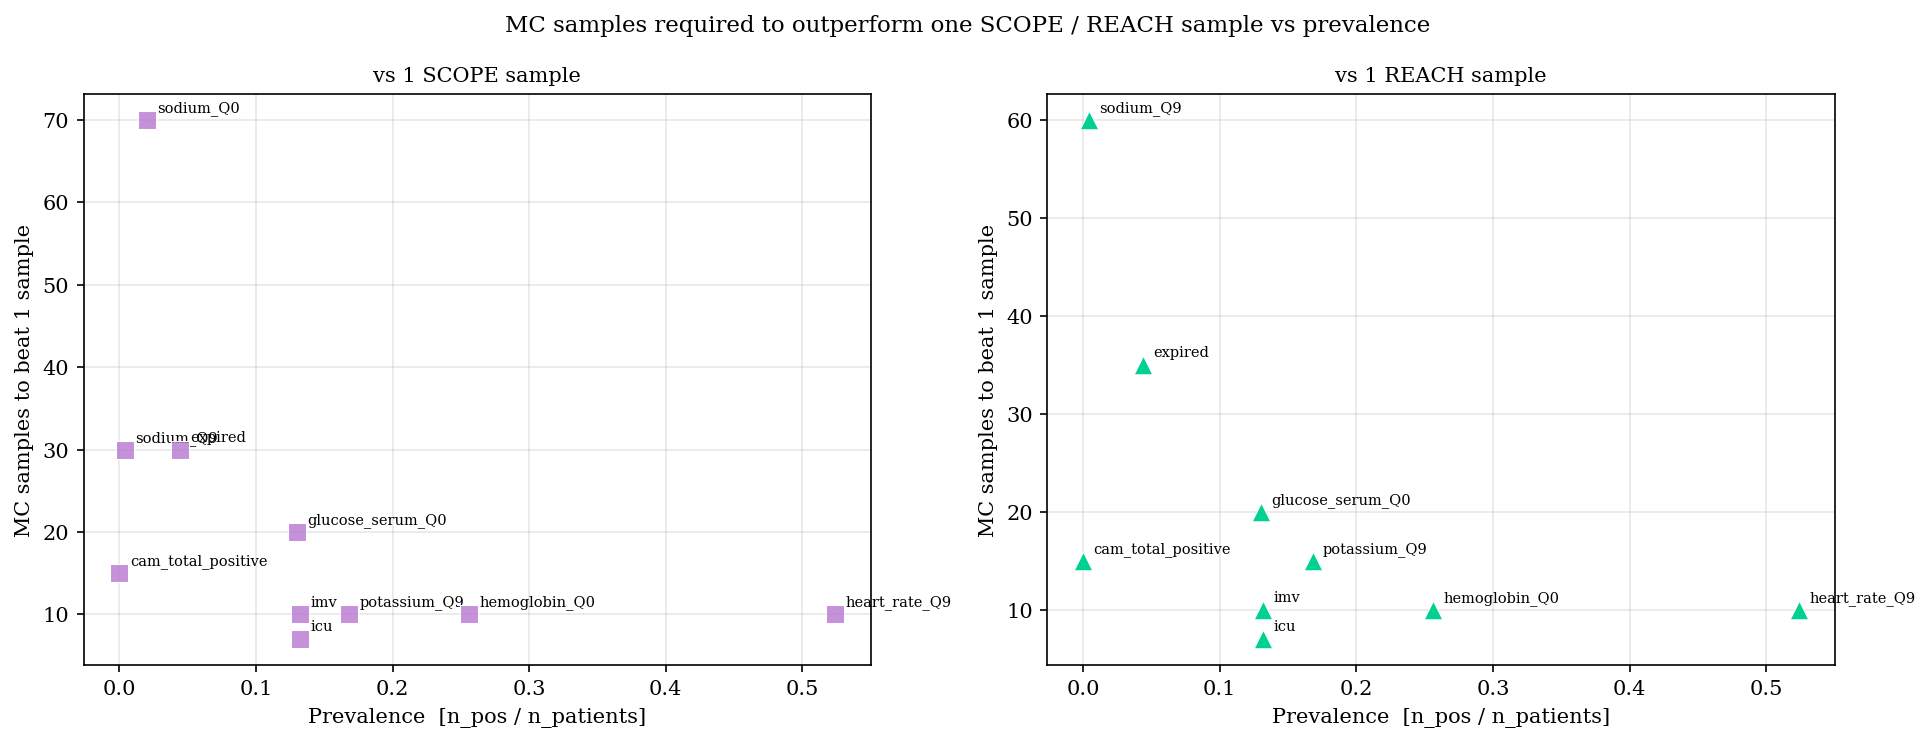

In [26]:
# ── Prevalence vs MC samples ──────────────────────────────────────────────────
_prevalence = {
    n: _od["n_pos"] / _od["n_patients"]
    for n, _od in outcome_data.items()
    if _od["n_patients"] > 0
}

_plot_names = [
    n for n in outcome_data
    if n in _prevalence and not np.isnan(_prevalence[n])
    and (n in _mc_vs_scope or n in _mc_vs_reach)
]
_short = [n.split("//")[-1] if "//" in n else n for n in _plot_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

for ax, (_est, _store, _color, _marker) in zip(axes, [
    ("SCOPE", _mc_vs_scope, COLORS["SCOPE"], MARKERS["SCOPE"]),
    ("REACH", _mc_vs_reach, COLORS["REACH"], MARKERS["REACH"]),
]):
    _names = [n for n in _plot_names if n in _store and not np.isnan(float(_store[n]))]
    _pr   = np.array([_prevalence[n]    for n in _names], dtype=float)
    _samp = np.array([float(_store[n])  for n in _names], dtype=float)
    _sl   = [_short[_plot_names.index(n)] for n in _names]

    ax.scatter(_pr, _samp, s=80, color=_color, marker=_marker,
               edgecolors="white", linewidths=0.5, zorder=5)
    for _lbl, _x, _y in zip(_sl, _pr, _samp):
        ax.annotate(_lbl, (_x, _y), textcoords="offset points", xytext=(5, 4), fontsize=7)

    ax.set_xlabel("Prevalence  [n_pos / n_patients]", fontsize=10)
    ax.set_ylabel("MC samples to beat 1 sample", fontsize=10)
    ax.set_title(f"vs 1 {_est} sample", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("MC samples required to outperform one SCOPE / REACH sample vs prevalence", fontsize=11)
plt.tight_layout()
plt.show()